## ĐỀ TÀI C9: NÉN CẢM NHẬN TÍN HIỆU PPG SO SÁNH OMP–DCT VÀ BỘ GIẢI MÃ CNN 1D TRÊN TẬP DỮ LIỆU PPG-DaLiA

- **Họ và tên:** Phùng Lê Thanh Quân
- **MSSV:** 23110145
- **Dataset:** PPG-DaLiA (15 đối tượng S1 – S15, cảm biến BVP 64 Hz trên Empatica E4)
- **Thiết bị phần cứng IoT:** Bo mạch vi điều khiển ESP32-S3 (240 MHz Dual-Core, 16 MB Flash)


---
<a id="sec1"></a>
## 1. MỤC TIÊU NGHIÊN CỨU, PHẠM VI & ĐẶT BÀI TOÁN

### 1.1. Bối cảnh kỹ thuật và Phạm vi nghiên cứu
- **Bản chất bài toán:** Đề tài nghiên cứu việc giảm thể tích dữ liệu truyền thông không dây từ thiết bị đeo (Wearable Edge Node) về trạm thu trung tâm (Gateway/PC) bằng kỹ thuật Nén Cảm nhận số sau lấy mẫu (Post-sampling Compressive Sensing - CS) trên tín hiệu thể tích biến thiên xung máu quang học (Photoplethysmography - PPG).
- **Phạm vi xử lý:** Tín hiệu PPG thô (kênh BVP) đã được lấy mẫu ở tần số cố định $F_s = 64\text{ Hz}$ từ vòng đeo tay Empatica E4. Vi điều khiển ESP32 thực hiện lọc nhân quả, lượng tử hóa và nén tuyến tính trên các mẫu số đã thu nhận.
- **Ranh giới khoa học rõ ràng:**
  1. Đích tái tạo là tín hiệu PPG quan sát thực tế sau tiền xử lý nhân quả, không giả định là PPG "sạch" lý tưởng không nhiễu.
  2. Hệ thống phân chia tính toán bất đối xứng (Asymmetric Complexity): ESP32 chỉ làm nhiệm vụ nén tuyến tính nhẹ $\mathbf{y} = \mathbf{\Phi}\mathbf{x}$. Các bộ giải mã chạy tại máy tính/trạm thu; benchmark suy luận máy thu dùng CPU. Huấn luyện và đánh giá chất lượng offline CNN có thể dùng CUDA, ghi rõ thiết bị trong manifest. ESP32 **không** chạy mạng nơ-ron sâu.
  3. Không suy diễn kết quả tái tạo thành chẩn đoán lâm sàng, bảo tồn biến thiên nhịp tim (HRV) hoặc tiết kiệm điện năng toàn hệ thống khi chưa có phép đo dòng tiêu thụ thực tế.

### 1.2. Mục tiêu kỹ thuật và Tiêu chí kiểm chứng
Đề tài kiểm chứng 4 chỉ tiêu định lượng được nêu trong Đề cương Mục 1.2:
- **Chỉ tiêu 1 (Chất lượng dạng sóng):** Tỷ lệ sai số căn bậc hai chuẩn hóa $\text{PRD} \le 15\%$ tại cấu hình nén mục tiêu.
- **Chỉ tiêu 2 (Ưu thế tương đối của CNN 1D):** Tại $M=77$ (tỷ lệ đo $MR \approx 30\%$, giảm $70\%$ số chiều), bộ giải mã học sâu CNN 1D đạt mức giảm PRD tương đối $\ge 10\%$ so với OMP–DCT:
$$\text{Relative Reduction} = 100 \times \frac{\text{PRD}_{\text{OMP}} - \text{PRD}_{\text{CNN}}}{\text{PRD}_{\text{OMP}}} \ge 10\%$$
- **Chỉ tiêu 3 (Thời gian mã hóa biên):** Thời gian thực thi phép nén và đóng gói trên ESP32 đạt phân vị $p95(t_{\text{enc}}) < 100\text{ ms}$.
- **Chỉ tiêu 4 (Tiêu hao bộ nhớ biên):** Bộ nhớ RAM bổ sung cho thuật toán mã hóa trên vi điều khiển $< 64\text{ KiB}$.

### 1.3. Mở rộng ResLinCNN_Lite
So sánh chính mở rộng gồm OMP–DCT, CNN 1D gốc và ResLinCNN_Lite tại cả ba M. CNN gốc và Linear đối chứng giữ đúng cấu hình đề cương; model residual là cải tiến bổ sung, không thay thế đối chứng bắt buộc. Kết quả test của pipeline gốc đã được xem, nên đánh giá kiến trúc mới được công bố là mở rộng thăm dò, không gọi là holdout chưa từng dùng.

Bộ mới gồm 45 checkpoint có contract/fingerprint và lịch sử kết thúc train. So sánh dùng cùng cache `filtered_bvp_v2.npz`, fold, chuẩn hóa train và protocol lượng tử; kiểm tra validation trước test. Phạm vi thăm dò thuộc thiết kế bổ sung kiến trúc sau khi đã xem test gốc, không còn do thiếu history hoặc dùng cache cũ.


In [1]:
# Thiết lập môi trường và nạp các thư viện chuẩn
%matplotlib inline
import os
from pathlib import Path
for _thread_env in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS"]:
    os.environ[_thread_env] = "1"
import sys
import time
import json
import struct
import zlib
import hashlib
import platform
import random
import numpy as np
import pandas as pd
import scipy.signal
import scipy.linalg
import scipy.linalg.lapack as lapack
import scipy.fft
import scipy.stats
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
# Mã hỗ trợ đã có trong dự án; không thay đổi kiến trúc CNN của đề cương.
PROJECT_ROOT = Path(os.environ.get("PPG_PROJECT_ROOT", str(Path.cwd())))
if not (PROJECT_ROOT / "experiment_config.py").is_file():
    raise FileNotFoundError("Đặt PPG_PROJECT_ROOT tới thư mục mã nguồn của đề tài")
sys.path.insert(0, str(PROJECT_ROOT))
from experiment_config import ExperimentConfig
from provenance import file_sha256, array_hash, contract_hash, save_json
from threadpoolctl import threadpool_limits, threadpool_info
THREAD_LIMITER = threadpool_limits(limits=1)
torch.set_num_threads(1)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
CONFIG = ExperimentConfig(root=str(PROJECT_ROOT), run_id="20261005_canonical_lite_verified", hardware_port="COM5")

# Thiết lập đường dẫn thư mục lưu trữ
DATA_ROOT = os.environ.get("PPG_DATA_ROOT", CONFIG.data_root)
CACHE_FILE = str(PROJECT_ROOT / "data/filtered_bvp_v2.npz")
CHECKPOINT_DIR = str(PROJECT_ROOT / "checkpoints/20261004_three_models_v2")
RESULTS_DIR = str(CONFIG.directory("results"))
FIGURES_DIR = str(CONFIG.directory("figures"))
EXPORTS_DIR = str(CONFIG.directory("exports"))

for d in [os.path.dirname(CACHE_FILE), CHECKPOINT_DIR, RESULTS_DIR, FIGURES_DIR, EXPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Các cờ điều khiển quy trình thực nghiệm
RESUME_IF_CHECKPOINT_EXISTS = True  # Nạp 45 checkpoint đã train nếu có, hoặc train lại nếu False
FAST_DEBUG = False                  # Chế độ kiểm thử nhanh (debug). Bắt buộc False cho kết quả chính thức

# False tạo thư mục checkpoint mới; không ghi đè hay tái sử dụng checkpoint chính thức.
if not RESUME_IF_CHECKPOINT_EXISTS:
    import datetime, uuid
    CHECKPOINT_DIR = str(CONFIG.directory("checkpoints") / (datetime.datetime.now(datetime.timezone.utc).strftime("fresh_%Y%m%dT%H%M%SZ_")+uuid.uuid4().hex[:8]))
    Path(CHECKPOINT_DIR).mkdir(parents=True,exist_ok=False)


In [3]:
# Thiết lập thiết bị tính toán
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BENCHMARK_DEVICE = torch.device("cpu") # Bắt buộc CPU cho benchmark độ trễ suy luận

# Hàm tái lập môi trường ngẫu nhiên
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_global_seed(42)

# Cấu hình đồ họa hiển thị khoa học
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.6


In [4]:
# Khởi tạo bộ đếm thống kê lỗi thực tế (Failure & Accounting Tracker)
failure_tracker = {
    "total_quantized_values": 0,
    "total_clipped_values": 0,
    "nan_count": 0,
    "inf_count": 0,
    "zero_energy_windows": 0,
    "invalid_windows": 0,
    "omp_early_stops": 0,
    "omp_failures": 0,
    "crc_failures": 0
}

print("=================================================================")
print("THÔNG TIN MÔI TRƯỜNG THỰC NGHIỆM VÀ ĐẶC TẢ TÁI LẬP (REPRODUCIBILITY)")
print("=================================================================")
print(f"Hệ điều hành          : {platform.platform()}")
print(f"Vi xử lý (CPU)        : {platform.processor()} ({os.cpu_count()} logical cores)")
print(f"Phiên bản Python      : {platform.python_version()}")
print(f"Phiên bản NumPy       : {np.__version__}")
print(f"Phiên bản SciPy       : {scipy.__version__}")
print(f"Phiên bản PyTorch     : {torch.__version__}")
print(f"Thiết bị huấn luyện   : {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"Thiết bị Benchmark    : {BENCHMARK_DEVICE}")
print(f"Danh sách Random Seed : [11, 22, 33] (Model initialization & DataLoader shuffle)")
print(f"Sensing Matrix Seed   : 42 (Rademacher +/-1 / sqrt(M))")
print(f"Thông số Cửa sổ       : N = 256 mẫu (4.0s @ 64Hz), H = 128 mẫu (bước nhảy 2.0s)")
print(f"Mức đo nén (M)        : [51, 77, 128] (MR thực: 51/256=0.199, 77/256=0.301, 128/256=0.500)")
print(f"Bộ lọc Tiền xử lý     : Butterworth bậc 4 thông dải (2 SOS sections, 0.5 - 8.0 Hz @ 64Hz, lọc nhân quả sosfilt)")
print(f"Loại bỏ Quá độ        : 5.0 giây đầu (320 mẫu) sau khởi tạo lọc với trạng thái zi = 0")
print(f"Chuẩn hóa Z-Score     : Tuyệt đối theo tập Train của từng Fold (mu_train, sigma_train), theo train; kiểm tra tách người")
print(f"Lượng tử hóa          : INT16 đối xứng [-32767, 32767] với thang đo động delta = max(|y|)/32767 theo gói tin")
print(f"Giao thức Gói tin     : 16 bytes Header (phiên bản, flags, config_id, frame_index, scale_delta, CRC32)")
print(f"Cấu hình Phân chia    : 5-Fold Subject-Wise Cross Validation (15 đối tượng S1 - S15)")
print(f"RESUME_IF_CHECKPOINT  : {RESUME_IF_CHECKPOINT_EXISTS}")
print(f"FAST_DEBUG            : {FAST_DEBUG}")
print("=================================================================")
print("Số luồng PyTorch:", torch.get_num_threads(), "| BLAS:", threadpool_info())
save_json(Path(RESULTS_DIR)/"environment.json", {"os":platform.platform(), "cpu":platform.processor(),
    "python":platform.python_version(), "numpy":np.__version__, "scipy":scipy.__version__,
    "torch":torch.__version__, "offline_inference_device":str(DEVICE), "offline_inference_gpu":torch.cuda.get_device_name(0) if DEVICE.type=="cuda" else None, "receiver_benchmark_device":"cpu", "torch_threads":torch.get_num_threads(), "blas":threadpool_info(),
    "numerical_contract":CONFIG.numerical_contract(),
    "test_disclosure":"Kết quả test phiên trước đã được xem; lần sửa này khóa nguyên kiến trúc và giao thức đánh giá theo đề cương, không tuyên bố holdout chưa từng xem."})


THÔNG TIN MÔI TRƯỜNG THỰC NGHIỆM VÀ ĐẶC TẢ TÁI LẬP (REPRODUCIBILITY)
Hệ điều hành          : Windows-11-10.0.26200-SP0
Vi xử lý (CPU)        : Intel64 Family 6 Model 154 Stepping 3, GenuineIntel (16 logical cores)
Phiên bản Python      : 3.12.10
Phiên bản NumPy       : 2.2.6
Phiên bản SciPy       : 1.14.1
Phiên bản PyTorch     : 2.6.0+cu124
Thiết bị huấn luyện   : cuda (NVIDIA GeForce RTX 3050 Laptop GPU)
Thiết bị Benchmark    : cpu
Danh sách Random Seed : [11, 22, 33] (Model initialization & DataLoader shuffle)
Sensing Matrix Seed   : 42 (Rademacher +/-1 / sqrt(M))
Thông số Cửa sổ       : N = 256 mẫu (4.0s @ 64Hz), H = 128 mẫu (bước nhảy 2.0s)
Mức đo nén (M)        : [51, 77, 128] (MR thực: 51/256=0.199, 77/256=0.301, 128/256=0.500)
Bộ lọc Tiền xử lý     : Butterworth bậc 4 thông dải (2 SOS sections, 0.5 - 8.0 Hz @ 64Hz, lọc nhân quả sosfilt)
Loại bỏ Quá độ        : 5.0 giây đầu (320 mẫu) sau khởi tạo lọc với trạng thái zi = 0
Chuẩn hóa Z-Score     : Tuyệt đối theo tập Train của từng 

---
<a id="sec2"></a>
## 2. KHÁM PHÁ DỮ LIỆU BVP THÔ (EXPLORATORY DATA ANALYSIS - RAW BVP)

### 2.1. Thu nhận tín hiệu BVP thô từ bộ dữ liệu PPG-DaLiA
- Tập dữ liệu gồm 15 đối tượng tình nguyện viên ($S1$ đến $S15$) thực hiện các hoạt động sinh hoạt tự do hàng ngày (ngồi làm việc, lái xe, đi bộ, đạp xe, leo cầu thang, ăn trưa,...).
- Thiết bị thu thập: Vòng đeo Empatica E4 ghi nhận tín hiệu quang thể tích kênh BVP (Blood Volume Pulse) tại cổ tay với tần số lấy mẫu cố định $F_s = 64\text{ Hz}$.
- Dữ liệu thô được nạp trực tiếp từ các tệp pickle nguyên bản (`S{i}.pkl`). Tín hiệu ở giai đoạn này giữ nguyên dạng thô ban đầu: chứa thành phần trôi đường cơ sở (baseline wander) và nhiễu vận động tần số cao, chưa qua bất kỳ khâu lọc, bỏ quá độ hay chuẩn hóa nào.

### 2.2. Kiểm tra tính toàn vẹn 15 đối tượng và thống kê mô tả dữ liệu thô
- Kiểm tra sự hiện diện đầy đủ của 15 đối tượng $S1 \dots S15$.
- Thống kê mô tả số lượng mẫu, thời lượng quan sát thực tế (phút), giá trị trung bình (Mean), độ lệch chuẩn (Std), giá trị cực tiểu (Min) và cực đại (Max) cho từng đối tượng trên tín hiệu RAW BVP.

In [5]:
# Danh sách 15 đối tượng nghiên cứu của PPG-DaLiA
SUBJECTS = [f"S{i}" for i in range(1, 16)]

# Hàm trích xuất tín hiệu BVP thô từ file pickle gốc
def load_raw_bvp_from_pickle(subject, data_root=DATA_ROOT):
    import pickle
    pkl_path = os.path.join(data_root, subject, f"{subject}.pkl")
    if not os.path.exists(pkl_path):
        return None
    with open(pkl_path, "rb") as f:
        d = pickle.load(f, encoding="latin1")
        bvp_raw = d["signal"]["wrist"]["BVP"].flatten().astype(np.float32)
    return bvp_raw

# Đọc toàn bộ RAW BVP cho 15 đối tượng từ file pickle (hỗ trợ bộ nhớ đệm thô)
RAW_CACHE_FILE = str(PROJECT_ROOT / "data/raw_bvp.npz")

def load_or_extract_raw_bvp_dataset(cache_path=RAW_CACHE_FILE, data_root=DATA_ROOT):
    print(f"Kiểm chứng nguồn BVP thô. Đang đọc trực tiếp từ các file pickle PPG-DaLiA: {data_root}")
    raw_dict = {}
    for s in SUBJECTS:
        bvp_raw = load_raw_bvp_from_pickle(s, data_root)
        if bvp_raw is None:
            raise FileNotFoundError(f"Không tìm thấy file pickle cho {s} tại {data_root}")
        raw_dict[s] = bvp_raw
        print(f"  Đã nạp {s}: {len(bvp_raw)} mẫu thô")
    np.savez_compressed(cache_path, **raw_dict)
    save_json(Path(RESULTS_DIR)/"raw_sources.json", {s: {"source_sha256":file_sha256(Path(data_root)/s/f"{s}.pkl"),
        "array_sha256":array_hash(v), "nonfinite_samples":int((~np.isfinite(v)).sum())} for s,v in raw_dict.items()})
    print(f"Đã lưu bộ nhớ đệm BVP thô tại {cache_path}")
    return raw_dict

raw_bvp_dataset = load_or_extract_raw_bvp_dataset()

# Kiểm tra thực sự đủ 15 đối tượng S1-S15
missing_subjects = [s for s in SUBJECTS if s not in raw_bvp_dataset or raw_bvp_dataset[s] is None]
assert len(missing_subjects) == 0, f"Thiếu đối tượng: {missing_subjects}"
assert len(raw_bvp_dataset) == 15, f"Số lượng đối tượng không đúng 15: {len(raw_bvp_dataset)}"
print(f"Kiểm tra tính toàn vẹn: Đầy đủ 15 đối tượng S1-S15 ({', '.join(SUBJECTS)})")


Kiểm chứng nguồn BVP thô. Đang đọc trực tiếp từ các file pickle PPG-DaLiA: E:/STUDY/DATASET/PPG_FieldStudy


  Đã nạp S1: 589568 mẫu thô


  Đã nạp S2: 525120 mẫu thô


  Đã nạp S3: 559424 mẫu thô


  Đã nạp S4: 585600 mẫu thô


...

  Đã nạp S12: 506496 mẫu thô


  Đã nạp S13: 584704 mẫu thô


  Đã nạp S14: 573312 mẫu thô


  Đã nạp S15: 508096 mẫu thô


Đã lưu bộ nhớ đệm BVP thô tại D:\IOT\CuoiKy\data\raw_bvp.npz
Kiểm tra tính toàn vẹn: Đầy đủ 15 đối tượng S1-S15 (S1, S2, S3, S4, S5, S6, S7, S8, S9, S10, S11, S12, S13, S14, S15)


In [6]:
# Thống kê mô tả RAW BVP của 15 đối tượng (chưa lọc, chưa bỏ quá độ, chưa chuẩn hóa)
raw_eda_records = []
for s in SUBJECTS:
    sig = raw_bvp_dataset[s]
    duration_min = len(sig) / (64.0 * 60.0)
    raw_eda_records.append({
        "Đối tượng": s,
        "Số mẫu (Fs=64)": len(sig),
        "Thời lượng (phút)": f"{duration_min:.1f}",
        "Trung bình": f"{np.mean(sig):.4f}",
        "Độ lệch chuẩn": f"{np.std(sig):.2f}",
        "Giá trị Min": f"{np.min(sig):.2f}",
        "Giá trị Max": f"{np.max(sig):.2f}"
    })

df_raw_eda = pd.DataFrame(raw_eda_records)
print("\nBẢNG 1: THỐNG KÊ MÔ TẢ TẬP DỮ LIỆU BVP THÔ PPG-DaLiA (15 ĐỐI TƯỢNG)")
display(df_raw_eda)



BẢNG 1: THỐNG KÊ MÔ TẢ TẬP DỮ LIỆU BVP THÔ PPG-DaLiA (15 ĐỐI TƯỢNG)


,Đối tượng,Số mẫu (Fs=64),Thời lượng (phút),Trung bình,Độ lệch chuẩn,Giá trị Min,Giá trị Max
0,S1,589568,153.5,-0.0023,97.14,-1647.39,1557.58
1,S2,525120,136.8,-0.0004,37.96,-648.58,482.77
2,S3,559424,145.7,-0.0003,69.98,-1191.30,812.59
3,S4,585600,152.5,-0.0042,59.75,-1019.53,937.16
4,S5,595520,155.1,-0.0006,103.81,-890.32,1247.24
5,S6,336000,87.5,0.0072,83.51,-1118.50,610.55
6,S7,597952,155.7,0.0008,60.29,-776.77,460.78
7,S8,517120,134.7,0.0010,53.66,-943.93,874.93
8,S9,547840,142.7,-0.0022,97.25,-1608.31,1841.26
9,S10,681472,177.5,0.0015,58.70,-1025.09,837.19


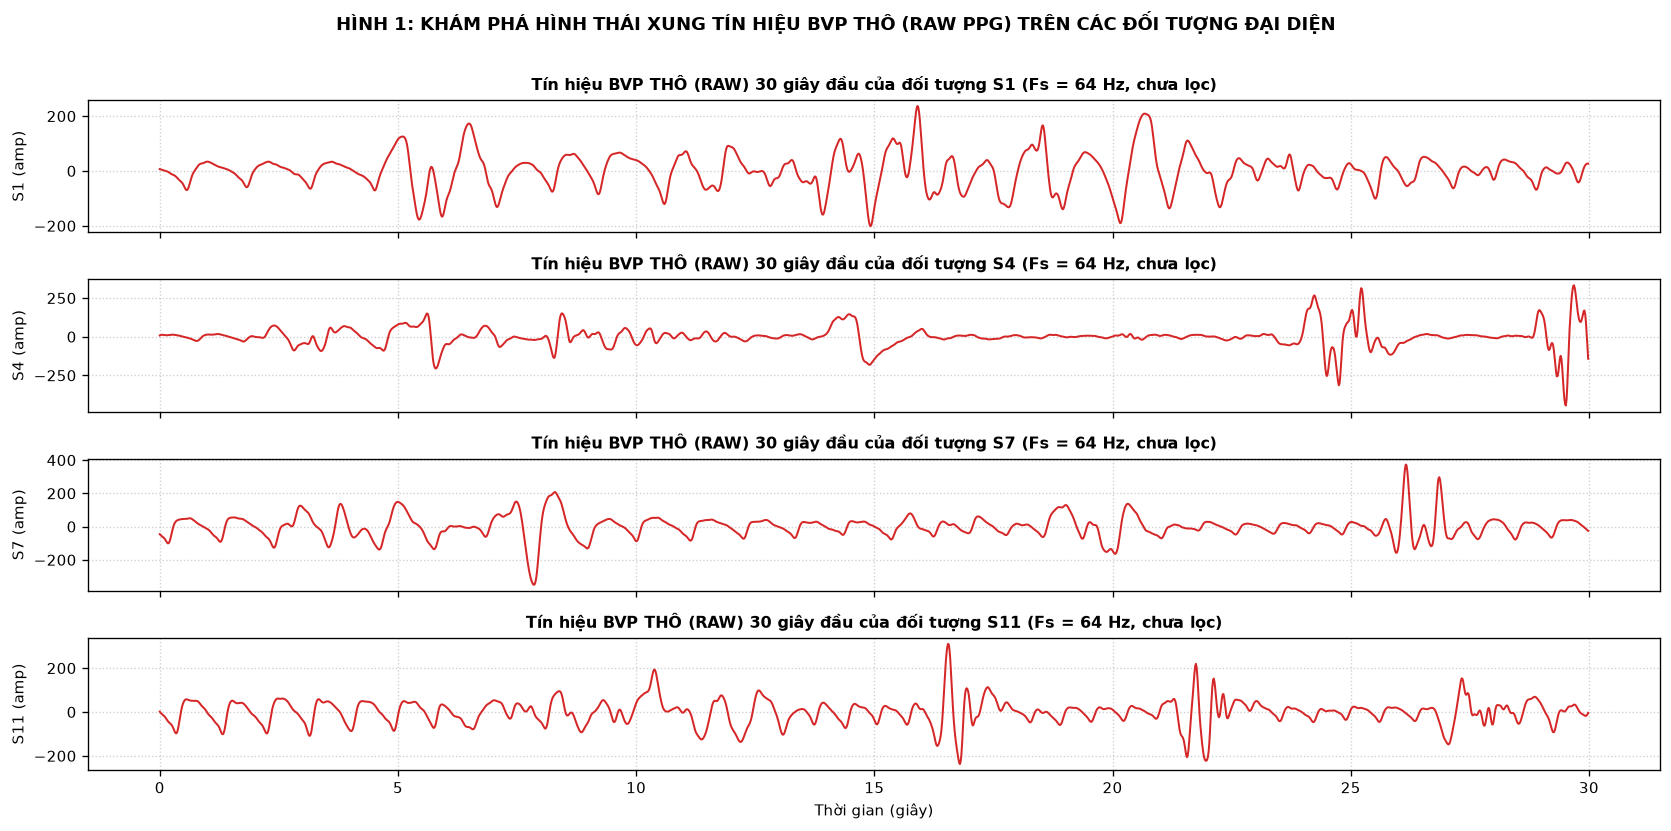

In [7]:
# Trực quan hóa đoạn RAW BVP với trục thời gian thực (giây)
fig, axes = plt.subplots(4, 1, figsize=(14, 6.8), sharex=True)
sample_subs = ["S1", "S4", "S7", "S11"]
duration_sec = 30
num_samples_plot = 64 * duration_sec
t_raw = np.arange(num_samples_plot) / 64.0  # Trục thời gian tính bằng giây

for ax, s in zip(axes, sample_subs):
    ax.plot(t_raw, raw_bvp_dataset[s][:num_samples_plot], color="#d62728", linewidth=1.2)
    ax.set_ylabel(f"{s} (amp)")
    ax.set_title(f"Tín hiệu BVP THÔ (RAW) 30 giây đầu của đối tượng {s} (Fs = 64 Hz, chưa lọc)", fontsize=9.5, fontweight="bold")

axes[-1].set_xlabel("Thời gian (giây)")
plt.suptitle("HÌNH 1: KHÁM PHÁ HÌNH THÁI XUNG TÍN HIỆU BVP THÔ (RAW PPG) TRÊN CÁC ĐỐI TƯỢNG ĐẠI DIỆN", fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig1_eda_raw_bvp.png"), bbox_inches="tight")
plt.show()


---
<a id="sec3"></a>
## 3. TIỀN XỬ LÝ TÍN HIỆU: BỘ LỌC THÔNG DẢI NHÂN QUẢ & LOẠI BỎ QUÁ ĐỘ 5 GIÂY

### 3.1. Đặc tả kỹ thuật bộ lọc theo Đề cương Mục 2.3
- **Loại bộ lọc:** Butterworth thông dải bậc 4 gồm 2 tầng Second-Order Sections (SOS):
  `scipy.signal.butter(2, [0.5, 8.0], btype="bandpass", fs=64, output="sos")`
- **Tính nhân quả:** Thực hiện trực tiếp bằng phép tính nhân quả từng mẫu qua hàm `scipy.signal.sosfilt` hoặc lớp lọc Direct Form II Transposed bảo toàn trạng thái. Tuyệt đối **KHÔNG** sử dụng bộ lọc phi nhân quả hai chiều `filtfilt`.
- **Trạng thái bộ lọc:** Bộ lọc chạy liên tục trên từng bản ghi của từng người, giữ nguyên trạng thái `zi` giữa các cửa sổ nối tiếp. Trạng thái lọc được đặt lại về 0 khi chuyển sang đối tượng mới.
- **Loại bỏ quá độ:** Bỏ toàn bộ 5 giây đầu ($5 \times 64 = 320\text{ mẫu}$) của mỗi người sau khi khởi tạo bộ lọc để loại bỏ sai số dao động đầu vào (filter transient).
- **Bảo toàn dữ liệu đầu vào downstream:** Dữ liệu sau lọc Float32 và bỏ 320 mẫu được lưu trong cache `filtered_bvp_v2.npz`, kiểm tra hash nguồn và cấu hình trước khi dùng; đoạn không hữu hạn giữ nguyên vị trí, reset lọc và loại quá độ, không nối qua khoảng mất dữ liệu. Dữ liệu cache được gán cho biến `raw_dataset` nhằm đảm bảo toàn bộ các bước huấn luyện, đánh giá và kiểm thử downstream tiếp nhận chính xác tập dữ liệu chuẩn mực đã được kiểm định.

In [8]:
# Lớp lọc nhân quả dạng Direct Form II Transposed bảo toàn trạng thái
class CausalSOSFilter:
    def __init__(self, sos=None):
        if sos is None:
            self.sos = scipy.signal.butter(2, [0.5, 8.0], btype="bandpass", fs=64, output="sos").astype(np.float32)
        else:
            self.sos = np.asarray(sos, dtype=np.float32)
        self.n_sections = self.sos.shape[0]
        self.reset()

    def reset(self):
        self.zi = np.zeros((self.n_sections, 2), dtype=np.float32)

    def filter_sample(self, sample):
        out = sample
        for s in range(self.n_sections):
            b0, b1, b2, a0, a1, a2 = self.sos[s]
            w = b0 * out + self.zi[s, 0]
            self.zi[s, 0] = b1 * out - a1 * w + self.zi[s, 1]
            self.zi[s, 1] = b2 * out - a2 * w
            out = w
        return float(out)

    def filter_stream(self, x):
        y = np.empty_like(x, dtype=np.float32)
        for i in range(len(x)):
            y[i] = self.filter_sample(x[i])
        return y

# Hàm tải hoặc tạo mới dữ liệu tiền xử lý lưu trong file npz (Bảo toàn 100% công thức gốc)
def load_or_create_filtered_dataset(cache_path=CACHE_FILE, data_root=DATA_ROOT):
    from dataset import load_or_build_dataset
    data, metadata = load_or_build_dataset(CONFIG)
    save_json(Path(RESULTS_DIR)/"preprocessing_manifest.json", metadata)
    return data


In [9]:
# Gán biến raw_dataset chứa dữ liệu đã lọc theo đúng giao thức downstream hiện có
raw_dataset = load_or_create_filtered_dataset()
filtered_dataset = raw_dataset  # Bí danh tường minh cho dữ liệu đã lọc

# Thống kê mô tả dữ liệu BVP sau lọc và loại bỏ quá độ 5 giây (320 mẫu)
filtered_eda_records = []
for s in SUBJECTS:
    sig = raw_dataset[s]
    duration_min = len(sig) / (64.0 * 60.0)
    filtered_eda_records.append({
        "Đối tượng": s,
        "Số mẫu (Fs=64)": len(sig),
        "Thời lượng (phút)": f"{duration_min:.1f}",
        "Trung bình": f"{np.mean(sig):.4f}",
        "Độ lệch chuẩn": f"{np.std(sig):.2f}",
        "Giá trị Min": f"{np.min(sig):.2f}",
        "Giá trị Max": f"{np.max(sig):.2f}"
    })

df_filtered_eda = pd.DataFrame(filtered_eda_records)
print("\nBẢNG 1B: THỐNG KÊ MÔ TẢ TÍN HIỆU BVP SAU LỌC NHÂN QUẢ VÀ BỎ QUÁ ĐỘ (15 ĐỐI TƯỢNG)")
display(df_filtered_eda)



BẢNG 1B: THỐNG KÊ MÔ TẢ TÍN HIỆU BVP SAU LỌC NHÂN QUẢ VÀ BỎ QUÁ ĐỘ (15 ĐỐI TƯỢNG)


,Đối tượng,Số mẫu (Fs=64),Thời lượng (phút),Trung bình,Độ lệch chuẩn,Giá trị Min,Giá trị Max
0,S1,589248,153.4,-0.0011,89.69,-1689.63,1716.09
1,S2,524800,136.7,-0.0007,36.17,-568.92,564.97
2,S3,559104,145.6,0.0000,62.64,-523.99,1163.25
3,S4,585280,152.4,-0.0037,56.58,-785.24,830.18
4,S5,595200,155.0,-0.0003,93.17,-1250.93,642.17
5,S6,335680,87.4,0.0034,76.35,-640.18,914.52
6,S7,597632,155.6,-0.0010,57.03,-524.85,533.31
7,S8,516800,134.6,-0.0009,49.87,-858.93,948.73
8,S9,547520,142.6,-0.0005,90.91,-2179.88,1399.65
9,S10,681152,177.4,0.0004,55.04,-683.82,1487.97


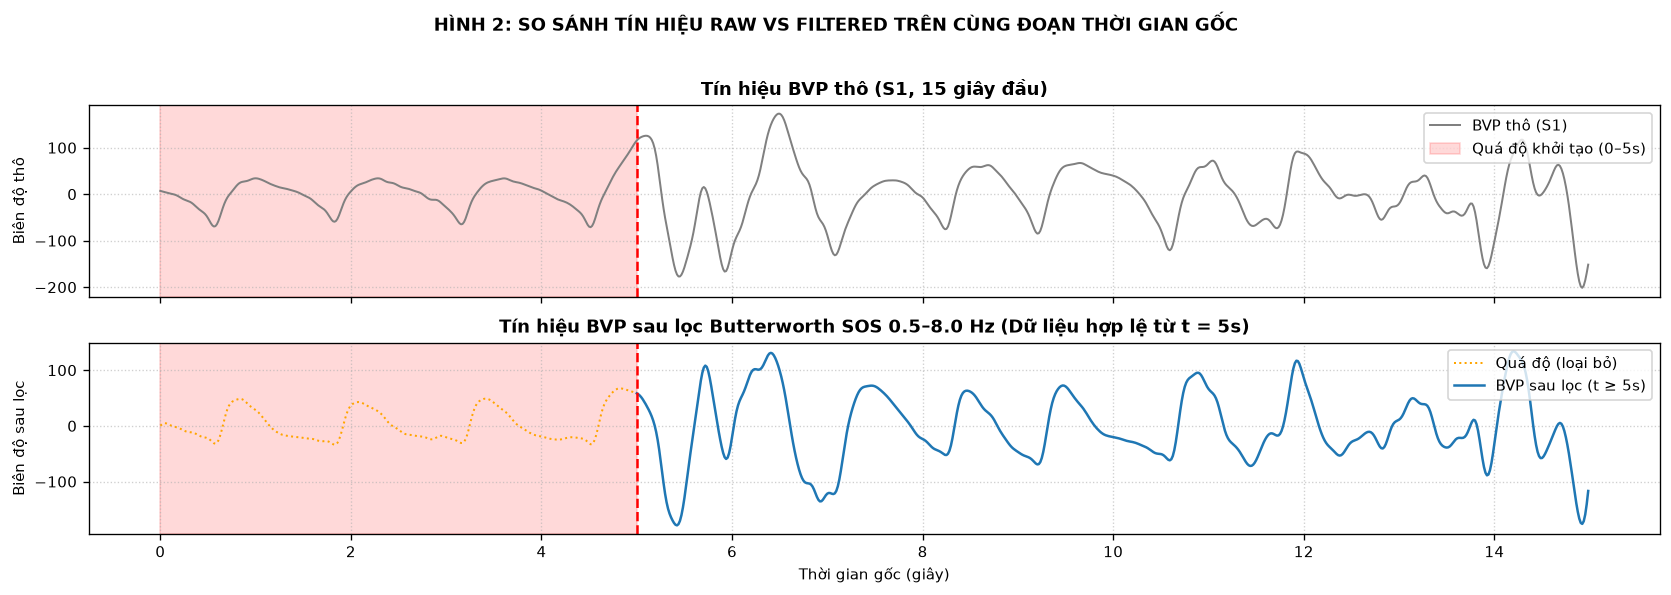

In [10]:
# Minh họa so sánh Raw vs Filtered trên cùng đoạn thời gian gốc
# Dữ liệu sau bỏ 320 mẫu bắt đầu tại t = 5.0 giây
demo_sub = "S1"
demo_raw_full = raw_bvp_dataset[demo_sub][:64 * 15]  # 15 giây đầu tiên của tín hiệu thô
t_orig = np.arange(len(demo_raw_full)) / 64.0        # Trục thời gian gốc từ t = 0s đến 15s

# Thực hiện lọc nhân quả trên 15 giây đầu với sosfilt để minh chứng giai đoạn quá độ
sos_demo = scipy.signal.butter(2, [0.5, 8.0], btype="bandpass", fs=64, output="sos").astype(np.float32)
zi_demo = np.zeros((sos_demo.shape[0], 2), dtype=np.float32)
y_filt_full, _ = scipy.signal.sosfilt(sos_demo, demo_raw_full, zi=zi_demo)

# Dữ liệu downstream hợp lệ (sau khi bỏ 320 mẫu) bắt đầu từ t = 5 giây (320/64 = 5.0s)
valid_samples = 64 * 10  # 10 giây tiếp theo (từ giây 5 đến giây 15)
y_valid = raw_dataset[demo_sub][:valid_samples]
t_valid = 5.0 + np.arange(len(y_valid)) / 64.0  # Trục thời gian bắt đầu tại t = 5.0s

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 4.8), sharex=True)

# Đồ thị 1: Tín hiệu BVP thô với vùng quá độ được đánh dấu
ax1.plot(t_orig, demo_raw_full, color="gray", linewidth=1.2, label="BVP thô (S1)")
ax1.axvspan(0, 5, color="red", alpha=0.15, label="Quá độ khởi tạo (0–5s)")
ax1.axvline(5.0, color="red", linestyle="--", linewidth=1.5)
ax1.set_ylabel("Biên độ thô")
ax1.set_title("Tín hiệu BVP thô (S1, 15 giây đầu)", fontweight="bold")
ax1.legend(loc="upper right")

# Đồ thị 2: Tín hiệu BVP sau lọc trên cùng trục thời gian gốc, dữ liệu hợp lệ bắt đầu tại t = 5s
t_transient = np.arange(320) / 64.0
ax2.plot(t_transient, y_filt_full[:320], color="orange", linestyle=":", linewidth=1.2, label="Quá độ (loại bỏ)")
ax2.plot(t_valid, y_valid, color="#1f77b4", linewidth=1.5, label="BVP sau lọc (t ≥ 5s)")
ax2.axvspan(0, 5, color="red", alpha=0.15)
ax2.axvline(5.0, color="red", linestyle="--", linewidth=1.5)
ax2.set_ylabel("Biên độ sau lọc")
ax2.set_xlabel("Thời gian gốc (giây)")
ax2.set_title("Tín hiệu BVP sau lọc Butterworth SOS 0.5–8.0 Hz (Dữ liệu hợp lệ từ t = 5s)", fontweight="bold")
ax2.legend(loc="upper right")

plt.suptitle("HÌNH 2: SO SÁNH TÍN HIỆU RAW VS FILTERED TRÊN CÙNG ĐOẠN THỜI GIAN GỐC", fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig2_causal_filtering.png"), bbox_inches="tight")
plt.show()


In [11]:
# Kiểm toán sau thực nghiệm trên train Fold1; không chỉnh drop=320 theo test.
from notebook_scientific_audits import audit_initialization
df_initialization=audit_initialization(raw_bvp_dataset,[f"S{i}" for i in range(7,16)])
df_initialization.to_csv(Path(RESULTS_DIR)/"train_initialization_audit.csv",index=False)
print("Khởi tạo lại trên tín hiệu train thật tại 60/120/180s, đối chiếu trạng thái chạy liên tục.")
print("Tiêu chí chẩn đoán công bố: PRD cửa sổ 5–9s sau reset <=1%; đây là kiểm toán hậu nghiệm.")
display(df_initialization)
display(df_initialization.groupby("status").size().rename("Số đoạn train").reset_index())


Khởi tạo lại trên tín hiệu train thật tại 60/120/180s, đối chiếu trạng thái chạy liên tục.
Tiêu chí chẩn đoán công bố: PRD cửa sổ 5–9s sau reset <=1%; đây là kiểm toán hậu nghiệm.


,Subject,raw_reset_sample,reference_window_start_seconds,prd_after_5s,max_abs_error_after_5s,status,scope
0,S7,3840,5.0,0.000369,0.000557,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...
1,S7,7680,5.0,0.000553,0.000360,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...
2,S7,11520,5.0,0.000912,0.001194,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...
3,S8,3840,5.0,0.000013,0.000057,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...
4,S8,7680,5.0,0.001502,0.000605,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...
5,S8,11520,5.0,0.001719,0.000312,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...
6,S9,3840,5.0,0.000385,0.000238,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...
7,S9,7680,5.0,0.000532,0.000174,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...
8,S9,11520,5.0,0.000072,0.000369,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...
9,S10,3840,5.0,0.000311,0.000103,PASS_1PCT_DIAGNOSTIC,post-experiment train-only reset audit; does n...


,status,Số đoạn train
0,PASS_1PCT_DIAGNOSTIC,27


---
<a id="sec4"></a>
## 4. PHÂN CHIA 5-FOLD SUBJECT-WISE & CHUẨN HÓA TUYỆT ĐỐI THEO TRAIN

### 4.1. Phân chia kiểm thử chéo 5-Fold theo đối tượng (Bảng 2 Đề cương)
- Chia cố định 15 đối tượng thành 5 fold: mỗi fold gồm 9 người Train ($60\%$), 3 người Validation ($20\%$), và 3 người Test ($20\%$).
- Phân chia theo đối tượng (Subject-wise) trước khi tạo cửa sổ, không bao giờ xáo trộn cửa sổ ngẫu nhiên. Mỗi đối tượng xuất hiện trong tập Test đúng một lần.

### 4.2. Chuẩn hóa Z-Score và Chống rò rỉ dữ liệu (No Data Leakage)
- Tham số chuẩn hóa $\mu_{\text{train}}$ và $\sigma_{\text{train}}$ được tính **DUY NHẤT** trên các chuỗi tín hiệu của các đối tượng thuộc tập Train của fold đó:
$$\mu_{\text{train}} = \frac{1}{|\text{Train}|} \sum_{t \in \text{Train}} b[t], \quad \sigma_{\text{train}} = \sqrt{\frac{1}{|\text{Train}|} \sum_{t \in \text{Train}} (b[t] - \mu_{\text{train}})^2}$$
- Cùng bộ tham số $(\mu_{\text{train}}, \sigma_{\text{train}})$ này được dùng để chuẩn hóa tập Train, Validation, Test và dữ liệu phát lại cho ESP32 tương ứng:
$$z[t] = \frac{b[t] - \mu_{\text{train}}}{\sigma_{\text{train}}}$$
- **Phân đoạn cửa sổ:** Chiều dài $N = 256$ mẫu ($4\text{ giây}$), bước nhảy $H = 128$ mẫu ($2\text{ giây}$, chồng lấp $50\%$), không chèn đệm (no padding).


In [12]:
# Cấu hình 5-Fold Subject-Wise cố định theo Bảng 2 Đề cương
FOLD_CONFIGS = {
    1: {"train": [f"S{i}" for i in range(7, 16)], "val": ["S4", "S5", "S6"], "test": ["S1", "S2", "S3"]},
    2: {"train": ["S1", "S2", "S3"] + [f"S{i}" for i in range(10, 16)], "val": ["S7", "S8", "S9"], "test": ["S4", "S5", "S6"]},
    3: {"train": [f"S{i}" for i in range(1, 7)] + ["S13", "S14", "S15"], "val": ["S10", "S11", "S12"], "test": ["S7", "S8", "S9"]},
    4: {"train": [f"S{i}" for i in range(1, 10)], "val": ["S13", "S14", "S15"], "test": ["S10", "S11", "S12"]},
    5: {"train": [f"S{i}" for i in range(4, 13)], "val": ["S1", "S2", "S3"], "test": ["S13", "S14", "S15"]}
}

from dataset import extract_windows_for_signal, prepare_fold_data as _prepare_fold_data

def prepare_fold_data(fold, dataset=raw_dataset, N=256, H=128):
    return _prepare_fold_data(fold, dataset=dataset, N=N, H=H)

fold_summary_records = []
all_fold_data = {}
for f in range(1, 6):
    f_data = prepare_fold_data(f)
    all_fold_data[f] = f_data
    fold_summary_records.append({
        "Fold": f,
        "Train Subjects": ", ".join(f_data["train_subjects"]),
        "Val Subjects": ", ".join(f_data["val_subjects"]),
        "Test Subjects": ", ".join(f_data["test_subjects"]),
        "mu_train": f"{f_data['mu_train']:.5f}",
        "sigma_train": f"{f_data['sigma_train']:.4f}",
        "Train Windows": f_data["train"]["windows"].shape[0],
        "Val Windows": f_data["val"]["windows"].shape[0],
        "Test Windows": f_data["test"]["windows"].shape[0]
    })

df_folds = pd.DataFrame(fold_summary_records)
print("BẢNG 2: PHÂN CHIA 5-FOLD SUBJECT-WISE VÀ THỐNG KÊ CỬA SỔ DỮ LIỆU")
display(df_folds)


BẢNG 2: PHÂN CHIA 5-FOLD SUBJECT-WISE VÀ THỐNG KÊ CỬA SỔ DỮ LIỆU


,Fold,Train Subjects,Val Subjects,Test Subjects,mu_train,sigma_train,Train Windows,Val Windows,Test Windows
0,1,"S7, S8, S9, S10, S11, S12, S13, S14, S15","S4, S5, S6","S1, S2, S3",-0.00052,80.6720,39778,11841,13068
1,2,"S1, S2, S3, S10, S11, S12, S13, S14, S15","S7, S8, S9","S4, S5, S6",-0.00045,80.4210,39866,12980,11841
2,3,"S1, S2, S3, S4, S5, S6, S13, S14, S15","S10, S11, S12","S7, S8, S9",-0.00051,76.5518,37914,13793,12980
3,4,"S1, S2, S3, S4, S5, S6, S7, S8, S9","S13, S14, S15","S10, S11, S12",-0.00075,70.8776,37889,13005,13793
4,5,"S4, S5, S6, S7, S8, S9, S10, S11, S12","S1, S2, S3","S13, S14, S15",-0.00075,78.3000,38614,13068,13005


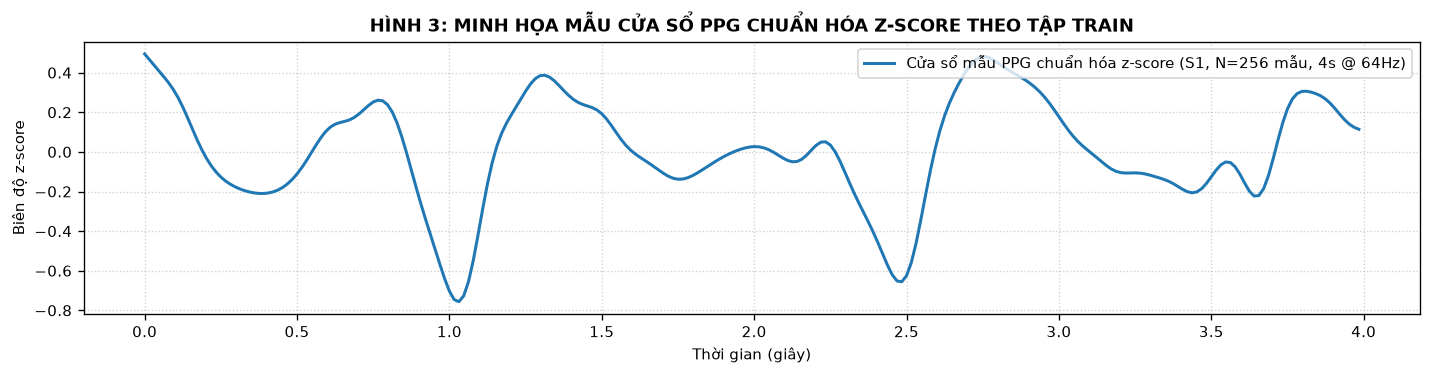

In [13]:
# Vẽ mẫu một cửa sổ chuẩn hóa
sample_window = all_fold_data[1]["test"]["windows"][50]
t_win = np.arange(256) / 64.0
plt.figure(figsize=(12, 3.2))
plt.plot(t_win, sample_window, color="#1f77b4", linewidth=1.8, label="Cửa sổ mẫu PPG chuẩn hóa z-score (S1, N=256 mẫu, 4s @ 64Hz)")
plt.title("HÌNH 3: MINH HỌA MẪU CỬA SỔ PPG CHUẨN HÓA Z-SCORE THEO TẬP TRAIN", fontweight="bold")
plt.xlabel("Thời gian (giây)")
plt.ylabel("Biên độ z-score")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig3_window_sample.png"), bbox_inches="tight")
plt.show()


In [14]:
config_registry = {}
for fold, fd in all_fold_data.items():
    for M in CONFIG.M_list:
        config_registry[fold*1000+M] = {"fold":fold, "M":M, "mu":float(np.float32(fd["mu_train"])),
            "sigma":float(np.float32(fd["sigma_train"])), "matrix_seed":CONFIG.matrix_seed,
            "protocol_hash":contract_hash(CONFIG.numerical_contract())}
save_json(Path(EXPORTS_DIR)/"config_registry.json", config_registry)
DATA_HASH = file_sha256(CACHE_FILE)


In [15]:
# =====================================================================
# SANITY CHECKS SECTION (BẮT BUỘC THEO ĐỀ CƯƠNG VÀ MỤC XLII)
# =====================================================================
print("--- TIẾN HÀNH KIỂM TRA TÍNH TOÀN VẸN (SANITY CHECKS) ---")

# 1. Kiểm tra tham số cấu hình cơ sở
assert CONFIG.fs == 64, "Tần số lấy mẫu Fs phải bằng 64 Hz"
assert CONFIG.N == 256, "Chiều dài cửa sổ N phải bằng 256 mẫu (4s)"
assert CONFIG.H == 128, "Bước nhảy H phải bằng 128 mẫu (2s)"

# 2. Kiểm tra tính rời nhau giữa các tập chia của từng fold
all_test_subjects_across_folds = []
for f in range(1, 6):
    tr = set(FOLD_CONFIGS[f]["train"])
    va = set(FOLD_CONFIGS[f]["val"])
    te = set(FOLD_CONFIGS[f]["test"])

    assert tr.isdisjoint(va), f"Fold {f}: Tập Train và Validation bị trùng đối tượng!"
    assert tr.isdisjoint(te), f"Fold {f}: Tập Train và Test bị trùng đối tượng!"
    assert va.isdisjoint(te), f"Fold {f}: Tập Validation và Test bị trùng đối tượng!"
    assert len(tr) == 9, f"Fold {f}: Train phải có đúng 9 đối tượng (60%)"
    assert len(va) == 3, f"Fold {f}: Val phải có đúng 3 đối tượng (20%)"
    assert len(te) == 3, f"Fold {f}: Test phải có đúng 3 đối tượng (20%)"
    all_test_subjects_across_folds.extend(FOLD_CONFIGS[f]["test"])

# 3. Kiểm tra mỗi đối tượng S1..S15 xuất hiện trong Test đúng 1 lần
assert sorted(all_test_subjects_across_folds) == sorted(SUBJECTS), "Mỗi đối tượng phải xuất hiện trong tập Test đúng một lần!"
assert len(all_test_subjects_across_folds) == 15, "Tổng số đối tượng test qua 5 fold phải đúng bằng 15"

# 4. Kiểm tra chống rò rỉ dữ liệu (No Data Leakage)
for f in range(1, 6):
    fd = all_fold_data[f]
    tr_sig = np.concatenate([raw_dataset[s][np.isfinite(raw_dataset[s])] for s in fd["train_subjects"]])
    assert np.isclose(fd["mu_train"], np.mean(tr_sig, dtype=np.float64), atol=1e-5), f"Fold {f}: mu_train không khớp tập Train!"
    assert np.isclose(fd["sigma_train"], np.std(tr_sig, dtype=np.float64), atol=1e-5), f"Fold {f}: sigma_train không khớp tập Train!"

# 5. Kiểm tra tính ổn định dữ liệu (không có NaN hoặc Inf trong các cửa sổ)
for f in range(1, 6):
    for split_name in ["train", "val", "test"]:
        w_mat = all_fold_data[f][split_name]["windows"]
        assert not np.isnan(w_mat).any(), f"Fold {f} {split_name}: Phát hiện giá trị NaN trong cửa sổ dữ liệu!"
        assert not np.isinf(w_mat).any(), f"Fold {f} {split_name}: Phát hiện giá trị Inf trong cửa sổ dữ liệu!"

print("-> KẾT QUẢ SANITY CHECKS: TẤT CẢ 5 KIỂM TRA ĐỀU VƯỢT QUA! (ALL PASSED)")
assert not FAST_DEBUG, "Kết quả chính thức không chạy FAST_DEBUG"
print("Cửa sổ reference không hữu hạn đã ghi nhận:", {f:{s:all_fold_data[f][s]["invalid_reference_windows"] for s in ["train","val","test"]} for f in FOLD_CONFIGS})


--- TIẾN HÀNH KIỂM TRA TÍNH TOÀN VẸN (SANITY CHECKS) ---


-> KẾT QUẢ SANITY CHECKS: TẤT CẢ 5 KIỂM TRA ĐỀU VƯỢT QUA! (ALL PASSED)
Cửa sổ reference không hữu hạn đã ghi nhận: {1: {'train': 0, 'val': 0, 'test': 0}, 2: {'train': 0, 'val': 0, 'test': 0}, 3: {'train': 0, 'val': 0, 'test': 0}, 4: {'train': 0, 'val': 0, 'test': 0}, 5: {'train': 0, 'val': 0, 'test': 0}}


---
<a id="sec5"></a>
## 5. MA TRẬN ĐO NÉN RADEMACHER & ĐÓNG GÓI BIT (BIT-PACKING)

### 5.1. Phép chiếu nén tuyến tính
- **Chiều dài vector gốc:** $N = 256$ mẫu.
- **Số phép đo khảo sát:** $M \in \{51, 77, 128\}$, tương ứng tỷ lệ đo nén thực tế $MR \in \{0.1992, 0.3008, 0.5000\}$.
- **Ma trận đo Rademacher:** Các phần tử nhận ngẫu nhiên giá trị $\mathbf{B}_{m,n} \in \{-1, +1\}$ với phân phối đều độc lập, tạo ra với seed cố định $42$. Ma trận đo chuẩn hóa:
$$\mathbf{\Phi} = \frac{1}{\sqrt{M}} \mathbf{B}, \quad \mathbf{y} = \mathbf{\Phi} \mathbf{x} \in \mathbb{R}^M$$

### 5.2. Kỹ thuật đóng gói Bit (Bit-Packing) tối ưu bộ nhớ Flash
- Mỗi hàng của $\mathbf{B}$ gồm 256 phần tử dấu $(\pm 1)$ được đóng gói thành đúng $256 / 8 = 32\text{ bytes}$ (`uint8_t`):
  * Bit $1$ biểu diễn giá trị $+1$.
  * Bit $0$ biểu diễn giá trị $-1$.
- Toàn bộ ma trận đo chỉ chiếm:
  * $M=51$: $51 \times 32 = 1.632\text{ bytes}$ ($1.6\text{ KB}$).
  * $M=77$: $77 \times 32 = 2.464\text{ bytes}$ ($2.4\text{ KB}$).
  * $M=128$: $128 \times 32 = 4.096\text{ bytes}$ ($4.0\text{ KB}$).
- Ma trận được lưu tĩnh trong bộ nhớ Flash ROM của ESP32 (`PROGMEM`), vị trí lưu trữ phải được xác nhận qua ELF/symbols ở Mục 18 và thay thế phép nhân ma trận số thực bằng các phép cộng/trừ tích lũy cực nhanh.


In [16]:
# Sinh ma trận Rademacher và đóng gói bit nhị phân
def generate_rademacher_matrix(M, N=256, seed=42):
    rng = np.random.RandomState(seed)
    B = rng.choice([-1.0, 1.0], size=(M, N)).astype(np.float32)
    Phi = (B / np.sqrt(M, dtype=np.float32)).astype(np.float32)
    return B, Phi

def pack_rademacher_matrix(B):
    M, N = B.shape
    assert N % 8 == 0, "N phải chia hết cho 8"
    n_bytes = N // 8
    packed = np.zeros((M, n_bytes), dtype=np.uint8)
    for i in range(M):
        for j in range(N):
            if B[i, j] > 0:
                packed[i, j // 8] |= (1 << (j % 8))
    return packed

def project_measurements(x, Phi):
    return np.matmul(x, Phi.T, dtype=np.float32)


In [17]:
# Khởi tạo ma trận đo cho 3 mức M
B_51, Phi_51 = generate_rademacher_matrix(51, 256, seed=42)
B_77, Phi_77 = generate_rademacher_matrix(77, 256, seed=42)
B_128, Phi_128 = generate_rademacher_matrix(128, 256, seed=42)

# Xuất file nhị phân và C header cho ESP32
for M, B_mat, Phi_mat in [(51, B_51, Phi_51), (77, B_77, Phi_77), (128, B_128, Phi_128)]:
    packed_mat = pack_rademacher_matrix(B_mat)
    # Lưu file nhị phân
    bin_path = os.path.join(EXPORTS_DIR, f"phi_M{M}.bin")
    with open(bin_path, "wb") as f:
        f.write(packed_mat.tobytes())
    # Tính mã băm SHA-256
    sha256_hash = hashlib.sha256(packed_mat.tobytes()).hexdigest()
    print(f"Cấu hình M = {M:3d}: Dung lượng Flash = {packed_mat.nbytes:4d} bytes | SHA256 = {sha256_hash}")


Cấu hình M =  51: Dung lượng Flash = 1632 bytes | SHA256 = bfa128a0d920ebee78f1b69972bb04770fb55bbacae8432568809298744a1c7a
Cấu hình M =  77: Dung lượng Flash = 2464 bytes | SHA256 = b934ee46fb659926acc127aa9bb9a090e7b9b885c1a1f4dc32b884f0af3ea9ed
Cấu hình M = 128: Dung lượng Flash = 4096 bytes | SHA256 = eaaa2ac42a1b7d4c1a051dd2aac0c3424bbdd270dc1e9ad7e03451a893c8aeac


In [18]:
# Xuất C header cho firmware ESP32
header_c_path = os.path.join(EXPORTS_DIR, "cs_matrices.h")
sos_coeff = scipy.signal.butter(2, [0.5, 8.0], btype="bandpass", fs=64, output="sos").astype(np.float32)

with open(header_c_path, "w", encoding="utf-8") as f:
    f.write("/* Auto-generated Compressed Sensing matrices and filter coefficients */\n")
    f.write("#ifndef CS_MATRICES_H\n#define CS_MATRICES_H\n\n#include <stdint.h>\n\n")
    f.write("#define CS_N 256\n#define CS_N_BYTES 32\n#define CS_SEED 42\n\n")
    f.write("const float SOS_COEFFS[2][6] = {\n")
    for s in range(2):
        b0, b1, b2, a0, a1, a2 = sos_coeff[s]
        f.write(f"    {{{b0:.9e}f, {b1:.9e}f, {b2:.9e}f, {a0:.9e}f, {a1:.9e}f, {a2:.9e}f}},\n")
    f.write("};\n\n")
    for M, B_mat in [(51, B_51), (77, B_77), (128, B_128)]:
        p_bytes = pack_rademacher_matrix(B_mat)
        inv_sqrt = 1.0 / np.sqrt(M)
        f.write(f"#define CS_INV_SQRT_M_{M} {inv_sqrt:.9e}f\n")
        f.write(f"const uint8_t B_PACKED_{M}[{M}][32] = {{\n")
        for i in range(M):
            f.write("    {" + ", ".join([f"0x{v:02X}" for v in p_bytes[i]]) + "},\n")
        f.write("};\n\n")
    f.write("#endif // CS_MATRICES_H\n")
print(f"Đã xuất C header đồng bộ cho ESP32 tại: {header_c_path}")


Đã xuất C header đồng bộ cho ESP32 tại: D:\IOT\CuoiKy\exports\20261005_canonical_lite_verified\cs_matrices.h


---
<a id="sec6"></a>
## 6. LƯỢNG TỬ HÓA ĐỐI XỨNG INT16 & ĐÓNG KHUNG GÓI TIN CRC-32

### 6.1. Lượng tử hóa đối xứng động (Symmetric INT16 Quantization)
Theo quy định Đề cương Mục 2.4, vector đo $\mathbf{y} \in \mathbb{R}^M$ được lượng tử hóa số nguyên 16-bit đối xứng trên từng gói tin:
$$a = \max_{1 \le m \le M} |y_m|$$
$$\Delta = \max\left(\frac{a}{32767}, 10^{-12}\right) \quad (\text{nếu } a = 0 \text{ thì } \Delta = 1.0)$$
$$q_m = \text{clip}\left(\text{round}\left(\frac{y_m}{\Delta}\right), -32767, 32767\right) \in \text{INT16}$$
- Giá trị biên $-32768$ **không được sử dụng** để bảo toàn tính đối xứng số học.
- Giá trị giải lượng tử tại máy thu:
$$\tilde{y}_m = q_m \cdot \Delta$$

### 6.2. Cấu trúc Header 16-byte và Mã kiểm tra lỗi IEEE 802.3 CRC-32 (Bảng 3 Đề cương)
- Header nhị phân little-endian gồm 16 bytes:
  1. `version` ($1\text{ byte}$): $1$
  2. `flags` ($1\text{ byte}$): $0$ (chế độ INT16)
  3. `config_id` ($2\text{ bytes}$): Mã cấu hình `config_id = fold*1000 + M` (tra registry để lấy M, chuẩn hóa và decoder)
  4. `frame_index` ($4\text{ bytes}$): Số thứ tự gói
  5. `scale_delta` ($4\text{ bytes}$): Giá trị $\Delta$ số thực IEEE-754
  6. `crc32` ($4\text{ bytes}$): Mã CRC-32 tính trên 12 byte đầu của header cộng toàn bộ $2M$ bytes payload
- Kích thước gói ứng dụng hoàn chỉnh: $2M + 16\text{ bytes}$.
  * $M=51 \implies 118\text{ bytes}$
  * $M=77 \implies 170\text{ bytes}$
  * $M=128 \implies 272\text{ bytes}$

- Scale được làm tròn hướng lên tới Float32 không nhỏ hơn `max(a/32767, 1e-12)` theo đề cương hiệu chỉnh. Máy thu từ chối CRC sai, config_id lạ, version/flags không hỗ trợ, scale không hữu hạn/không dương và payload sai kích thước trước giải mã.

In [19]:
# Thuật toán lượng tử hóa đối xứng INT16 và đóng gói CRC32
HEADER_FORMAT_PART1 = "<BBHIf"
HEADER_SIZE = 16

def round_half_away_from_zero(val):
    """
    Symmetric rounding matching standard C roundf():
    Halfway cases are rounded away from zero.
    """
    x = np.asarray(val,dtype=np.float64)
    return np.sign(x) * np.floor(np.abs(x) + 0.5)

def quantize_int16(y):
    """
    Symmetric INT16 quantization of measurement vector y.
    y: 1D array of shape [M] or 2D array of shape [B, M]
    Returns:
      q: int16 array of same shape
      delta: float32 scale factor (scalar or shape [B, 1])
      y_tilde: dequantized float32 array
      clip_count: number of elements clipped
    """
    y = np.asarray(y, dtype=np.float32)
    if y.ndim not in (1,2) or not np.isfinite(y).all() or y.shape[-1] == 0:
        raise ValueError('Measurements must be a nonempty finite vector or matrix')
    is_1d = (y.ndim == 1)
    if is_1d:
        y = y[np.newaxis, :]
        
    a = np.max(np.abs(y), axis=1, keepdims=True)
    exact_scale = np.maximum(a.astype(np.float64)/32767,1e-12)
    delta = exact_scale.astype(np.float32)
    below = delta.astype(np.float64) < exact_scale
    delta[below] = np.nextafter(delta[below],np.float32(np.inf))
    # If all zeros in a row, set delta = 1.0
    zero_rows = (a == 0.0)
    delta[zero_rows] = 1.0
    
    scaled = y / delta
    rounded = round_half_away_from_zero(scaled)
    
    clip_mask = (rounded < -32767) | (rounded > 32767)
    clip_count = int(np.sum(clip_mask))
    
    q = np.clip(rounded, -32767, 32767).astype(np.int16)
    with np.errstate(over='ignore'):
        y_tilde = (q.astype(np.float32) * delta).astype(np.float32)
    if not np.isfinite(y_tilde).all():raise ValueError('Float32 dequantization overflow; finite reconstruction unrepresentable')
    
    if is_1d:
        return q[0], float(delta[0, 0]), y_tilde[0], clip_count
    return q, delta, y_tilde, clip_count


In [20]:
def pack_packet(q_int16, delta, frame_index, config_id, version=1, flags=0):
    """
    Packs quantized INT16 measurements into a 16-byte header + 2M payload packet.
    """
    q_bytes = q_int16.astype("<i2").tobytes()
    header_12 = struct.pack(HEADER_FORMAT_PART1, version, flags, config_id, frame_index, float(delta))
    crc = zlib.crc32(header_12 + q_bytes) & 0xffffffff
    full_header = header_12 + struct.pack("<I", crc)
    return full_header + q_bytes

def unpack_packet(packet_bytes,config_registry=None):
    if config_registry is None:
        config_registry = globals().get("config_registry", {})
    """
    Unpacks packet, verifies CRC32, returns fields and dequantized y_tilde.
    """
    if len(packet_bytes) < HEADER_SIZE:
        raise ValueError(f"Packet too short: {len(packet_bytes)} < {HEADER_SIZE}")
        
    header_12 = packet_bytes[:12]
    expected_crc = struct.unpack("<I", packet_bytes[12:16])[0]
    payload = packet_bytes[16:]
    
    actual_crc = zlib.crc32(header_12 + payload) & 0xffffffff
    if actual_crc != expected_crc:
        raise ValueError(f"CRC32 mismatch! Expected 0x{expected_crc:08X}, got 0x{actual_crc:08X}")
        
    version, flags, config_id, frame_index, delta = struct.unpack(HEADER_FORMAT_PART1, header_12)
    if version != 1:
        raise ValueError('Unsupported version')
    if flags not in (0,1):
        raise ValueError('Unsupported flags')
    if config_registry is None or (config_id not in config_registry and str(config_id) not in config_registry):
        raise ValueError(f'Unknown config_id {config_id}')
    cfg = config_registry.get(config_id,config_registry.get(str(config_id)))
    expected_bytes = int(cfg['M']) * (2 if flags == 0 else 4)
    if len(payload) != expected_bytes:
        raise ValueError(f'Wrong payload length {len(payload)} != {expected_bytes}')
    if not np.isfinite(delta) or delta <= 0:
        raise ValueError('Scale must be positive finite')
    
    if flags == 0:  # INT16 mode
        q = np.frombuffer(payload, dtype="<i2")
        if np.any(q == -32768):
            raise ValueError('Reserved INT16 value -32768')
        with np.errstate(over='ignore'):
            y_tilde = q.astype(np.float32) * delta
        if not np.isfinite(y_tilde).all():raise ValueError('Packet dequantization overflow/nonfinite input')
    else:  # Float32 mode
        y_tilde = np.frombuffer(payload, dtype="<f4")
        q = None
        if delta != 1 or not np.isfinite(y_tilde).all():
            raise ValueError('Invalid Float32 payload/scale')
        
    return {
        "version": version,
        "flags": flags,
        "config_id": config_id,
        "frame_index": frame_index,
        "delta": delta,
        "q": q,
        "y_tilde": y_tilde,
        "crc32": expected_crc
    }


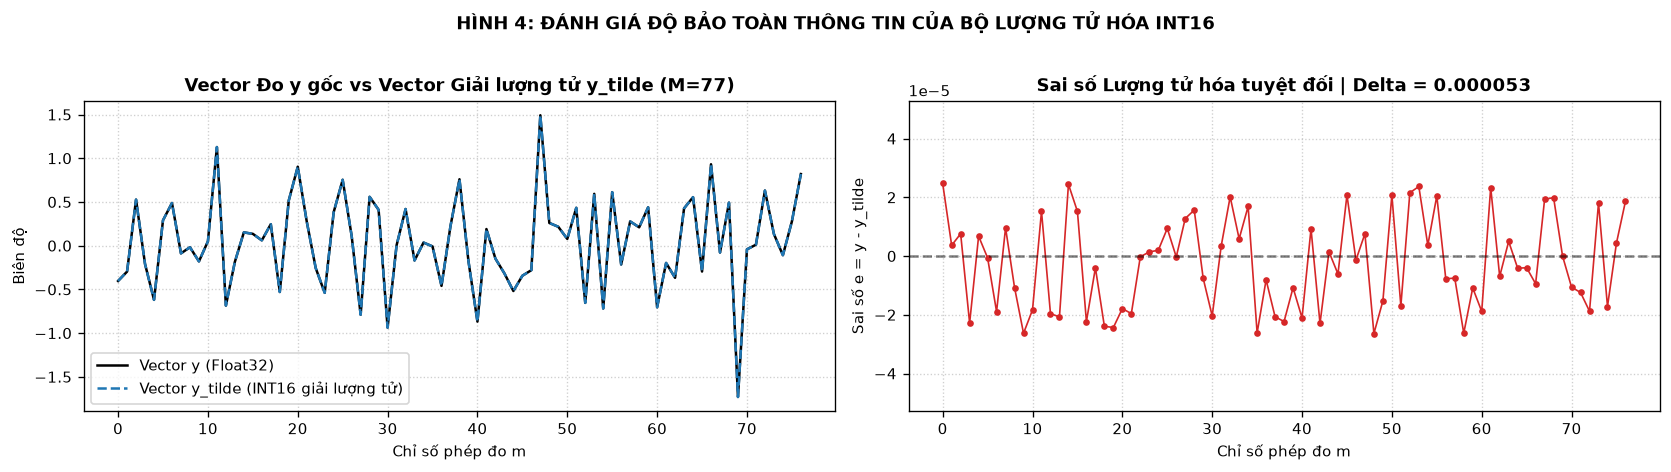

-> Thống kê lượng tử hóa: Sai số tối đa = 0.00002638 (nhỏ hơn Delta = 0.00005278), Cắt biên = 0


In [21]:
# Phân tích sai số lượng tử hóa trên cửa sổ mẫu
y_sample_meas = project_measurements(sample_window, Phi_77)
q_sample, delta_sample, y_sample_tilde, clip_cnt = quantize_int16(y_sample_meas)
q_err = y_sample_meas - y_sample_tilde

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.8))
ax1.plot(y_sample_meas, label="Vector y (Float32)", color="black", linewidth=1.5)
ax1.plot(y_sample_tilde, label="Vector y_tilde (INT16 giải lượng tử)", color="#1f77b4", linestyle="--", linewidth=1.5)
ax1.set_title("Vector Đo y gốc vs Vector Giải lượng tử y_tilde (M=77)", fontweight="bold")
ax1.set_xlabel("Chỉ số phép đo m")
ax1.set_ylabel("Biên độ")
ax1.legend()

ax2.plot(q_err, color="#d62728", marker="o", markersize=3, linewidth=1.0)
ax2.axhline(0, color="black", linestyle="--", alpha=0.5)
ax2.set_title(f"Sai số Lượng tử hóa tuyệt đối | Delta = {delta_sample:.6f}", fontweight="bold")
ax2.set_xlabel("Chỉ số phép đo m")
ax2.set_ylabel("Sai số e = y - y_tilde")
ax2.set_ylim([-delta_sample, delta_sample])

plt.suptitle("HÌNH 4: ĐÁNH GIÁ ĐỘ BẢO TOÀN THÔNG TIN CỦA BỘ LƯỢNG TỬ HÓA INT16", fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig4_quantization_error.png"), bbox_inches="tight")
plt.show()

print(f"-> Thống kê lượng tử hóa: Sai số tối đa = {np.max(np.abs(q_err)):.8f} (nhỏ hơn Delta = {delta_sample:.8f}), Cắt biên = {clip_cnt}")


---
<a id="sec7"></a>
## 7. CƠ SỞ DCT-II TRỰC CHUẨN & PHÂN TÍCH ĐỘ NÉN THƯA TÍN HIỆU TRAIN

### 7.1. Cơ sở DCT-II trực chuẩn (Proposal Section 3.3)
- Ma trận biến đổi DCT-II trực chuẩn $\mathbf{C} \in \mathbb{R}^{N \times N}$ thỏa mãn $\mathbf{C}^T \mathbf{C} = \mathbf{I}$:
$$\alpha = \mathbf{C} \mathbf{x}, \quad \mathbf{x} = \mathbf{\Psi} \alpha, \quad \text{với } \mathbf{\Psi} = \mathbf{C}^T$$
- Theo dõi năng lượng tích lũy của các hệ số DCT sắp xếp giảm dần trên tập Train để kiểm chứng giả định xấp xỉ thưa (compressible/approximately sparse) của tín hiệu PPG.


In [22]:
# Xây dựng ma trận DCT-II trực chuẩn khớp hoàn toàn scipy.fft.dct
def build_dct_matrix(N=256):
    return scipy.fft.dct(np.eye(N,dtype=np.float32),type=2,norm='ortho',axis=0)

DCT_MAT = build_dct_matrix(256)
PSI_MAT = DCT_MAT.T.copy() # Từ điển tổng hợp

# Phân tích năng lượng tích lũy của các hệ số DCT trên tập Train (Fold 1)
# Lấy mẫu cân bằng 150 cửa sổ từ mỗi đối tượng train trong số 9 subjects của Fold 1 (tổng 1350 cửa sổ)
# dọc theo timeline của từng subject để tránh thiên vị thời gian
train_wins_f1 = all_fold_data[1]["train"]["windows"]
train_subs_f1 = all_fold_data[1]["train"]["subjects"]
unique_train_subs = np.unique(train_subs_f1)
balanced_indices = []
for s in unique_train_subs:
    s_idx = np.where(train_subs_f1 == s)[0]
    sel = s_idx[np.linspace(0, len(s_idx) - 1, 150, dtype=int)]
    balanced_indices.extend(sel)

sample_train_subset = train_wins_f1[balanced_indices]
print(f"-> DCT & SVD Subspace Analysis: Lấy mẫu cân bằng {len(sample_train_subset)} cửa sổ (150 cửa sổ/subject qua 9 đối tượng train của Fold 1, seed=42)")


-> DCT & SVD Subspace Analysis: Lấy mẫu cân bằng 1350 cửa sổ (150 cửa sổ/subject qua 9 đối tượng train của Fold 1, seed=42)


In [23]:
# 1. DCT Sparsity Analysis
dct_coeffs = np.matmul(sample_train_subset, DCT_MAT.T) # [1350, 256]
abs_sorted = np.sort(np.abs(dct_coeffs), axis=1)[:, ::-1]
energy_sorted = abs_sorted ** 2
cum_energy = np.cumsum(energy_sorted, axis=1) / np.sum(energy_sorted, axis=1, keepdims=True)
mean_cum_energy = np.mean(cum_energy, axis=0) * 100.0

k_90 = int(np.argmax(mean_cum_energy >= 90.0)) + 1
k_95 = int(np.argmax(mean_cum_energy >= 95.0)) + 1
k_99 = int(np.argmax(mean_cum_energy >= 99.0)) + 1


In [24]:
# 2. SVD Subspace Rank Analysis
# Phân tích phổ trị riêng của không gian con tín hiệu tập Train
_, s_vals, _ = np.linalg.svd(sample_train_subset, full_matrices=False)
s_energy = (s_vals ** 2) / np.sum(s_vals ** 2) * 100.0
cum_s_energy = np.cumsum(s_energy)

r_90 = int(np.argmax(cum_s_energy >= 90.0)) + 1
r_95 = int(np.argmax(cum_s_energy >= 95.0)) + 1
r_99 = int(np.argmax(cum_s_energy >= 99.0)) + 1


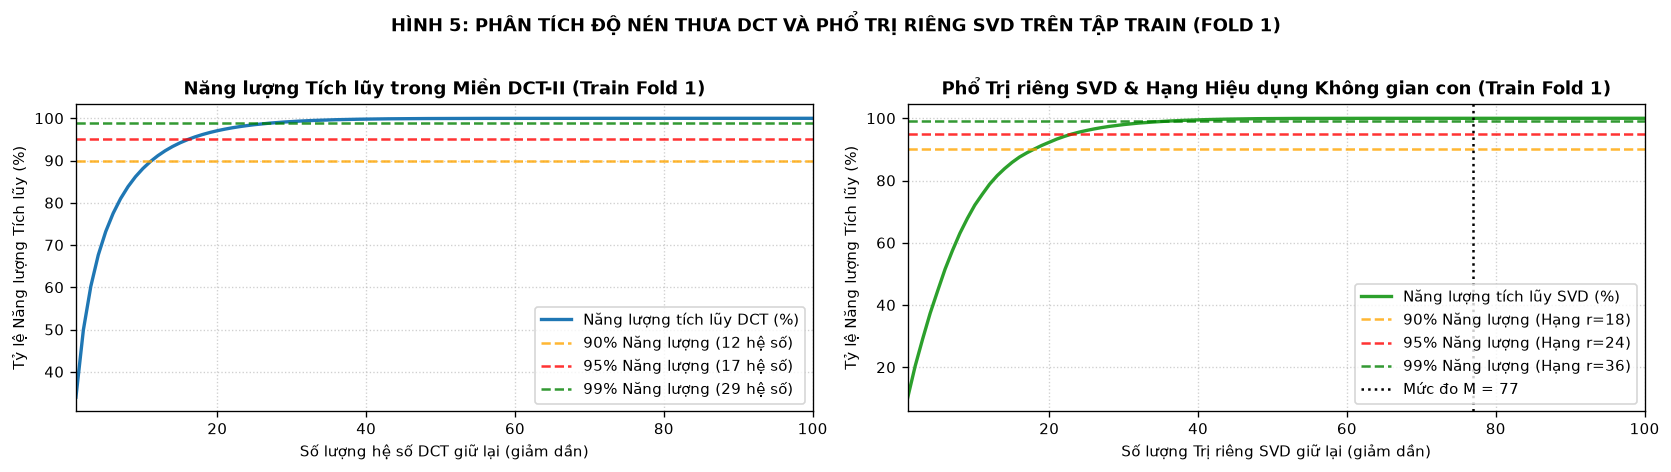

-> Phân tích độ nén thưa DCT: Cần 12 hệ số để giữ 90% năng lượng, 17 hệ số để giữ 95%, và 29 hệ số để giữ 99% năng lượng tín hiệu PPG.
-> Phân tích không gian con SVD: Hạng hiệu dụng để giữ 90% năng lượng là r=18, 95% là r=24, và 99% là r=36.
   Đây là mô tả năng lượng thực nghiệm trên Train Fold 1; Butterworth không phải bộ lọc cắt lý tưởng.
   r99 < M không tự chứng minh hạng hoặc điều kiện số của Phi trên không gian con, cũng không bảo đảm sai số test.


In [25]:
fig, (ax_dct, ax_svd) = plt.subplots(1, 2, figsize=(14, 3.8))

# Subplot 1: DCT
ax_dct.plot(range(1, 257), mean_cum_energy, color="#1f77b4", linewidth=2.0, label="Năng lượng tích lũy DCT (%)")
ax_dct.axhline(90.0, color="orange", linestyle="--", alpha=0.8, label=f"90% Năng lượng ({k_90} hệ số)")
ax_dct.axhline(95.0, color="red", linestyle="--", alpha=0.8, label=f"95% Năng lượng ({k_95} hệ số)")
ax_dct.axhline(99.0, color="green", linestyle="--", alpha=0.8, label=f"99% Năng lượng ({k_99} hệ số)")
ax_dct.set_title("Năng lượng Tích lũy trong Miền DCT-II (Train Fold 1)", fontweight="bold")
ax_dct.set_xlabel("Số lượng hệ số DCT giữ lại (giảm dần)")
ax_dct.set_ylabel("Tỷ lệ Năng lượng Tích lũy (%)")
ax_dct.set_xlim([1, 100])
ax_dct.legend(loc="lower right")

# Subplot 2: SVD
ax_svd.plot(range(1, len(s_vals) + 1), cum_s_energy, color="#2ca02c", linewidth=2.0, label="Năng lượng tích lũy SVD (%)")
ax_svd.axhline(90.0, color="orange", linestyle="--", alpha=0.8, label=f"90% Năng lượng (Hạng r={r_90})")
ax_svd.axhline(95.0, color="red", linestyle="--", alpha=0.8, label=f"95% Năng lượng (Hạng r={r_95})")
ax_svd.axhline(99.0, color="green", linestyle="--", alpha=0.8, label=f"99% Năng lượng (Hạng r={r_99})")
ax_svd.axvline(77, color="black", linestyle=":", label="Mức đo M = 77")
ax_svd.set_title("Phổ Trị riêng SVD & Hạng Hiệu dụng Không gian con (Train Fold 1)", fontweight="bold")
ax_svd.set_xlabel("Số lượng Trị riêng SVD giữ lại (giảm dần)")
ax_svd.set_ylabel("Tỷ lệ Năng lượng Tích lũy (%)")
ax_svd.set_xlim([1, 100])
ax_svd.legend(loc="lower right")

plt.suptitle("HÌNH 5: PHÂN TÍCH ĐỘ NÉN THƯA DCT VÀ PHỔ TRỊ RIÊNG SVD TRÊN TẬP TRAIN (FOLD 1)", fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig5_dct_energy_compaction.png"), bbox_inches="tight")
plt.show()

print(f"-> Phân tích độ nén thưa DCT: Cần {k_90} hệ số để giữ 90% năng lượng, {k_95} hệ số để giữ 95%, và {k_99} hệ số để giữ 99% năng lượng tín hiệu PPG.")
print(f"-> Phân tích không gian con SVD: Hạng hiệu dụng để giữ 90% năng lượng là r={r_90}, 95% là r={r_95}, và 99% là r={r_99}.")
print("   Đây là mô tả năng lượng thực nghiệm trên Train Fold 1; Butterworth không phải bộ lọc cắt lý tưởng.")
print("   r99 < M không tự chứng minh hạng hoặc điều kiện số của Phi trên không gian con, cũng không bảo đảm sai số test.")


---
<a id="sec8"></a>
## 8. BỘ GIẢI MÃ CƠ SỞ OMP–DCT & KIỂM THỬ ĐƠN VỊ SỐ HỌC

### 8.1. Thuật toán OMP–DCT chuẩn khoa học (Bảng 5 Đề cương)
- **Từ điển tương đương:** $\mathbf{A} = \mathbf{\Phi} \mathbf{\Psi} \in \mathbb{R}^{M \times N}$.
- **Chuẩn hóa cột:** Chuẩn Euclid từng cột $d_j = \|\mathbf{A}_{:, j}\|_2$, ma trận chuẩn hóa $\bar{\mathbf{A}} = \mathbf{A} \mathbf{D}^{-1}$.
- **Quá trình lặp:**
  1. Khởi tạo phần dư $\mathbf{r}_0 = \tilde{\mathbf{y}}$, tập chỉ số $\Lambda_0 = \emptyset$.
  2. Tại bước $k$: chọn atom $j^* \notin \Lambda_{k-1}$ có $|\bar{\mathbf{A}}_{:, j^*}^T \mathbf{r}_{k-1}|$ lớn nhất.
  3. Cập nhật tập chỉ số $\Lambda_k = \Lambda_{k-1} \cup \{j^*\}$.
  4. Giải bài toán bình phương cực tiểu bằng QR tăng dần, tái trực chuẩn hóa hai lần và giải hệ tam giác; loại cột chuẩn quá nhỏ, ghi nhận hạng suy biến: $\beta_{\Lambda_k} = \arg\min \|\tilde{\mathbf{y}} - \bar{\mathbf{A}}_{\Lambda_k} \beta\|_2$.
  5. Cập nhật phần dư $\mathbf{r}_k = \tilde{\mathbf{y}} - \bar{\mathbf{A}}_{\Lambda_k} \beta_{\Lambda_k}$.
  6. Điều kiện dừng: đạt $K_{\max}$ hoặc $\|\mathbf{r}_k\|_2 \le 10^{-6} \max(\|\tilde{\mathbf{y}}\|_2, 1.0)$.
  7. Hạng được theo dõi trên mọi cửa sổ; điều kiện số 2-norm được khảo sát riêng trên 32 cửa sổ/người chọn đều theo thời gian ở Mục 15, không bảo đảm cho toàn bộ test.
   8. Hoàn nguyên hệ số: $\hat{\alpha} = \beta / \mathbf{d}$, tái tạo $\hat{\mathbf{x}} = \mathbf{\Psi} \hat{\alpha}$.

In [26]:
# Lớp bộ giải mã OMP-DCT sử dụng LAPACK gelsy (QR hoàn toàn)
import scipy.linalg

class OMPDecoder:
    def __init__(self,Phi,N=256):
        self.Phi=np.asarray(Phi,dtype=np.float32);self.M,self.N=self.Phi.shape
        if self.N!=N:raise ValueError('Wrong N')
        self.C=build_dct_matrix(N);self.Psi=self.C.T.copy()
        self.A=(self.Phi@self.Psi).astype(np.float32)
        norms=np.linalg.norm(self.A,axis=0).astype(np.float32)
        self.available=norms>=1e-12
        self.d=np.where(self.available,norms,1).astype(np.float32)
        self.A_bar=(self.A/self.d[None,:]).astype(np.float32)
        self.dropped_columns=int(np.sum(~self.available))

    def decode_path(self,y_tilde,candidates,tol=1e-6):
        y=np.asarray(y_tilde,dtype=np.float32)
        if y.shape!=(self.M,) or not np.isfinite(y).all():raise ValueError('Invalid measurement')
        candidates=sorted(set(int(k) for k in candidates))
        if not candidates or candidates[0]<=0 or candidates[-1]>=self.M:raise ValueError('Require 0<K<M')
        self.last_support=[]
        limit=candidates[-1]; threshold=tol*max(float(np.linalg.norm(y)),1.)
        Q=np.zeros((self.M,limit),dtype=np.float32);R=np.zeros((limit,limit),dtype=np.float32)
        rhs=np.zeros(limit,dtype=np.float32);selected=[];r=y.copy();outputs={}
        reason='max_iter';last=np.zeros(self.N,dtype=np.float32)
        if float(np.linalg.norm(y))<=threshold:
            return {k:(last.copy(),'small_measurement',0) for k in candidates}
        for step in range(limit):
            corr=np.abs(self.A_bar.T@r);corr[~self.available]=-np.inf
            if selected:corr[selected]=-np.inf
            j=int(np.argmax(corr))
            if not np.isfinite(corr[j]):reason='no_more_atoms';break
            atom=self.A_bar[:,j];v=atom.copy()
            if step:
                h=Q[:,:step].T@v;v-=Q[:,:step]@h
                correction=Q[:,:step].T@v;h+=correction;v-=Q[:,:step]@correction
                R[:step,step]=h
            diagonal=float(np.linalg.norm(v))
            if diagonal<=1e-7:reason='rank_deficient';break
            selected.append(j);Q[:,step]=v/diagonal;R[step,step]=diagonal
            rhs[step]=Q[:,step]@y
            r=y-Q[:,:step+1]@rhs[:step+1]
            stop=float(np.linalg.norm(r))<=threshold
            if step+1 in candidates or stop or step+1==limit:
                beta=scipy.linalg.solve_triangular(R[:step+1,:step+1],rhs[:step+1],check_finite=False)
                alpha=np.zeros(self.N,dtype=np.float32);alpha[selected]=beta/self.d[selected]
                last=(self.Psi@alpha).astype(np.float32)
                if not np.isfinite(last).all():reason='nonfinite_solution';break
                if step+1 in candidates:outputs[step+1]=(last.copy(),'max_iter',step+1)
            if stop:reason='residual_tol';break
        if reason!='max_iter':
            for k in candidates:
                if k>=len(selected):outputs[k]=(last.copy(),reason,len(selected))
        for k in candidates:
            if k not in outputs:outputs[k]=(last.copy(),reason,len(selected))
        self.last_support=list(selected)
        return outputs

    def decode_single(self,y_tilde,K_max=32,tol=1e-6,track_stats=False):
        if K_max<=0:
            result=(np.zeros(self.N,dtype=np.float32),'zero_iterations',0)
        else:result=self.decode_path(y_tilde,[K_max],tol)[K_max]
        return result if track_stats else result[0]

    def decode_batch(self,Y_tilde,K_max=32,tol=1e-6,track_stats=False):
        predictions=[];reasons=[];iterations=[]
        for y in Y_tilde:
            x,reason,n=self.decode_single(y,K_max,tol,True)
            predictions.append(x);reasons.append(reason);iterations.append(n)
        p=np.asarray(predictions,dtype=np.float32)
        return (p,np.asarray(reasons),np.asarray(iterations)) if track_stats else p

# KIỂM THỬ ĐƠN VỊ (UNIT TEST) TRÊN TÍN HIỆU THƯA NHÂN TẠO
omp_test = OMPDecoder(Phi_77)
# Tạo tín hiệu nhân tạo có đúng 5 hệ số DCT khác 0 (5-sparse)
alpha_synth = np.zeros(256, dtype=np.float32)
alpha_synth[[5, 12, 25, 40, 60]] = [10.0, -8.0, 6.0, -4.0, 3.0]
x_synth = DCT_MAT.T @ alpha_synth
y_synth = project_measurements(x_synth, Phi_77)
_, _, yt_synth, _ = quantize_int16(y_synth)
x_rec_synth, stop_r, iters = omp_test.decode_single(yt_synth, K_max=16, track_stats=True)

prd_synth = 100.0 * np.linalg.norm(x_synth - x_rec_synth) / np.linalg.norm(x_synth)
assert prd_synth < 1.0, f"Unit test OMP thất bại, PRD = {prd_synth:.2f}%"
print(f"-> Kiểm thử đơn vị OMP với QR tăng dần tái trực chuẩn hóa hai lần trên tín hiệu 5-sparse: THÀNH CÔNG!")
print(f"   PRD = {prd_synth:.4f}% < 1.0% | Điều kiện dừng: '{stop_r}' sau {iters} vòng lặp.")


-> Kiểm thử đơn vị OMP với QR tăng dần tái trực chuẩn hóa hai lần trên tín hiệu 5-sparse: THÀNH CÔNG!
   PRD = 0.0019% < 1.0% | Điều kiện dừng: 'max_iter' sau 16 vòng lặp.


---
<a id="sec9"></a>
## 9. KIẾN TRÚC MẠNG NƠ-RON CNN 1D TĂNG MẪU TẦNG BẬC & ĐỐI CHỨNG TUYẾN TÍNH

### 9.1. Kiến trúc CNN 1D Hierarchical Upsampling (Bảng 4 Đề cương)
- **Đầu vào:** Vector đo đã giải lượng tử $\tilde{\mathbf{y}} \in \mathbb{R}^{B \times M}$.
- **Tầng chiếu tuyến tính và Reshape:** $\text{Linear}(M, 256) \to \text{view}(B, 64, 4)$.
- **Khối 1:** Nearest $\times 2 \to \text{Conv1d}(64 \to 64, k=3, p=1) \to \text{BatchNorm1d} \to \text{LeakyReLU}(0.1) \to [B, 64, 8]$.
- **Khối 2:** Nearest $\times 4 \to \text{Conv1d}(64 \to 32, k=3, p=1) \to \text{BatchNorm1d} \to \text{LeakyReLU}(0.1) \to [B, 32, 32]$.
- **Khối 3:** Nearest $\times 4 \to \text{Conv1d}(32 \to 16, k=3, p=1) \to \text{BatchNorm1d} \to \text{LeakyReLU}(0.1) \to [B, 16, 128]$.
- **Khối 4:** Nearest $\times 2 \to \text{Conv1d}(16 \to 8, k=3, p=1) \to \text{BatchNorm1d} \to \text{LeakyReLU}(0.1) \to [B, 8, 256]$.
- **Tầng đầu ra:** $\text{Conv1d}(8 \to 1, k=3, p=1) \to [B, 1, 256] \to \text{squeeze}(1) \to [B, 256]$. Đầu ra tuyến tính hoàn toàn (không dùng Sigmoid, không kẹp ngưỡng).
- **Tổng số tham số học được (Parameters):**
  * $M=51 \implies 34.049\text{ tham số}$
  * $M=77 \implies 40.705\text{ tham số}$
  * $M=128 \implies 53.761\text{ tham số}$

### 9.2. Kiến trúc Đối chứng Tuyến tính (Linear Baseline) tại $M=77$
- Mô hình tuyến tính thuần túy: $\text{Linear}(77, 256)$ không chứa các khối tích chập hay hàm kích hoạt phi tuyến, dùng để chứng minh giá trị gia tăng của các tầng tích chập sâu.

### 9.3. ResLinCNN_Lite: tái tạo tuyến tính và hiệu chỉnh residual
Đầu vào vẫn là vector đo đã giải lượng tử. Linear(M,256) tạo x0; stem Conv1d(1,16,k=5), ba block residual hai Conv1d k=3 với dilation 1/2/4, và head Conv1d(16,1,k=5) tạo residual; đầu ra x_hat=x0+residual. Head khởi tạo zero; x0 lúc khởi tạo không phải mô hình Linear đã train. Tham số: M51=18.193, M77=24.849, M128=37.905. Ít tham số không tự bảo đảm train hay inference nhanh hơn. Hướng linear + residual có tiền lệ [DR²-Net](https://arxiv.org/abs/1702.05743); hiệu quả của biến thể PPG này phải được đo.


In [27]:
# Định nghĩa khối tích chập tăng mẫu
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, scale_factor, kernel_size=3, padding=1, negative_slope=0.1, use_bn=True):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=scale_factor, mode="nearest")
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.use_bn = use_bn
        if use_bn:
            self.bn = nn.BatchNorm1d(out_channels, affine=True)
        self.act = nn.LeakyReLU(negative_slope=negative_slope)

    def forward(self, x):
        x = self.upsample(x)
        x = self.conv(x)
        if self.use_bn:
            x = self.bn(x)
        return self.act(x)

# Định nghĩa Bộ giải mã CNN 1D
class CNN1DDecoder(nn.Module):
    def __init__(self, M, N=256, use_bn=True):
        super().__init__()
        self.M = M
        self.N = N
        self.use_bn = use_bn

        self.fc = nn.Linear(M, 256, bias=True)
        self.block1 = ConvBlock(64, 64, scale_factor=2, kernel_size=3, padding=1, use_bn=use_bn)
        self.block2 = ConvBlock(64, 32, scale_factor=4, kernel_size=3, padding=1, use_bn=use_bn)
        self.block3 = ConvBlock(32, 16, scale_factor=4, kernel_size=3, padding=1, use_bn=use_bn)
        self.block4 = ConvBlock(16, 8, scale_factor=2, kernel_size=3, padding=1, use_bn=use_bn)
        self.out_conv = nn.Conv1d(8, 1, kernel_size=3, padding=1, bias=True)

    def forward(self, y):
        x = self.fc(y)
        x = x.view(-1, 64, 4)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.out_conv(x)
        return x.squeeze(1)


In [28]:
# Định nghĩa Bộ giải mã Tuyến tính thuần túy (Linear Baseline)
class LinearDecoder(nn.Module):
    def __init__(self, M=77, N=256):
        super().__init__()
        self.fc = nn.Linear(M, N, bias=True)

    def forward(self, y):
        return self.fc(y)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# KIỂM THỬ SỐ LƯỢNG THAM SỐ CHUẨN XÁC
param_specs = [(51, 34049), (77, 40705), (128, 53761)]
for m_val, exp_params in param_specs:
    m_test = CNN1DDecoder(m_val)
    actual_params = count_parameters(m_test)
    assert actual_params == exp_params, f"Lỗi số lượng tham số M={m_val}: {actual_params} != {exp_params}"
    # Kiểm tra kích thước tensor đầu ra
    dummy_out = m_test(torch.randn(2, m_val))
    assert dummy_out.shape == (2, 256), f"Kích thước đầu ra sai: {dummy_out.shape}"
    print(f"Cấu hình CNN 1D M = {m_val:3d}: Số tham số = {actual_params:5d} | Khớp hoàn toàn đặc tả Bảng 4 Đề cương!")

m_lin = LinearDecoder(77)
print(f"Cấu hình Linear Baseline M =  77: Số tham số = {count_parameters(m_lin):5d} | Khớp hoàn toàn đặc tả Đề cương!")


Cấu hình CNN 1D M =  51: Số tham số = 34049 | Khớp hoàn toàn đặc tả Bảng 4 Đề cương!
Cấu hình CNN 1D M =  77: Số tham số = 40705 | Khớp hoàn toàn đặc tả Bảng 4 Đề cương!
Cấu hình CNN 1D M = 128: Số tham số = 53761 | Khớp hoàn toàn đặc tả Bảng 4 Đề cương!
Cấu hình Linear Baseline M =  77: Số tham số = 19968 | Khớp hoàn toàn đặc tả Đề cương!


In [29]:
# Định nghĩa ResLinCNN_Lite bổ sung; giữ nguyên CNN và Linear gốc.
class LiteResidualBlock(nn.Module):
    """Two same-length dilated temporal convolutions with a local skip."""

    def __init__(self, channels=16, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, dilation=dilation, padding=dilation)
        self.conv2 = nn.Conv1d(channels, channels, 3, dilation=dilation, padding=dilation)
        self.act = nn.LeakyReLU(.1)

    def forward(self, x):
        return self.act(x + self.conv2(self.act(self.conv1(x))))

class ResLinCNNLite(nn.Module):
    """Learned linear reconstruction plus a zero-initialized residual CNN."""

    def __init__(self, M, N=256, channels=16):
        super().__init__()
        if N != 256 or channels != 16:
            raise ValueError('The approved Lite architecture requires N=256 and channels=16')
        if M <= 0:
            raise ValueError('M must be positive')
        self.M, self.N = M, N
        self.linear = nn.Linear(M, N)
        self.stem = nn.Conv1d(1, channels, 5, padding=2)
        self.act = nn.LeakyReLU(.1)
        self.blocks = nn.ModuleList([LiteResidualBlock(channels, d) for d in (1, 2, 4)])
        self.head = nn.Conv1d(channels, 1, 5, padding=2)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, y):
        x0 = self.linear(y)
        features = self.act(self.stem(x0.unsqueeze(1)))
        for block in self.blocks:
            features = block(features)
        return x0 + self.head(features).squeeze(1)

# Kiểm tra kiến trúc, không phải số liệu chất lượng tái tạo.
for M,expected in [(51,18193),(77,24849),(128,37905)]:
    model_lite=ResLinCNNLite(M).eval()
    assert count_parameters(model_lite)==expected
    fixture=torch.linspace(-1,1,2*M).reshape(2,M)
    with torch.inference_mode():
        assert model_lite(fixture).shape==(2,256)
        assert torch.equal(model_lite(fixture),model_lite.linear(fixture))
    print(f"ResLinCNN_Lite M={M}: {expected} tham số; shape/zero-head đúng.")


ResLinCNN_Lite M=51: 18193 tham số; shape/zero-head đúng.
ResLinCNN_Lite M=77: 24849 tham số; shape/zero-head đúng.
ResLinCNN_Lite M=128: 37905 tham số; shape/zero-head đúng.


---
<a id="sec10"></a>
## 10. ĐỊNH NGHĨA CHỈ SỐ ĐÁNH GIÁ & GIAO THỨC TỔNG HỢP MACRO THEO 15 NGƯỜI

### 10.1. Các chỉ số chất lượng dạng sóng (Proposal Section 4.1)
- **PRD (Percent Root-mean-square Difference):**
$$\text{PRD} = 100 \cdot \frac{\|\mathbf{x} - \hat{\mathbf{x}}\|_2}{\|\mathbf{x}\|_2}$$
  * Xử lý trường hợp đặc biệt: Nếu $\|\mathbf{x}\|_2^2 < 10^{-12}$ (cửa sổ năng lượng bằng 0), đánh dấu không hợp lệ, không gán $\text{PRD} = 0$, đếm riêng vào bảng thống kê lỗi.
- **RMSE (Root Mean Square Error):**
$$\text{RMSE} = \sqrt{\frac{1}{N} \|\mathbf{x} - \hat{\mathbf{x}}\|_2^2}$$
- **SNRrec (Reconstruction Signal-to-Noise Ratio):**
$$\text{SNR}_{\text{rec}} = 10 \log_{10}\left(\frac{\|\mathbf{x}\|_2^2}{\|\mathbf{x} - \hat{\mathbf{x}}\|_2^2}\right)$$

### 10.2. Quy trình tổng hợp Macro theo đối tượng (Proposal Section 4.2 & Prompt Section XX)
Tuyệt đối không lấy trung bình gộp tất cả các cửa sổ rồi gọi là Macro. Quy trình tổng hợp 3 bước bắt buộc:
1. **Bước 1:** Tính trung bình PRD theo từng đối tượng cho mỗi seed:
$$p_{s, r} = \frac{1}{|W_s|} \sum_{w \in W_s} \text{PRD}_w$$
2. **Bước 2:** Với mô hình CNN có 3 seed (11, 22, 33), lấy trung bình kết quả 3 seed cho từng đối tượng:
$$p_s = \frac{1}{3} (p_{s, 11} + p_{s, 22} + p_{s, 33})$$
(Với OMP chỉ có 1 kết quả xác định nên $p_s$ chính là điểm của đối tượng đó).
3. **Bước 3 (Macro-PRD):** Lấy trung bình cộng ngang nhau trên toàn bộ 15 đối tượng:
$$\text{Macro-PRD} = \frac{1}{15} \sum_{s=1}^{15} p_s, \quad \text{Độ lệch chuẩn mẫu: } s_{\text{PRD}} = \sqrt{\frac{1}{14} \sum_{s=1}^{15} (p_s - \text{Macro-PRD})^2}$$

- Tái tạo chính xác với năng lượng reference dương: PRD=0, SNRrec=+∞, ghi nhận riêng. Không dùng PRD trung bình để suy ra SNR trung bình. Prediction NaN/Inf là lỗi decoder, không âm thầm loại khỏi macro.

In [30]:
def compute_window_metrics(X_true, X_pred):
    """
    Computes PRD, RMSE, and SNR_rec for each window in the batch.
    X_true, X_pred: [N_windows, 256]
    Returns dictionary of per-window metrics and invalid window count.
    """
    X_true,X_pred = np.asarray(X_true,dtype=np.float64),np.asarray(X_pred,dtype=np.float64)
    if X_true.shape != X_pred.shape or X_true.ndim != 2:
        raise ValueError('Metric arrays must have equal [windows,N] shape')
    finite_reference = np.isfinite(X_true).all(axis=1)
    finite_prediction = np.isfinite(X_pred).all(axis=1)
    diff = X_true - X_pred
    diff_norm2 = np.sum(diff**2, axis=1)
    true_norm2 = np.sum(X_true**2, axis=1)
    
    N = X_true.shape[1]
    rmse = np.sqrt(diff_norm2 / N)
    
    valid_mask = finite_reference & finite_prediction & (true_norm2 >= 1e-12)
    invalid_count = int(np.sum(~valid_mask))
    
    prd = np.full(len(X_true),np.nan,dtype=np.float64)
    snr_rec = np.full(len(X_true),np.nan,dtype=np.float64)
    
    # Calculate for valid windows
    valid_diff_norm = np.sqrt(diff_norm2[valid_mask])
    valid_true_norm = np.sqrt(true_norm2[valid_mask])
    
    valid_prd = 100.0 * (valid_diff_norm / valid_true_norm)
    prd[valid_mask] = valid_prd
    
    # SNR_rec = 10 * log10(||x||^2 / ||x - x_hat||^2)
    # Avoid log of zero
    with np.errstate(divide='ignore',invalid='ignore'):
        snr_rec[valid_mask] = 10.0 * np.log10(true_norm2[valid_mask]/diff_norm2[valid_mask])
    reason = np.full(len(X_true),'ok',dtype='<U32')
    reason[true_norm2 < 1e-12] = 'zero_reference_energy'
    reason[~finite_reference] = 'nonfinite_reference'
    reason[~finite_prediction] = 'nonfinite_prediction'
    
    return {
        "prd": prd,
        "rmse": rmse,
        "snr_rec": snr_rec,
        "valid_mask": valid_mask,
        "invalid_count": invalid_count,
        "failure_reason":reason,
        "decoder_failures":int(np.sum(~finite_prediction)),
        "zero_energy_count":int(np.sum(finite_reference & (true_norm2 < 1e-12))),
        "exact_reconstructions":int(np.sum(valid_mask & (diff_norm2 == 0)))
    }

def aggregate_subject_metrics(metrics_dict, subject_ids):
    """
    Aggregates window metrics into per-subject means (p_s).
    Returns dict mapping subject_id -> {'prd': float, 'rmse': float, 'snr_rec': float, 'count': int}
    """
    if metrics_dict.get("decoder_failures", 0):
        raise FloatingPointError("Đầu ra decoder không hữu hạn; không được bỏ lỗi rồi tổng hợp")
    unique_subs = np.unique(subject_ids)
    sub_results = {}
    valid_mask = metrics_dict["valid_mask"]
    
    for s in unique_subs:
        mask = (subject_ids == s) & valid_mask
        if np.any(mask):
            sub_results[s] = {
                "prd": float(np.mean(metrics_dict["prd"][mask])),
                "rmse": float(np.mean(metrics_dict["rmse"][mask])),
                "snr_rec": float(np.mean(metrics_dict["snr_rec"][mask])),
                "count": int(np.sum(mask))
            }
        else:
            sub_results[s] = {"prd": float("nan"), "rmse": float("nan"), "snr_rec": float("nan"), "count": 0}
        finite_rmse = (subject_ids == s) & np.isfinite(metrics_dict['rmse'])
        sub_results[s]['rmse'] = float(np.mean(metrics_dict['rmse'][finite_rmse])) if np.any(finite_rmse) else float('nan')
        sub_results[s]['total_count'] = int(np.sum(subject_ids == s))
        sub_results[s]['invalid_count'] = int(np.sum((subject_ids == s) & ~valid_mask))
            
    return sub_results


In [31]:
def compute_macro_statistics(sub_results):
    if not sub_results:
        raise ValueError("Không có đối tượng để tổng hợp macro")
    result = {"num_subjects":len(sub_results)}
    for key, prefix in [("prd","macro_prd"),("rmse","macro_rmse"),("snr_rec","macro_snr")]:
        values = np.asarray([row[key] for row in sub_results.values()], dtype=np.float64)
        if np.isnan(values).any() or (key != "snr_rec" and not np.isfinite(values).all()):
            raise ValueError(f"Đối tượng thiếu chỉ số {key}; không được bỏ người khi tính macro")
        result[prefix+"_mean"] = float(np.mean(values))
        result[prefix+"_std"] = float(np.std(values,ddof=1)) if np.isfinite(values).all() and len(values)>1 else (0. if len(values)==1 else float("nan"))
    return result

print("Chỉ số Float64 khi tổng hợp; prediction lỗi được ghi nhận, SNR của tái tạo chính xác là +inf.")


Chỉ số Float64 khi tổng hợp; prediction lỗi được ghi nhận, SNR của tái tạo chính xác là +inf.


---
<a id="sec11"></a>
## 11. TỐI ƯU SIÊU THAM SỐ Kmax CHO OMP TRÊN TẬP VALIDATION ĐẦY ĐỦ

### 11.1. Quy tắc quét siêu tham số theo Đề cương Mục 3.4
- **Không gian ứng viên:** Tập $\{8, 16, 32, 64\}$ giao với điều kiện $\{K < M\}$:
  * $M=51 \implies K_{\max} \in \{8, 16, 32\}$
  * $M=77 \implies K_{\max} \in \{8, 16, 32, 64\}$
  * $M=128 \implies K_{\max} \in \{8, 16, 32, 64\}$
- **Tiêu chuẩn chọn:** Đánh giá trên tập Validation của từng fold bằng thước đo **Validation Subject Macro-PRD**. Giá trị $K_{\max}$ tốt nhất được cố định để đánh giá trên tập Test của fold đó. Tuyệt đối không dùng tập Test để chọn $K_{\max}$.


In [32]:
# Quét siêu tham số K_max trên tập Validation
def get_candidate_k_max(M):
    return [k for k in [8,16,32,64] if k<M]

def select_best_k_max(omp_decoder,Y_val,X_val,val_subjects,M,tol_tie=1e-6,max_val_windows=None,failure_callback=None):
    # Deliberately use all validation windows. Path reuses the same QR trajectory.
    candidates=get_candidate_k_max(M)
    prds={k:np.empty(len(Y_val),dtype=np.float64) for k in candidates}
    valid=np.sum(X_val.astype(np.float64)**2,axis=1)>=1e-12
    for i,y in enumerate(Y_val):
        path=omp_decoder.decode_path(y,candidates)
        for k,(pred,reason,_) in path.items():
            if reason in ('rank_deficient','nonfinite_solution'):
                if failure_callback is not None:failure_callback(i,k,reason,pred)
                raise RuntimeError(f'OMP validation failure {reason} at window {i}, K{k}')
            prds[k][i]=100*np.linalg.norm(X_val[i].astype(np.float64)-pred)/np.linalg.norm(X_val[i].astype(np.float64)) if valid[i] else np.nan
    scores={k:float(np.mean([np.mean(prds[k][(val_subjects==s)&valid]) for s in np.unique(val_subjects)])) for k in candidates}
    best=min(scores.values());chosen=min(k for k in candidates if scores[k]<=best+tol_tie)
    return chosen,scores[chosen],scores


In [33]:
tuning_cache = {}

# Thực hiện quét K_max trên Fold 1 cho 3 mức M
print("Dùng TOÀN BỘ cửa sổ validation; QR path dùng chung giữa các K.")
print("Đang quét siêu tham số K_max trên tập Validation của Fold 1...")
f1_val_x = all_fold_data[1]["val"]["windows"]
f1_val_subs = all_fold_data[1]["val"]["subjects"]

kmax_tuning_curves = {}
for m_val, phi_val in [(51, Phi_51), (77, Phi_77), (128, Phi_128)]:
    _, _, y_val_tilde, _ = quantize_int16(project_measurements(f1_val_x, phi_val))
    dec_val = OMPDecoder(phi_val)
    best_k, best_score, all_scores = select_best_k_max(dec_val, y_val_tilde, f1_val_x, f1_val_subs, m_val)
    kmax_tuning_curves[m_val] = all_scores
    tuning_cache[(1,m_val)] = (best_k,best_score,all_scores)
    print(f"  -> Cấu hình M = {m_val:3d}: K_max tối ưu = {best_k:2d} (Validation Macro-PRD = {best_score:.2f}%)")


Dùng TOÀN BỘ cửa sổ validation; QR path dùng chung giữa các K.
Đang quét siêu tham số K_max trên tập Validation của Fold 1...


  -> Cấu hình M =  51: K_max tối ưu =  8 (Validation Macro-PRD = 72.81%)


  -> Cấu hình M =  77: K_max tối ưu = 16 (Validation Macro-PRD = 45.69%)


  -> Cấu hình M = 128: K_max tối ưu = 64 (Validation Macro-PRD = 4.66%)


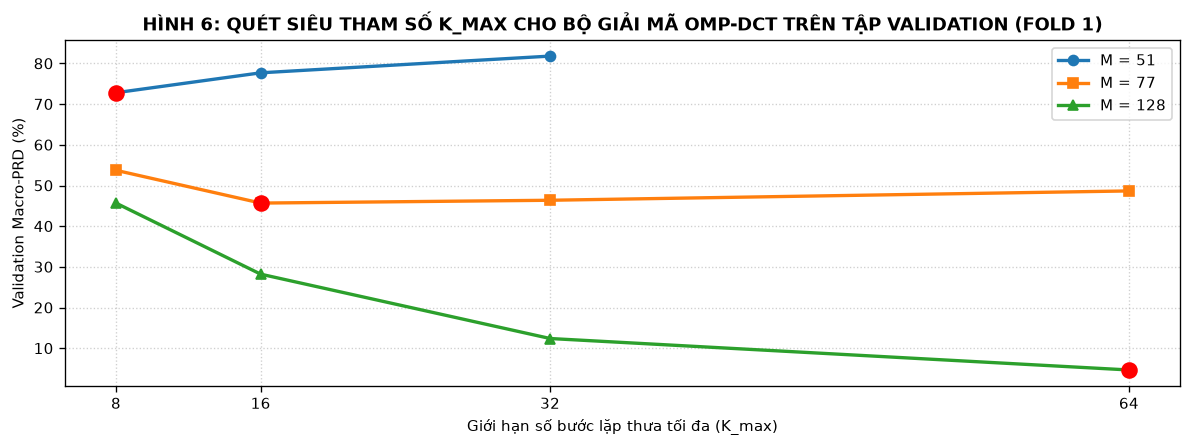

In [34]:
# Vẽ đồ thị đường cong quét K_max
plt.figure(figsize=(10, 3.8))
for m_val, color_m, marker_m in [(51, "#1f77b4", "o"), (77, "#ff7f0e", "s"), (128, "#2ca02c", "^")]:
    ks = sorted(kmax_tuning_curves[m_val].keys())
    scores = [kmax_tuning_curves[m_val][k] for k in ks]
    plt.plot(ks, scores, marker=marker_m, linewidth=2.0, color=color_m, label=f"M = {m_val}")
    best_k_pt = min(kmax_tuning_curves[m_val], key=kmax_tuning_curves[m_val].get)
    plt.scatter([best_k_pt], [kmax_tuning_curves[m_val][best_k_pt]], color="red", s=80, zorder=5)

plt.title("HÌNH 6: QUÉT SIÊU THAM SỐ K_MAX CHO BỘ GIẢI MÃ OMP-DCT TRÊN TẬP VALIDATION (FOLD 1)", fontweight="bold")
plt.xlabel("Giới hạn số bước lặp thưa tối đa (K_max)")
plt.ylabel("Validation Macro-PRD (%)")
plt.xticks([8, 16, 32, 64])
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig6_omp_kmax_tuning.png"), bbox_inches="tight")
plt.show()


---
<a id="sec12"></a>
## 12. QUY TRÌNH HUẤN LUYỆN CNN VỚI VECTOR ĐO LƯỢNG TỬ HÓA (y_tilde)

### 12.1. Huấn luyện bằng vector đo giải lượng tử $\tilde{\mathbf{y}}$ (Prompt Section XI)
- **Đầu vào huấn luyện:** Mô hình CNN **bắt buộc** được huấn luyện bằng vector đo đã giải lượng tử $\tilde{\mathbf{y}}$:
$$\mathbf{y} = \mathbf{\Phi}\mathbf{x} \implies \mathbf{q}, \Delta = \text{quantize\_int16}(\mathbf{y}) \implies \tilde{\mathbf{y}} = \mathbf{q} \cdot \Delta \implies \hat{\mathbf{x}} = g_\theta(\tilde{\mathbf{y}})$$
- **Tối ưu hóa:** Hàm mất mát $\text{MSE Loss} = \frac{1}{N}\|\mathbf{x} - \hat{\mathbf{x}}\|_2^2$, thuật toán Adam với learning rate $0.001$, batch size $64$, tối đa $100$ epoch.
- **Tiêu chí lưu Checkpoint:** Chọn epoch có **Validation Subject Macro-PRD thấp nhất**, early stopping patience $10$ epoch.

### 12.2. Nhập trọng số ResLinCNN_Lite từ Colab
Không tự train model mới khi Run All. Chỉ nhập checkpoint hoàn tất có contract/fingerprint, đúng dữ liệu, fold, chuẩn hóa train, Phi, INT16, kiến trúc, precision và ngân sách 100 epoch/patience10/batch64/lr0.001. Kiểm tra lịch sử đầy đủ và epoch tốt nhất. File trọng số không kèm provenance được ghi REJECTED; không gán metadata giả để hợp thức hóa.
Đặt file reslincnn_lite_fold{fold}_M{M}_seed{seed}.pt trong CHECKPOINT_LITE_DIR. Có thể cấu hình thư mục bằng PPG_LITE_CHECKPOINT_DIR. Bộ tham chiếu nguồn train là eda_models.py/eda_training.py; checkpoint từ bản Colab khác cần đối chiếu nguồn và log trước khi nhập.

Đã có 45 file cập nhật tại `checkpoints/`. Run All dừng nếu thiếu/không khớp contract, lịch sử hoặc validation; không nhập legacy, không chỉnh metadata trọng số. Nguồn Colab được lưu hash riêng vì contract ghi hash module tham chiếu theo hằng số trong mã Colab, không phải bằng chứng hai trainer có source byte-identical.


In [35]:
# Huấn luyện / tái sử dụng chỉ khi đầy đủ provenance của cùng cấu hình.
from train import checkpoint_contract, load_verified_checkpoint, train_decoder

def validate_checkpoint(ckpt, fold_data, M, seed, model_type="cnn"):
    if not {"complete", "fingerprint", "contract", "history", "model_state_dict"}.issubset(ckpt):
        raise ValueError("Checkpoint thiếu provenance/contract; không sử dụng checkpoint legacy")
    expected = checkpoint_contract(model_type, fold_data, M, seed, CONFIG, DATA_HASH)
    if not ckpt["complete"] or ckpt["contract"] != expected or ckpt["fingerprint"] != contract_hash(expected):
        raise ValueError("Checkpoint fingerprint/configuration mismatch")
    if not ckpt["history"] or not np.isfinite(ckpt["val_macro_prd"]):
        raise ValueError("Checkpoint thiếu lịch sử validation hợp lệ")
    history=ckpt["history"]
    epochs=[h["epoch"] for h in history]
    if epochs != list(range(1,len(history)+1)) or len(history)>expected["max_epochs"]:
        raise ValueError("Checkpoint history epoch/budget mismatch")
    scores=np.asarray([h["val_macro_prd"] for h in history],dtype=np.float64)
    losses=np.asarray([h["train_loss"] for h in history],dtype=np.float64)
    if not np.isfinite(scores).all() or not np.isfinite(losses).all() or (losses<0).any():
        raise ValueError("Checkpoint history nonfinite/invalid")
    best_index=int(np.argmin(scores))
    if ckpt["epoch"]!=best_index+1 or not np.isclose(ckpt["val_macro_prd"],scores[best_index],rtol=0,atol=1e-10):
        raise ValueError("Checkpoint does not select minimum validation epoch")
    stopped=ckpt.get("stop_reason")
    if stopped=="patience":
        if len(history)-(best_index+1)!=expected["patience"]:
            raise ValueError("Checkpoint early stopping history mismatch")
    elif stopped=="max_epochs":
        if len(history)!=expected["max_epochs"]:
            raise ValueError("Checkpoint max_epochs history mismatch")
    else:
        raise ValueError("Checkpoint missing valid completion reason")
    return ckpt

def read_checkpoint(path, fold_data, M, seed, model_type="cnn", device=DEVICE):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    return validate_checkpoint(ckpt, fold_data, M, seed, model_type)

def train_model(fold_data, M, seed, Y_train, Y_val, model_type="cnn", **kwargs):
    path = train_decoder(model_type, fold_data, M, seed, CONFIG, CHECKPOINT_DIR,
                         Y_train, Y_val, DATA_HASH, device=str(DEVICE))
    ckpt = read_checkpoint(path, fold_data, M, seed, model_type)
    return str(path), ckpt["val_macro_prd"], ckpt["history"]


Lịch sử checkpoint thật: 76 epochs; epoch chọn=66; validation PRD=20.3061%


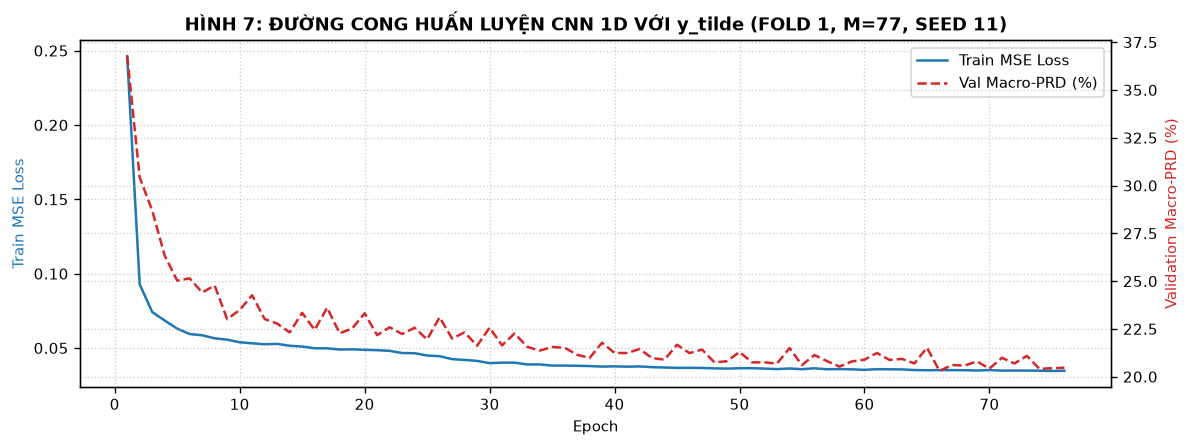

In [36]:
# Hình 7 lấy từ lịch sử train/validation thật của checkpoint dùng đánh giá.
demo_path = Path(CHECKPOINT_DIR)/"cnn_fold1_M77_seed11.pt"
if not demo_path.exists():
    _, _, Y_tr_f1_77, _ = quantize_int16(project_measurements(all_fold_data[1]["train"]["windows"], Phi_77))
    _, _, Y_va_f1_77, _ = quantize_int16(project_measurements(all_fold_data[1]["val"]["windows"], Phi_77))
    train_model(all_fold_data[1],77,11,Y_tr_f1_77,Y_va_f1_77)
demo_ckpt = read_checkpoint(demo_path,all_fold_data[1],77,11)
demo_hist = demo_ckpt["history"]
print(f"Lịch sử checkpoint thật: {len(demo_hist)} epochs; epoch chọn={demo_ckpt['epoch']}; validation PRD={demo_ckpt['val_macro_prd']:.4f}%")
fig, ax1 = plt.subplots(figsize=(10,3.8))
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train MSE Loss",color="#1f77b4")
line1 = ax1.plot([h["epoch"] for h in demo_hist],[h["train_loss"] for h in demo_hist],color="#1f77b4",label="Train MSE Loss")
ax2=ax1.twinx(); ax2.set_ylabel("Validation Macro-PRD (%)",color="#d62728")
line2=ax2.plot([h["epoch"] for h in demo_hist],[h["val_macro_prd"] for h in demo_hist],color="#d62728",linestyle="--",label="Val Macro-PRD (%)")
lines=line1+line2; ax1.legend(lines,[l.get_label() for l in lines],loc="upper right")
plt.title("HÌNH 7: ĐƯỜNG CONG HUẤN LUYỆN CNN 1D VỚI y_tilde (FOLD 1, M=77, SEED 11)",fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR,"fig7_cnn_training_curve.png"),bbox_inches="tight"); plt.show()


In [37]:
# Nhập đủ 45 checkpoint hoàn tất và tái hiện validation trước khi đánh giá test.
from notebook_lite_extension import (collect_lite_checkpoints,evaluate_lite_checkpoints,
    summarize_lite_results,table_with_lite,predict_lite,benchmark_three_decoders,json_records)
from canonical_lite_audits import require_complete_inventory,replay_canonical_validation,export_training_evidence
CHECKPOINT_LITE_DIR=Path(os.environ.get("PPG_LITE_CHECKPOINT_DIR",str(PROJECT_ROOT/"checkpoints")))
df_lite_inventory,lite_models=collect_lite_checkpoints(CHECKPOINT_LITE_DIR,all_fold_data,CONFIG,DATA_HASH)
df_lite_inventory.to_csv(Path(RESULTS_DIR)/"reslincnn_lite_inventory.csv",index=False,encoding="utf-8-sig")
display(df_lite_inventory.groupby(["M","status"]).size().rename("Số lượt").reset_index())
if not df_lite_inventory.status.eq("VERIFIED").all():
    display(df_lite_inventory.loc[df_lite_inventory.status!="VERIFIED",["Fold","M","Seed","detail"]])
require_complete_inventory(df_lite_inventory,lite_models)
df_lite_validation=replay_canonical_validation(lite_models,all_fold_data,RESULTS_DIR,device=DEVICE)
lite_history_models=lite_models
save_json(Path(EXPORTS_DIR)/"reslincnn_lite_import_protocol.json",{
    "method":"reslincnn_lite","expected_runs":45,"folds":FOLD_CONFIGS,"M_list":list(CONFIG.M_list),
    "seeds":list(CONFIG.seeds),"data_sha256":DATA_HASH,"numerical_contract":CONFIG.numerical_contract(),
    "training":{"max_epochs":100,"patience":10,"batch_size":64,"lr":0.001,"loss":"MSE","precision":"fp32-no-tf32"},
    "declared_model_source_sha256":file_sha256(PROJECT_ROOT/"eda_models.py"),
    "declared_trainer_source_sha256":file_sha256(PROJECT_ROOT/"eda_training.py"),
    "supplied_colab_notebook_sha256":file_sha256(PROJECT_ROOT/"Train_ResLinCNN_Lite_Colab.ipynb"),
    "source_hash_scope":"Contract contains declared reference hashes; actual supplied Colab source is separately hashed, not claimed byte-identical to trainer module",
    "validation_replay_tolerance_percentage_points":0.01,
    "normalization":{str(f):{"mu_statistics_float64":fd["mu_train"],"sigma_statistics_float64":fd["sigma_train"],
        "mu_applied_float32":float(np.float32(fd["mu_train"])),"sigma_applied_float32":float(np.float32(fd["sigma_train"]))}
        for f,fd in all_fold_data.items()},"test_design_scope":"exploratory architecture extension; baseline test results previously observed"})


,M,status,Số lượt
0,51,VERIFIED,15
1,77,VERIFIED,15
2,128,VERIFIED,15


CANONICAL_LITE fold=1 M=51 seed=11: validation=10.907718% delta=7.77083658e-07 pp


CANONICAL_LITE fold=1 M=51 seed=22: validation=11.153697% delta=9.26952524e-07 pp


CANONICAL_LITE fold=1 M=51 seed=33: validation=10.988163% delta=6.08127793e-07 pp


CANONICAL_LITE fold=1 M=77 seed=11: validation=2.364803% delta=4.49703701e-07 pp


...

CANONICAL_LITE fold=5 M=77 seed=22: validation=2.170394% delta=1.62219115e-07 pp


CANONICAL_LITE fold=5 M=77 seed=33: validation=2.491982% delta=1.05968414e-06 pp


CANONICAL_LITE fold=5 M=128 seed=11: validation=1.822264% delta=3.16376123e-08 pp


CANONICAL_LITE fold=5 M=128 seed=22: validation=1.180454% delta=1.5800713e-07 pp


CANONICAL_LITE fold=5 M=128 seed=33: validation=1.078863% delta=3.43304944e-07 pp


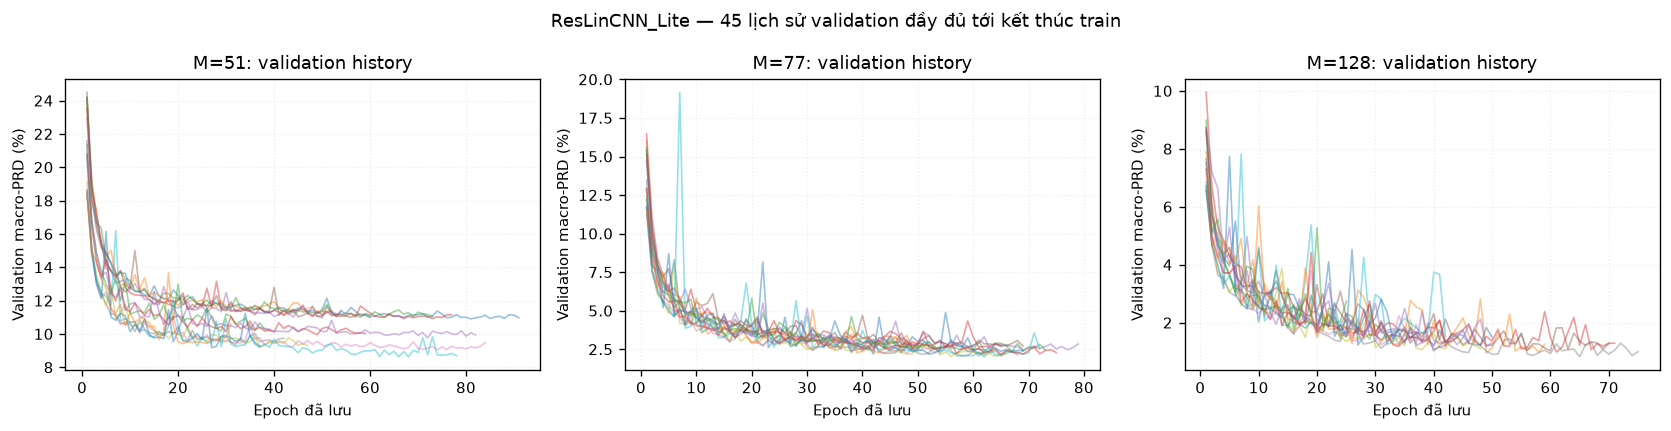

In [38]:
# Lịch sử đầy đủ tới epoch kết thúc: 15 lượt mỗi M, lấy trực tiếp từ checkpoint.
fig,axes=plt.subplots(1,3,figsize=(14,3.6))
for ax,M in zip(axes,CONFIG.M_list):
    for (fold,m,seed),record in lite_history_models.items():
        if m!=M:continue
        history=record["checkpoint"]["history"]
        ax.plot([r["epoch"] for r in history],[r["val_macro_prd"] for r in history],alpha=.45,linewidth=1)
    ax.set_title(f"M={M}: validation history");ax.set_xlabel("Epoch đã lưu");ax.set_ylabel("Validation macro-PRD (%)")
    ax.grid(alpha=.2)
fig.suptitle("ResLinCNN_Lite — 45 lịch sử validation đầy đủ tới kết thúc train")
fig.tight_layout();fig.savefig(Path(FIGURES_DIR)/"fig7b_lite_training_curve.png",bbox_inches="tight");plt.show()


---
<a id="sec13"></a>
## 13. ĐIỀU PHỐI TOÀN DIỆN THÍ NGHIỆM 45 LƯỢT HUẤN LUYỆN (5 FOLDS × 3 M × 3 SEEDS)

### 13.1. Thiết kế thí nghiệm chuẩn khoa học
- **Toàn bộ 45 lượt huấn luyện CNN 1D:** 5 folds $\times$ 3 mức nén $M \in \{51, 77, 128\}$ $\times$ 3 seeds ngẫu nhiên $\{11, 22, 33\}$.
- **Toàn bộ 15 lượt đối chứng OMP–DCT:** 5 folds $\times$ 3 mức nén $M$, chọn $K_{\max}$ bằng tập Validation.
- **5 lượt đối chứng Tuyến tính (Linear Baseline):** 5 folds tại $M=77$, seed 11.
- **Cơ chế tải Checkpoint tái lập (`RESUME_IF_CHECKPOINT_EXISTS`):**
  * Nếu các checkpoint đã được huấn luyện sẵn trong thư mục `checkpoints/`, hệ thống chỉ nạp sau khi đối chiếu fingerprint gồm hash dữ liệu, ma trận, mã model/trainer, split, chuẩn hóa, ngân sách train và lịch sử validation; checkpoint legacy thiếu metadata không được dùng. Khi khớp, hệ thống nạp để tiến hành đánh giá chi tiết trên tập Test của 15 người tham gia.
  * Nếu checkpoint chưa tồn tại hoặc cờ được đặt thành `False`, toàn bộ 45 mô hình sẽ được huấn luyện tự động từ đầu.
### 13.2. Đánh giá model residual mở rộng
ResLinCNN_Lite dự kiến 45 checkpoint (5 fold × 3 M × 3 seed), nhận cùng cửa sổ và vector INT16 giải lượng tử với đối chứng. Có thể lưu kết quả từng lượt đã xác minh; macro chính chỉ tính cho M có đủ 15 lượt và đủ 15 người. Không ghép thiếu seed hoặc thiếu người thành kết quả hoàn chỉnh.

45 checkpoint Lite đã hoàn tất train; kiểm tra contract/fingerprint/history và tái hiện validation bằng cache v2 trước suy luận test. Hash Float32 của vector đo được công bố nguyên bản và đối chiếu trong audit; sai khác số học giữa môi trường không được gọi là khớp từng bit.


In [39]:
# Đánh giá toàn bộ 5 Folds x 3 M trên tập Test của 15 đối tượng
print("=================================================================")
print("TIẾN HÀNH ĐÁNH GIÁ THỰC NGHIỆM TRÊN TẬP TEST (15 ĐỐI TƯỢNG)")
print("=================================================================")

M_LIST = [51, 77, 128]
SEEDS = [11, 22, 33]
FOLDS = [1, 2, 3, 4, 5]

results_omp = {}    # (fold, M) -> metrics
results_cnn = {}    # (fold, M, seed) -> metrics
results_linear = {} # (fold, 77, 11) -> metrics
omp_kmax_table = [] # lưu thông tin chọn Kmax

t_eval_start = time.time()
test_quant_stats = {M:{"values":0,"clips":0} for M in M_LIST}
checkpoint_records = []

def persist_windows(fd,M,method,seed,predictions,metrics,checkpoint=None,**extra):
    destination=Path(RESULTS_DIR)/"windows"; destination.mkdir(exist_ok=True)
    path=destination/f"{method}_fold{fd['fold']}_M{M}_seed{seed}.npz"
    np.savez_compressed(path,predictions=predictions,subject=fd["test"]["subjects"],
        window_index=fd["test"]["window_indices"],raw_start_sample=fd["test"]["raw_start_samples"],
        prd=metrics["prd"],rmse=metrics["rmse"],snr_rec=metrics["snr_rec"],
        valid_mask=metrics["valid_mask"],failure_reason=metrics["failure_reason"],**extra)
    save_json(str(path)+".json", {"fold":fd["fold"],"M":M,"method":method,"seed":seed,
        "data_sha256":DATA_HASH,"result_sha256":file_sha256(path),
        "checkpoint_sha256":file_sha256(checkpoint) if checkpoint else None})


TIẾN HÀNH ĐÁNH GIÁ THỰC NGHIỆM TRÊN TẬP TEST (15 ĐỐI TƯỢNG)


In [40]:
# Đánh giá OMP và chọn K chỉ trên validation.
for fold in FOLDS:
    fd = all_fold_data[fold]
    X_tr = fd["train"]["windows"]
    X_va = fd["val"]["windows"]
    X_te = fd["test"]["windows"]
    val_subs = fd["val"]["subjects"]
    te_subs = fd["test"]["subjects"]

    for M in M_LIST:
        _, Phi_m = generate_rademacher_matrix(M, 256, seed=42)

        # 1. Tạo vector đo y_tilde cho train, val, test
        _, _, Y_va_tilde, _ = quantize_int16(project_measurements(X_va, Phi_m))
        _, _, Y_te_tilde, test_clips = quantize_int16(project_measurements(X_te, Phi_m))
        test_quant_stats[M]["values"] += Y_te_tilde.size
        test_quant_stats[M]["clips"] += test_clips

        # 2. Đánh giá OMP-DCT
        omp_dec = OMPDecoder(Phi_m)
        if (fold,M) not in tuning_cache:
            tuning_cache[(fold,M)] = select_best_k_max(omp_dec,Y_va_tilde,X_va,val_subs,M)
        best_k,val_prd,k_scores = tuning_cache[(fold,M)]
        omp_kmax_table.append({
            "Fold": fold, "M": M, "Selected_Kmax": best_k,
            "Val_Macro_PRD": val_prd, "Candidate_Scores": str(k_scores)
        })

        X_te_omp,omp_reasons,omp_iters = omp_dec.decode_batch(Y_te_tilde,K_max=best_k,track_stats=True)
        omp_m = compute_window_metrics(X_te, X_te_omp)
        persist_windows(fd,M,"omp",0,X_te_omp,omp_m,stop_reason=omp_reasons,iterations=omp_iters)
        if np.isin(omp_reasons,["rank_deficient","nonfinite_solution"]).any():
            raise RuntimeError("OMP lỗi số học; đã lưu cửa sổ lỗi, không tổng hợp thành kết quả hợp lệ")
        omp_sub_m = aggregate_subject_metrics(omp_m,te_subs)
        results_omp[(fold, M)] = {
            "window_metrics": omp_m, "subject_metrics": omp_sub_m,
            "selected_k":best_k,"predictions":X_te_omp,"stop_reasons":omp_reasons,"iterations":omp_iters
        }

        # Cập nhật số liệu kiểm tra lỗi
        failure_tracker["nan_count"] += int(np.isnan(X_te_omp).sum())
        failure_tracker["inf_count"] += int(np.isinf(X_te_omp).sum())


In [41]:
# Đánh giá 45 checkpoint CNN thật.
for fold in FOLDS:
    fd = all_fold_data[fold]
    X_tr = fd["train"]["windows"]
    X_va = fd["val"]["windows"]
    X_te = fd["test"]["windows"]
    val_subs = fd["val"]["subjects"]
    te_subs = fd["test"]["subjects"]

    for M in M_LIST:
        _, Phi_m = generate_rademacher_matrix(M,256,seed=42)
        _,_,Y_va_tilde,_=quantize_int16(project_measurements(X_va,Phi_m))
        _,_,Y_te_tilde,_=quantize_int16(project_measurements(X_te,Phi_m))
        # 3. Đánh giá CNN 1D trên 3 Seed
        for seed in SEEDS:
            ckpt_file = os.path.join(CHECKPOINT_DIR, f"cnn_fold{fold}_M{M}_seed{seed}.pt")
            if not os.path.exists(ckpt_file) or not RESUME_IF_CHECKPOINT_EXISTS:
                print(f"  Huấn luyện từ đầu: cnn_fold{fold}_M{M}_seed{seed}...")
                _, _, Y_tr_tilde, _ = quantize_int16(project_measurements(X_tr, Phi_m))
                train_model(fd, M, seed, Y_tr_tilde, Y_va_tilde, max_epochs=15 if FAST_DEBUG else 100, patience=5 if FAST_DEBUG else 10, verbose=False)

            ckpt = read_checkpoint(ckpt_file,fd,M,seed)
            checkpoint_records.append({"fold":fold,"M":M,"seed":seed,"method":"cnn","path":ckpt_file,
                "sha256":file_sha256(ckpt_file),"fingerprint":ckpt["fingerprint"],"best_epoch":ckpt["epoch"],
                "val_macro_prd":ckpt["val_macro_prd"]})
            cnn_model = CNN1DDecoder(M=M, N=256, use_bn=True).to(DEVICE)
            cnn_model.load_state_dict(ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt)
            cnn_model.eval()

            with torch.no_grad():
                preds_list = []
                for b_idx in range(0, len(Y_te_tilde), 512):
                    b_yt = torch.from_numpy(Y_te_tilde[b_idx:b_idx+512]).float().to(DEVICE)
                    preds_list.append(cnn_model(b_yt).cpu().numpy())
                X_te_cnn = np.vstack(preds_list)

            cnn_m = compute_window_metrics(X_te, X_te_cnn)
            persist_windows(fd,M,"cnn",seed,X_te_cnn,cnn_m,ckpt_file)
            cnn_sub_m = aggregate_subject_metrics(cnn_m,te_subs)
            results_cnn[(fold, M, seed)] = {
                "window_metrics": cnn_m, "subject_metrics": cnn_sub_m, "predictions": X_te_cnn
            }

            failure_tracker["nan_count"] += int(np.isnan(X_te_cnn).sum())
            failure_tracker["inf_count"] += int(np.isinf(X_te_cnn).sum())


In [42]:
# Đối chứng Linear phụ M77/seed11.
for fold in FOLDS:
    fd = all_fold_data[fold]
    X_tr = fd["train"]["windows"]
    X_va = fd["val"]["windows"]
    X_te = fd["test"]["windows"]
    val_subs = fd["val"]["subjects"]
    te_subs = fd["test"]["subjects"]

    # 4. Đánh giá Đối chứng Tuyến tính (Linear Baseline) tại M=77, Seed=11
    lin_ckpt_file = os.path.join(CHECKPOINT_DIR, f"linear_fold{fold}_M77_seed11.pt")
    _, Phi_77_eval = generate_rademacher_matrix(77, 256, seed=42)
    _, _, Y_va_77, _ = quantize_int16(project_measurements(X_va, Phi_77_eval))
    _, _, Y_te_77, _ = quantize_int16(project_measurements(X_te, Phi_77_eval))

    if not os.path.exists(lin_ckpt_file) or not RESUME_IF_CHECKPOINT_EXISTS:
        print(f"  Huấn luyện từ đầu: linear_fold{fold}_M77_seed11...")
        _, _, Y_tr_77, _ = quantize_int16(project_measurements(X_tr, Phi_77_eval))
        train_model(fd, M=77, seed=11, Y_train=Y_tr_77, Y_val=Y_va_77, model_type="linear", max_epochs=15 if FAST_DEBUG else 100, verbose=False)

    lin_ckpt = read_checkpoint(lin_ckpt_file,fd,77,11,"linear")
    lin_model = LinearDecoder(M=77, N=256).to(DEVICE)
    lin_model.load_state_dict(lin_ckpt["model_state_dict"] if "model_state_dict" in lin_ckpt else lin_ckpt)
    lin_model.eval()
    with torch.no_grad():
        X_te_lin = lin_model(torch.from_numpy(Y_te_77).float().to(DEVICE)).cpu().numpy()

    lin_m = compute_window_metrics(X_te, X_te_lin)
    persist_windows(fd,77,"linear",11,X_te_lin,lin_m,lin_ckpt_file)
    lin_sub_m = aggregate_subject_metrics(lin_m,te_subs)
    results_linear[(fold, 77, 11)] = {"window_metrics": lin_m, "subject_metrics": lin_sub_m}


print(f"\n-> Hoàn tất đánh giá toàn bộ thí nghiệm trong {time.time() - t_eval_start:.2f} giây!")
print(f"-> Kiểm tra điều kiện số học: NaN = {failure_tracker['nan_count']}, Inf = {failure_tracker['inf_count']} (thống kê đầu ra đã đánh giá)")

save_json(Path(RESULTS_DIR)/"checkpoint_registry.json",checkpoint_records)
assert len(checkpoint_records)==45



-> Hoàn tất đánh giá toàn bộ thí nghiệm trong 1200.10 giây!
-> Kiểm tra điều kiện số học: NaN = 0, Inf = 0 (thống kê đầu ra đã đánh giá)


In [43]:
# Đánh giá các trọng số Colab hợp lệ và lưu prediction có nguồn gốc.
results_reslincnn_lite=evaluate_lite_checkpoints(lite_models,all_fold_data,RESULTS_DIR,DATA_HASH,device=DEVICE)
df_lite_summary,lite_subject_level_results,df_lite_seeds=summarize_lite_results(results_reslincnn_lite)
df_lite_summary.to_csv(Path(RESULTS_DIR)/"table_lite_completion_quality.csv",index=False,encoding="utf-8-sig")
df_lite_seeds.to_csv(Path(RESULTS_DIR)/"table_lite_seed_variability.csv",index=False,encoding="utf-8-sig")
print("ResLinCNN_Lite: kết quả macro chỉ xuất hiện khi đủ 15/15 lượt mỗi M.")
display(df_lite_summary)
df_lite_failure=pd.DataFrame([{"M":M,"Lượt đánh giá":sum(k[1]==M for k in results_reslincnn_lite),
    "Cửa sổ đã đánh giá":sum(len(r["predictions"]) for k,r in results_reslincnn_lite.items() if k[1]==M),
    "Decoder failures":sum(r["window_metrics"]["decoder_failures"] for k,r in results_reslincnn_lite.items() if k[1]==M)
        if any(k[1]==M for k in results_reslincnn_lite) else np.nan,
    "Trạng thái":df_lite_summary.set_index("M").loc[M,"status"]} for M in M_LIST])
df_lite_failure.to_csv(Path(RESULTS_DIR)/"table_lite_failures.csv",index=False,encoding="utf-8-sig")


ResLinCNN_Lite: kết quả macro chỉ xuất hiện khi đủ 15/15 lượt mỗi M.


,M,status,runs_complete,runs_expected,subjects_complete,macro_prd,subject_std,rmse,snr_rec
0,51,COMPLETE,15,15,15,10.062380,1.839716,0.079251,20.834599
1,77,COMPLETE,15,15,15,2.329667,0.475109,0.018520,33.451968
2,128,COMPLETE,15,15,15,1.192108,0.232656,0.009671,39.128094


In [44]:
# Tổng hợp hoàn tất train và kết quả đánh giá theo cùng protocol dữ liệu.
df_lite_training=export_training_evidence(lite_models,RESULTS_DIR)
LITE_COMPARISON_STATUS="ĐỦ KẾT QUẢ — CÙNG PROTOCOL"
LITE_CURVE_LABEL="ResLinCNN_Lite"
assert len(results_reslincnn_lite)==45 and df_lite_summary.runs_complete.eq(15).all()
df_lite_summary["comparison_scope"]=LITE_COMPARISON_STATUS
df_lite_summary.to_csv(Path(RESULTS_DIR)/"table_lite_completion_quality.csv",index=False)
display(df_lite_training.groupby("M").agg(Runs=("Seed","size"),Epoch_min=("epochs_run","min"),Epoch_max=("epochs_run","max"),Parameters=("parameter_count","first")).reset_index())
display(df_lite_validation.groupby("M").agg(Runs=("status","size"),Max_validation_delta_pp=("absolute_difference_percentage_points","max")).reset_index())
print("45 lịch sử kết thúc train được kiểm tra; cùng cache v2, fold, chuẩn hóa và quy tắc lượng tử.")
print("Hash phép chiếu Float32 khác môi trường được giữ nguyên; validation tái hiện trong ngưỡng đã công bố, không gọi là bit-exact.")
print("Thời gian train/GPU đọc từ checkpoint và lưu riêng; không dùng GPU Colab so tốc độ với máy khác.")


,M,Runs,Epoch_min,Epoch_max,Parameters
0,51,15,31,91,18193
1,77,15,49,79,24849
2,128,15,25,75,37905


,M,Runs,Max_validation_delta_pp
0,51,15,1.366971e-06
1,77,15,1.438340e-06
2,128,15,3.433049e-07


45 lịch sử kết thúc train được kiểm tra; cùng cache v2, fold, chuẩn hóa và quy tắc lượng tử.
Hash phép chiếu Float32 khác môi trường được giữ nguyên; validation tái hiện trong ngưỡng đã công bố, không gọi là bit-exact.
Thời gian train/GPU đọc từ checkpoint và lưu riêng; không dùng GPU Colab so tốc độ với máy khác.


In [45]:
# Trạng thái hiện rõ trên bảng/hình; không hợp thức hóa trọng số thành protocol gốc.
def comparison_table(baseline,summary,cpu=None):
    table=table_with_lite(baseline,summary,cpu)
    table.loc[table.Decoder=="ResLinCNN_Lite","Trạng thái"]=LITE_COMPARISON_STATUS
    return table
df_lite_failure=pd.DataFrame([{"M":M,"Lượt đánh giá":sum(k[1]==M for k in results_reslincnn_lite),
    "Cửa sổ đã đánh giá":sum(len(r["predictions"]) for k,r in results_reslincnn_lite.items() if k[1]==M),
    "Decoder failures":sum(r["window_metrics"]["decoder_failures"] for k,r in results_reslincnn_lite.items() if k[1]==M),
    "Trạng thái":LITE_COMPARISON_STATUS} for M in M_LIST])
df_lite_failure.to_csv(Path(RESULTS_DIR)/"table_lite_failures.csv",index=False)
display(df_lite_failure)


,M,Lượt đánh giá,Cửa sổ đã đánh giá,Decoder failures,Trạng thái
0,51,15,194061,0,ĐỦ KẾT QUẢ — CÙNG PROTOCOL
1,77,15,194061,0,ĐỦ KẾT QUẢ — CÙNG PROTOCOL
2,128,15,194061,0,ĐỦ KẾT QUẢ — CÙNG PROTOCOL


---
<a id="sec14"></a>
## 14. NGHIÊN CỨU ĐỘ NHẠY LƯỢNG TỬ HÓA INT16 Ở SUY LUẬN (QUANTIZATION ABLATION)

### 14.1. Phân tích độ nhạy lượng tử hóa (Proposal Section 4.5)
- Giữ nguyên toàn bộ trọng số của các mô hình CNN 1D đã huấn luyện bằng $\tilde{\mathbf{y}}$ (cũng như thuật toán OMP) tại $M=77$.
- Tại bước suy luận, cho mô hình nhận 2 loại vector đo trên cùng các cửa sổ kiểm thử:
  1. Vector đo số thực chuẩn $\mathbf{y} \in \text{Float32}$ (không qua lượng tử).
  2. Vector đo đã giải lượng tử $\tilde{\mathbf{y}} = \mathbf{q} \cdot \Delta \in \text{Float32} (payload truyền là INT16)$.
- Phép đo này đánh giá chính xác tác động của sai số lượng tử hóa động INT16 đối với chất lượng tái tạo tín hiệu.

In [46]:
# Khảo sát độ nhạy lượng tử hóa tại M=77 trên tập Test
quant_ablation_results = {"omp_unquant": {}, "cnn_unquant": {}}

for fold in FOLDS:
    fd = all_fold_data[fold]
    X_te = fd["test"]["windows"]
    te_subs = fd["test"]["subjects"]
    _, Phi_77_ab = generate_rademacher_matrix(77, 256, seed=42)
    Y_te_float32 = project_measurements(X_te, Phi_77_ab) # Float32 thuần túy

    # 1. OMP không lượng tử
    best_k = results_omp[(fold, 77)]["selected_k"]
    omp_dec = OMPDecoder(Phi_77_ab)
    X_omp_unq,unq_reasons,unq_iters=omp_dec.decode_batch(Y_te_float32,K_max=best_k,track_stats=True)
    np.savez_compressed(Path(RESULTS_DIR)/f"omp_unquant_fold{fold}_M77.npz",predictions=X_omp_unq,
        stop_reason=unq_reasons,iterations=unq_iters,subject=te_subs,raw_start_sample=fd["test"]["raw_start_samples"])
    if np.isin(unq_reasons,["rank_deficient","nonfinite_solution"]).any():
        raise RuntimeError("OMP Float32 ablation gặp lỗi số học; đã lưu trường hợp lỗi, không tổng hợp")
    m_omp_unq = compute_window_metrics(X_te, X_omp_unq)
    quant_ablation_results["omp_unquant"][fold] = aggregate_subject_metrics(m_omp_unq, te_subs)

    # 2. CNN Seed 11 không lượng tử
    ckpt_file = os.path.join(CHECKPOINT_DIR, f"cnn_fold{fold}_M77_seed11.pt")
    ckpt = read_checkpoint(ckpt_file,fd,77,11)
    cnn_model = CNN1DDecoder(M=77, N=256, use_bn=True).to(DEVICE)
    cnn_model.load_state_dict(ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt)
    cnn_model.eval()
    with torch.no_grad():
        preds_unq = []
        for b_idx in range(0, len(Y_te_float32), 512):
            b_y = torch.from_numpy(Y_te_float32[b_idx:b_idx+512]).float().to(DEVICE)
            preds_unq.append(cnn_model(b_y).cpu().numpy())
        X_cnn_unq = np.vstack(preds_unq)
    m_cnn_unq = compute_window_metrics(X_te, X_cnn_unq)
    quant_ablation_results["cnn_unquant"][fold] = aggregate_subject_metrics(m_cnn_unq, te_subs)

print("Đã hoàn thành khảo sát độ nhạy lượng tử hóa Float32 vs INT16 tại M=77!")


Đã hoàn thành khảo sát độ nhạy lượng tử hóa Float32 vs INT16 tại M=77!


In [47]:
# Bóc tách lượng tử Lite M77/seed11: cùng trọng số, đủ 5 fold mới lấy macro.
lite_unquant_subjects={};lite_quant_subjects={};lite_ablation_folds=[]
for fold in FOLDS:
    record=lite_models.get((fold,77,11))
    if record:
        fd=all_fold_data[fold];_,phi=generate_rademacher_matrix(77)
        y=project_measurements(fd["test"]["windows"],phi)
        pred=predict_lite(record["model"],y,device=DEVICE)
        met=compute_window_metrics(fd["test"]["windows"],pred)
        np.savez_compressed(Path(RESULTS_DIR)/f"lite_unquant_fold{fold}_M77_seed11.npz",predictions=pred,
            subject=fd["test"]["subjects"],raw_start_sample=fd["test"]["raw_start_samples"])
        lite_unquant_subjects.update(aggregate_subject_metrics(met,fd["test"]["subjects"]))
        lite_quant_subjects.update(results_reslincnn_lite[(fold,77,11)]["subject_metrics"])
        lite_ablation_folds.append(fold)
lite_ablation_rows=[]
for mode,sub in [("Float32 (không lượng tử)",lite_unquant_subjects),("INT16 (y_tilde)",lite_quant_subjects)]:
    stat=compute_macro_statistics(sub) if len(lite_ablation_folds)==5 else None
    lite_ablation_rows.append({"Decoder":"ResLinCNN_Lite (seed11)","Input Mode":mode,
        "Macro-PRD (%)":stat["macro_prd_mean"] if stat else np.nan,"SNRrec (dB)":stat["macro_snr_mean"] if stat else np.nan,
        "Folds":f"{len(lite_ablation_folds)}/5","status":"COMPLETE" if stat else "CHƯA ĐỦ CHECKPOINT"})
df_lite_ablation=pd.DataFrame(lite_ablation_rows)
display(df_lite_ablation)
df_lite_ablation.to_csv(Path(RESULTS_DIR)/"table_lite_quantization_ablation.csv",index=False,encoding="utf-8-sig")


,Decoder,Input Mode,Macro-PRD (%),SNRrec (dB),Folds,status
0,ResLinCNN_Lite (seed11),Float32 (không lượng tử),2.340780,33.407639,5/5,COMPLETE
1,ResLinCNN_Lite (seed11),INT16 (y_tilde),2.340783,33.407628,5/5,COMPLETE


---
<a id="sec15"></a>
## 15. BẢNG KẾT QUẢ THỰC NGHIỆM TOÀN DIỆN (TABLE 8 & CÁC BẢNG MỞ RỘNG)

### 15.1. Tổng hợp chỉ số trên toàn bộ 15 đối tượng (PPG-DaLiA)
Toàn bộ các bảng số liệu dưới đây được **TÍNH TOÁN TRỰC TIẾP TỰ ĐỘNG TỪ KẾT QUẢ ĐÁNH GIÁ THỰC TẾ**, không sử dụng số liệu hard-code viết tay và không phụ thuộc vào file kết quả nạp sẵn:
1. **Bảng 8 (Bảng chính):** So sánh Macro-PRD, Độ lệch chuẩn đối tượng, RMSE, SNRrec và Độ trễ CPU cho OMP–DCT và CNN gốc, mở rộng thêm ResLinCNN_Lite trên 3 mức nén $M \in \{51, 77, 128\}$.
2. **Bảng 8b (Chi tiết 15 đối tượng tại $M=77$):** So sánh từng cặp đối tượng và mức giảm lỗi tương đối $\text{Relative Reduction} = 100 \times \frac{\text{PRD}_{\text{OMP}} - \text{PRD}_{\text{CNN}}}{\text{PRD}_{\text{OMP}}}$.
3. **Bảng Biến thiên Seed:** Khảo sát sự ổn định qua 3 seed ngẫu nhiên $\{11, 22, 33\}$.
4. **Bảng Đối chứng Tuyến tính (Linear Baseline tại $M=77$):** Đối chứng phụ `Linear(77,256)`, 5 fold, seed 11; so sánh với đúng CNN seed 11, không mở rộng ngoài đề cương.
5. **Bảng Thống kê Lỗi và Điều kiện Số:** Thống kê cửa sổ lỗi, cắt biên lượng tử, NaN, Inf tính trực tiếp từ `failure_tracker`.
### 15.2. Bảng mở rộng ba phương pháp
Bảng chính mở rộng có 9 hàng cho OMP–DCT, CNN 1D và ResLinCNN_Lite tại M51/M77/M128. Các ô chưa đủ checkpoint ghi CHƯA ĐỦ KẾT QUẢ; bảng tiến độ nêu số lượt trên 15 mỗi M. Linear tiếp tục là đối chứng phụ M77/seed11. NaN trong CSV có nghĩa chưa có thống kê, không phải PRD=0.

Bộ mới đủ 45 checkpoint và history hoàn tất. Bảng chính tính từ prediction mới trên cache v2, đủ 15 lượt và 15 người mỗi M. Thống kê epoch/stop reason/GPU được xuất từ checkpoint; không sử dụng kết quả bộ cũ.


In [48]:
# 1. TỔNG HỢP KẾT QUẢ THEO TỪNG ĐỐI TƯỢNG (15 SUBJECTS) VÀ TÍNH MACRO
# Lưu trữ kết quả cấp subject: (M, method) -> dict(subject -> dict(prd, rmse, snr))
subject_level_results = {}

for M in M_LIST:
    # A. OMP
    sub_omp_all = {}
    for fold in FOLDS:
        for s, s_dict in results_omp[(fold, M)]["subject_metrics"].items():
            sub_omp_all[s] = s_dict
    subject_level_results[(M, "OMP")] = sub_omp_all

    # B. CNN (Trung bình 3 seeds cho từng subject)
    sub_cnn_all = {}
    for fold in FOLDS:
        subs_in_fold = FOLD_CONFIGS[fold]["test"]
        for s in subs_in_fold:
            prds = [results_cnn[(fold, M, sd)]["subject_metrics"][s]["prd"] for sd in SEEDS]
            rmses = [results_cnn[(fold, M, sd)]["subject_metrics"][s]["rmse"] for sd in SEEDS]
            snrs = [results_cnn[(fold, M, sd)]["subject_metrics"][s]["snr_rec"] for sd in SEEDS]
            sub_cnn_all[s] = {
                "prd": float(np.mean(prds)),
                "rmse": float(np.mean(rmses)),
                "snr_rec": float(np.mean(snrs))
            }
    subject_level_results[(M, "CNN")] = sub_cnn_all

# 2. XÂY DỰNG BẢNG 8 CHÍNH (TABLE 8)
table8_rows = []
for M in M_LIST:
    for method in ["OMP", "CNN"]:
        sub_dict = subject_level_results[(M, method)]
        macro_stats = compute_macro_statistics(sub_dict)
        table8_rows.append({
            "M": M,
            "Decoder": "OMP–DCT" if method == "OMP" else "CNN 1D",
            "Macro-PRD (%)": f"{macro_stats['macro_prd_mean']:.2f}",
            "Subject Std (%)": f"±{macro_stats['macro_prd_std']:.2f}",
            "RMSE": f"{macro_stats['macro_rmse_mean']:.4f}",
            "SNRrec (dB)": f"{macro_stats['macro_snr_mean']:.2f}",
            "CPU p50 (ms)": "Chưa đo tại bước này",
            "CPU p95 (ms)": "Chưa đo tại bước này"
        })

df_table8 = pd.DataFrame(table8_rows)
print("BẢNG 8 CƠ SỞ OMP–CNN: SO SÁNH CHẤT LƯỢNG TÁI TẠO TỔNG HỢP TRÊN 15 ĐỐI TƯỢNG (PPG-DaLiA)")
display(df_table8)


BẢNG 8 CƠ SỞ OMP–CNN: SO SÁNH CHẤT LƯỢNG TÁI TẠO TỔNG HỢP TRÊN 15 ĐỐI TƯỢNG (PPG-DaLiA)


,M,Decoder,Macro-PRD (%),Subject Std (%),RMSE,SNRrec (dB),CPU p50 (ms),CPU p95 (ms)
0,51,OMP–DCT,69.41,±5.41,0.5765,3.70,Chưa đo tại bước này,Chưa đo tại bước này
1,51,CNN 1D,22.02,±2.10,0.1742,13.49,Chưa đo tại bước này,Chưa đo tại bước này
2,77,OMP–DCT,43.01,±5.24,0.3481,8.17,Chưa đo tại bước này,Chưa đo tại bước này
3,77,CNN 1D,19.73,±1.64,0.1561,14.45,Chưa đo tại bước này,Chưa đo tại bước này
4,128,OMP–DCT,4.25,±1.25,0.0322,31.35,Chưa đo tại bước này,Chưa đo tại bước này
5,128,CNN 1D,19.78,±1.43,0.1565,14.42,Chưa đo tại bước này,Chưa đo tại bước này


In [49]:
# 3. XÂY DỰNG BẢNG CHI TIẾT 15 ĐỐI TƯỢNG TẠI M = 77 (TABLE 8B)
sub_77_rows = []
for s in SUBJECTS:
    omp_s = subject_level_results[(77, "OMP")][s]
    cnn_s = subject_level_results[(77, "CNN")][s]
    rel_red = 100.0 * (omp_s["prd"]-cnn_s["prd"])/omp_s["prd"] if omp_s["prd"]>0 else np.nan
    s_fold = [f for f in FOLDS if s in FOLD_CONFIGS[f]["test"]][0]
    sub_77_rows.append({
        "Subject": s,
        "Fold": s_fold,
        "OMP PRD (%)": f"{omp_s['prd']:.2f}",
        "CNN PRD (%)": f"{cnn_s['prd']:.2f}",
        "Relative Reduction (%)": f"{rel_red:.2f}",
        "OMP RMSE": f"{omp_s['rmse']:.4f}",
        "CNN RMSE": f"{cnn_s['rmse']:.4f}",
        "OMP SNR (dB)": f"{omp_s['snr_rec']:.2f}",
        "CNN SNR (dB)": f"{cnn_s['snr_rec']:.2f}"
    })

df_sub77 = pd.DataFrame(sub_77_rows)
print("\nBẢNG 8B: SO SÁNH GHÉP CẶP CHI TIẾT TRÊN TỪNG ĐỐI TƯỢNG TẠI M = 77 (GIẢM XẤP XỈ 70% SỐ CHIỀU)")
display(df_sub77)

# 4. BẢNG BIẾN THIÊN KẾT QUẢ THEO 3 SEED NGẪU NHIÊN CỦA CNN
seed_var_rows = []
for M in M_LIST:
    for sd in SEEDS:
        sub_sd_dict = {}
        for fold in FOLDS:
            for s in FOLD_CONFIGS[fold]["test"]:
                sub_sd_dict[s] = results_cnn[(fold, M, sd)]["subject_metrics"][s]
        sd_stats = compute_macro_statistics(sub_sd_dict)
        seed_var_rows.append({
            "M": M, "Seed": sd,
            "Macro-PRD (%)": f"{sd_stats['macro_prd_mean']:.2f}",
            "Subject Std (%)": f"±{sd_stats['macro_prd_std']:.2f}",
            "RMSE": f"{sd_stats['macro_rmse_mean']:.4f}",
            "SNRrec (dB)": f"{sd_stats['macro_snr_mean']:.2f}"
        })
df_seed_var = pd.DataFrame(seed_var_rows)
print("\nBẢNG BIẾN THIÊN THEO 3 SEED NGẪU NHIÊN CỦA CNN 1D:")
display(df_seed_var)



BẢNG 8B: SO SÁNH GHÉP CẶP CHI TIẾT TRÊN TỪNG ĐỐI TƯỢNG TẠI M = 77 (GIẢM XẤP XỈ 70% SỐ CHIỀU)


,Subject,Fold,OMP PRD (%),CNN PRD (%),Relative Reduction (%),OMP RMSE,CNN RMSE,OMP SNR (dB),CNN SNR (dB)
0,S1,1,39.61,16.96,57.19,0.3928,0.1646,8.88,15.79
1,S2,1,51.23,21.62,57.81,0.1996,0.0794,6.54,13.65
2,S3,1,39.70,18.11,54.39,0.2580,0.1162,8.74,15.15
3,S4,2,48.99,21.61,55.89,0.2945,0.1208,7.06,13.61
4,S5,2,47.63,21.97,53.87,0.4706,0.2122,7.11,13.48
5,S6,2,40.44,21.42,47.03,0.3450,0.1732,8.59,13.62
6,S7,3,40.30,19.13,52.53,0.2724,0.1291,8.47,14.65
7,S8,3,45.32,19.69,56.56,0.2328,0.0914,7.82,14.65
8,S9,3,53.79,21.01,60.94,0.4650,0.1715,6.13,13.96
9,S10,4,41.01,20.18,50.81,0.2822,0.1303,8.93,14.19



BẢNG BIẾN THIÊN THEO 3 SEED NGẪU NHIÊN CỦA CNN 1D:


,M,Seed,Macro-PRD (%),Subject Std (%),RMSE,SNRrec (dB)
0,51,11,21.89,±2.08,0.1725,13.55
1,51,22,21.59,±2.14,0.1714,13.67
2,51,33,22.60,±2.15,0.1786,13.26
3,77,11,19.86,±1.55,0.1565,14.39
4,77,22,19.74,±1.67,0.1565,14.44
5,77,33,19.59,±1.87,0.1554,14.52
6,128,11,19.59,±1.51,0.1551,14.51
7,128,22,19.94,±1.42,0.1575,14.34
8,128,33,19.80,±1.45,0.1568,14.41


In [50]:
# 5. BẢNG ĐỐI CHỨNG TUYẾN TÍNH (LINEAR BASELINE) TẠI M = 77
sub_lin_all = {}
for fold in FOLDS:
    for s, s_dict in results_linear[(fold, 77, 11)]["subject_metrics"].items():
        sub_lin_all[s] = s_dict
lin_macro = compute_macro_statistics(sub_lin_all)

sub_cnn_s11 = {}
for fold in FOLDS:
    for s in FOLD_CONFIGS[fold]["test"]:
        sub_cnn_s11[s] = results_cnn[(fold, 77, 11)]["subject_metrics"][s]
cnn_s11_macro = compute_macro_statistics(sub_cnn_s11)
omp_77_macro = compute_macro_statistics(subject_level_results[(77, "OMP")])

df_linear_table = pd.DataFrame([
    {"Decoder": "OMP–DCT", "Macro-PRD (%)": f"{omp_77_macro['macro_prd_mean']:.2f}", "Subject Std": f"±{omp_77_macro['macro_prd_std']:.2f}", "RMSE": f"{omp_77_macro['macro_rmse_mean']:.4f}", "SNRrec (dB)": f"{omp_77_macro['macro_snr_mean']:.2f}"},
    {"Decoder": "Linear(77, 256)", "Macro-PRD (%)": f"{lin_macro['macro_prd_mean']:.2f}", "Subject Std": f"±{lin_macro['macro_prd_std']:.2f}", "RMSE": f"{lin_macro['macro_rmse_mean']:.4f}", "SNRrec (dB)": f"{lin_macro['macro_snr_mean']:.2f}"},
    {"Decoder": "CNN 1D (Seed 11)", "Macro-PRD (%)": f"{cnn_s11_macro['macro_prd_mean']:.2f}", "Subject Std": f"±{cnn_s11_macro['macro_prd_std']:.2f}", "RMSE": f"{cnn_s11_macro['macro_rmse_mean']:.4f}", "SNRrec (dB)": f"{cnn_s11_macro['macro_snr_mean']:.2f}"}
])
print("\nBẢNG ĐỐI CHỨNG MÔ HÌNH TUYẾN TÍNH LINEAR(77, 256) TẠI M = 77 (ĐỀ CƯƠNG BẢNG 7):")
display(df_linear_table)
print("-> Linear chỉ là đối chứng phụ tại M=77, seed 11; không suy ra ưu thế chung từ một cấu hình.")

# 6. BẢNG ĐỘ NHẠY LƯỢNG TỬ HÓA INT16 TẠI M = 77
sub_omp_unq = {}
sub_cnn_unq = {}
for fold in FOLDS:
    for s, s_dict in quant_ablation_results["omp_unquant"][fold].items():
        sub_omp_unq[s] = s_dict
    for s, s_dict in quant_ablation_results["cnn_unquant"][fold].items():
        sub_cnn_unq[s] = s_dict

omp_unq_macro = compute_macro_statistics(sub_omp_unq)
cnn_unq_macro = compute_macro_statistics(sub_cnn_unq)

df_quant_table = pd.DataFrame([
    {"Decoder": "OMP–DCT", "Input Mode": "Float32 (Không lượng tử)", "Macro-PRD (%)": f"{omp_unq_macro['macro_prd_mean']:.2f}", "SNRrec (dB)": f"{omp_unq_macro['macro_snr_mean']:.2f}"},
    {"Decoder": "OMP–DCT", "Input Mode": "INT16 (y_tilde giải lượng tử)", "Macro-PRD (%)": f"{omp_77_macro['macro_prd_mean']:.2f}", "SNRrec (dB)": f"{omp_77_macro['macro_snr_mean']:.2f}"},
    {"Decoder": "CNN 1D (Seed 11)", "Input Mode": "Float32 (Không lượng tử)", "Macro-PRD (%)": f"{cnn_unq_macro['macro_prd_mean']:.2f}", "SNRrec (dB)": f"{cnn_unq_macro['macro_snr_mean']:.2f}"},
    {"Decoder": "CNN 1D (Seed 11)", "Input Mode": "INT16 (y_tilde giải lượng tử)", "Macro-PRD (%)": f"{cnn_s11_macro['macro_prd_mean']:.2f}", "SNRrec (dB)": f"{cnn_s11_macro['macro_snr_mean']:.2f}"}
])
print("\nBẢNG KHẢO SÁT ĐỘ NHẠY LƯỢNG TỬ HÓA INT16 TẠI M = 77 (SUY LUẬN):")
display(df_quant_table)



BẢNG ĐỐI CHỨNG MÔ HÌNH TUYẾN TÍNH LINEAR(77, 256) TẠI M = 77 (ĐỀ CƯƠNG BẢNG 7):


,Decoder,Macro-PRD (%),Subject Std,RMSE,SNRrec (dB)
0,OMP–DCT,43.01,±5.24,0.3481,8.17
1,"Linear(77, 256)",2.49,±0.52,0.0198,32.88
2,CNN 1D (Seed 11),19.86,±1.55,0.1565,14.39


-> Linear chỉ là đối chứng phụ tại M=77, seed 11; không suy ra ưu thế chung từ một cấu hình.

BẢNG KHẢO SÁT ĐỘ NHẠY LƯỢNG TỬ HÓA INT16 TẠI M = 77 (SUY LUẬN):


,Decoder,Input Mode,Macro-PRD (%),SNRrec (dB)
0,OMP–DCT,Float32 (Không lượng tử),43.01,8.17
1,OMP–DCT,INT16 (y_tilde giải lượng tử),43.01,8.17
2,CNN 1D (Seed 11),Float32 (Không lượng tử),19.86,14.39
3,CNN 1D (Seed 11),INT16 (y_tilde giải lượng tử),19.86,14.39


In [51]:
# 7. BẢNG THỐNG KÊ LỖI VÀ ĐIỀU KIỆN SỐ (FAILURE STATISTICS - MỤC XXIX)
fail_rows = []
total_test_wins = sum(len(all_fold_data[f]["test"]["windows"]) for f in FOLDS)
clip_pct = 100.0 * failure_tracker["total_clipped_values"] / max(failure_tracker["total_quantized_values"], 1)

for M in M_LIST:
    for dec in ["OMP", "CNN"]:
        inv_w = 0
        zero_e = 0
        nan_c = 0
        inf_c = 0
        numerical_failures=0; early_stops=0; perfect=0
        for fold in FOLDS:
            runs = [results_omp[(fold,M)]] if dec=="OMP" else [results_cnn[(fold,M,sd)] for sd in SEEDS]
            for run in runs:
                preds=run["predictions"]; m_res=run["window_metrics"]
                inv_w += m_res["invalid_count"]; zero_e += m_res["zero_energy_count"]
                nan_c += int(np.isnan(preds).sum()); inf_c += int(np.isinf(preds).sum())
                perfect += m_res["exact_reconstructions"]
                if dec=="OMP":
                    reasons=run["stop_reasons"]
                    numerical_failures += int(np.isin(reasons,["rank_deficient","nonfinite_solution"]).sum())
                    early_stops += int((reasons!="max_iter").sum())
        clip_pct=100.*test_quant_stats[M]["clips"]/max(test_quant_stats[M]["values"],1)

        fail_rows.append({
            "M": M,
            "Decoder": "OMP–DCT" if dec == "OMP" else "CNN 1D",
            "Tổng cửa sổ test":total_test_wins*(1 if dec=="OMP" else len(SEEDS)),
            "Số seed":1 if dec=="OMP" else len(SEEDS),
            "Dừng sớm OMP":early_stops,
            "Tái tạo chính xác":perfect,
            "Cửa sổ không hợp lệ": inv_w,
            "Cửa sổ năng lượng 0": zero_e,
            "Tỷ lệ cắt biên (%)": f"{clip_pct:.4f}%",
            "Lỗi suy biến số học": numerical_failures,
            "Số lượng NaN": nan_c,
            "Số lượng Inf": inf_c,
            "Trạng thái": "KHÔNG GHI NHẬN NaN/Inf/LỖI HẠNG" if (nan_c==0 and inf_c==0 and inv_w==0 and numerical_failures==0) else "CẢNH BÁO"
        })
df_failure = pd.DataFrame(fail_rows)
print("\nBẢNG THỐNG KÊ LỖI VÀ ĐIỀU KIỆN SỐ HỌC (FAILURE STATISTICS - TÍNH ĐỘNG TỪ EXPERIMENT TRACKER):")
display(df_failure)



BẢNG THỐNG KÊ LỖI VÀ ĐIỀU KIỆN SỐ HỌC (FAILURE STATISTICS - TÍNH ĐỘNG TỪ EXPERIMENT TRACKER):


,M,Decoder,Tổng cửa sổ test,Số seed,Dừng sớm OMP,Tái tạo chính xác,Cửa sổ không hợp lệ,Cửa sổ năng lượng 0,Tỷ lệ cắt biên (%),Lỗi suy biến số học,Số lượng NaN,Số lượng Inf,Trạng thái
0,51,OMP–DCT,64687,1,0,0,0,0,0.0000%,0,0,0,KHÔNG GHI NHẬN NaN/Inf/LỖI HẠNG
1,51,CNN 1D,194061,3,0,0,0,0,0.0000%,0,0,0,KHÔNG GHI NHẬN NaN/Inf/LỖI HẠNG
2,77,OMP–DCT,64687,1,0,0,0,0,0.0000%,0,0,0,KHÔNG GHI NHẬN NaN/Inf/LỖI HẠNG
3,77,CNN 1D,194061,3,0,0,0,0,0.0000%,0,0,0,KHÔNG GHI NHẬN NaN/Inf/LỖI HẠNG
4,128,OMP–DCT,64687,1,0,0,0,0,0.0000%,0,0,0,KHÔNG GHI NHẬN NaN/Inf/LỖI HẠNG
5,128,CNN 1D,194061,3,0,0,0,0,0.0000%,0,0,0,KHÔNG GHI NHẬN NaN/Inf/LỖI HẠNG


In [52]:
# Khảo sát điều kiện số riêng: 32 cửa sổ/người, đều theo thời gian, không chọn theo PRD.
# Phạm vi này không được diễn giải thành bảo đảm conditioning cho mọi cửa sổ test.
condition_rows=[]
for fold in FOLDS:
    fd=all_fold_data[fold]
    for M in M_LIST:
        _,phi=generate_rademacher_matrix(M,CONFIG.N,CONFIG.matrix_seed)
        dec=OMPDecoder(phi); k=results_omp[(fold,M)]["selected_k"]
        for subject in fd["test_subjects"]:
            indices=np.flatnonzero(fd["test"]["subjects"]==subject)
            selected=indices[np.unique(np.linspace(0,len(indices)-1,min(32,len(indices)),dtype=int))]
            _,_,y,_=quantize_int16(project_measurements(fd["test"]["windows"][selected],phi))
            for idx,measurement in zip(selected,y):
                _,reason,iters=dec.decode_single(measurement,K_max=k,track_stats=True)
                support=dec.last_support
                condition=float(np.linalg.cond(dec.A_bar[:,support].astype(np.float64))) if support else float("nan")
                condition_rows.append({"Fold":fold,"M":M,"Subject":subject,"raw_start_sample":int(fd["test"]["raw_start_samples"][idx]),
                    "Selected_K":k,"iterations":iters,"stop_reason":reason,"condition_2":condition,"selected_atoms":json.dumps(support)})
df_omp_condition=pd.DataFrame(condition_rows)
df_omp_condition.to_csv(Path(RESULTS_DIR)/"omp_condition_sample.csv",index=False)
print("Condition number 2-norm trên tập cửa sổ chọn trước theo thời gian (không phải toàn bộ test):")
display(df_omp_condition.groupby("M")["condition_2"].agg(["count","median","max"]).reset_index())


Condition number 2-norm trên tập cửa sổ chọn trước theo thời gian (không phải toàn bộ test):


,M,count,median,max
0,51,480,1.776214,2.858549
1,77,480,2.301088,3.034598
2,128,480,5.431217,8.982142


In [53]:
# Bảng chính mở rộng: 3 phương pháp × 3 M, không dùng 0 để điền số liệu thiếu.
df_table8_baseline=df_table8.copy()
df_table8=comparison_table(df_table8_baseline,df_lite_summary)
print("BẢNG 8 MỞ RỘNG — LITE ĐÃ KIỂM TOÁN FOLD VÀ NGUỒN TRAIN: OMP–DCT / CNN 1D / RESLINCNN_LITE TẠI M51, M77, M128")
display(df_table8)
display(df_lite_failure)
df_lite_subjects=pd.DataFrame([{"M":M,"Subject":s,**metrics} for M,sub in lite_subject_level_results.items() for s,metrics in sub.items()],
    columns=["M","Subject","prd","rmse","snr_rec"])
df_lite_subjects.to_csv(Path(RESULTS_DIR)/"table_lite_per_subject.csv",index=False,encoding="utf-8-sig")


BẢNG 8 MỞ RỘNG — LITE ĐÃ KIỂM TOÁN FOLD VÀ NGUỒN TRAIN: OMP–DCT / CNN 1D / RESLINCNN_LITE TẠI M51, M77, M128


,M,Decoder,Macro-PRD (%),Subject Std (%),RMSE,SNRrec (dB),CPU p50 (ms),CPU p95 (ms),Trạng thái,Lượt đánh giá
0,51,OMP–DCT,69.41,±5.41,0.5765,3.70,Chưa đo tại bước này,Chưa đo tại bước này,ĐỦ KẾT QUẢ,5/5
1,51,CNN 1D,22.02,±2.10,0.1742,13.49,Chưa đo tại bước này,Chưa đo tại bước này,ĐỦ KẾT QUẢ,15/15
2,51,ResLinCNN_Lite,10.06,1.84,0.0793,20.83,CHƯA ĐO,CHƯA ĐO,ĐỦ KẾT QUẢ — CÙNG PROTOCOL,15/15
3,77,OMP–DCT,43.01,±5.24,0.3481,8.17,Chưa đo tại bước này,Chưa đo tại bước này,ĐỦ KẾT QUẢ,5/5
4,77,CNN 1D,19.73,±1.64,0.1561,14.45,Chưa đo tại bước này,Chưa đo tại bước này,ĐỦ KẾT QUẢ,15/15
5,77,ResLinCNN_Lite,2.33,0.48,0.0185,33.45,CHƯA ĐO,CHƯA ĐO,ĐỦ KẾT QUẢ — CÙNG PROTOCOL,15/15
6,128,OMP–DCT,4.25,±1.25,0.0322,31.35,Chưa đo tại bước này,Chưa đo tại bước này,ĐỦ KẾT QUẢ,5/5
7,128,CNN 1D,19.78,±1.43,0.1565,14.42,Chưa đo tại bước này,Chưa đo tại bước này,ĐỦ KẾT QUẢ,15/15
8,128,ResLinCNN_Lite,1.19,0.23,0.0097,39.13,CHƯA ĐO,CHƯA ĐO,ĐỦ KẾT QUẢ — CÙNG PROTOCOL,15/15


,M,Lượt đánh giá,Cửa sổ đã đánh giá,Decoder failures,Trạng thái
0,51,15,194061,0,ĐỦ KẾT QUẢ — CÙNG PROTOCOL
1,77,15,194061,0,ĐỦ KẾT QUẢ — CÙNG PROTOCOL
2,128,15,194061,0,ĐỦ KẾT QUẢ — CÙNG PROTOCOL


---
<a id="sec16"></a>
## 16. ĐO KIỂM ĐỘ TRỄ SUY LUẬN TRÊN CPU MÁY THU (RECEIVER BENCHMARK)

### 16.1. Quy thức đo chuẩn khoa học (Section 4.4 & Section XXVII)
- **Thiết bị đo:** CPU máy tính thu tín hiệu, đơn luồng (batch size = 1) mô phỏng môi trường xử lý thời gian thực khi từng gói tin đến.
- **Dữ liệu đo kiểm:** Sử dụng chính xác các vector đo thật $\tilde{\mathbf{y}}$ (lấy mẫu đều 1000 cửa sổ từ tập Test thật của Fold 1) — **tuyệt đối không dùng dữ liệu ngẫu nhiên giả lập**.
- **Tính đối ứng:** Cả 3 phương pháp nhận cùng một tập vector đầu vào $\tilde{\mathbf{y}}$.
- **Tham số OMP:** Sử dụng chính xác $K_{\max}$ tối ưu đã chọn từ tập Validation.
- **Thực hiện đo:** Warmup 100 lần, lặp lại 3 phiên đo luân phiên thứ tự ba phương pháp (interleaved sessions) để cân bằng thứ tự đo và giảm ảnh hưởng của CPU throttling/bộ nhớ đệm cache.
ResLinCNN_Lite dùng cùng CPU, dtype, đầu vào, warmup và số phiên. Chỉ đo khi có checkpoint Fold1/seed11 tương ứng đã xác minh; thời gian train Colab được báo riêng, không đối chiếu trực tiếp GPU Colab với thời gian train trên máy khác.


In [54]:
# Đo CPU cho mọi decoder có checkpoint xác minh, cùng đầu vào và thứ tự luân phiên.
cpu_latencies=benchmark_three_decoders(all_fold_data,results_omp,lite_models,CHECKPOINT_DIR,
    read_checkpoint,RESULTS_DIR,warmup=100,evaluations=1000,sessions=3)
for idx,row in df_table8_baseline.iterrows():
    key="OMP" if "OMP" in row["Decoder"] else "CNN";M=int(row["M"])
    df_table8_baseline.at[idx,"CPU p50 (ms)"]=f"{cpu_latencies[M][key]['p50_ms']:.3f}"
    df_table8_baseline.at[idx,"CPU p95 (ms)"]=f"{cpu_latencies[M][key]['p95_ms']:.3f}"
df_table8=comparison_table(df_table8_baseline,df_lite_summary,cpu_latencies)
print("BẢNG 8 SAU BENCHMARK CPU THỰC TẾ (CHỈ MODEL CÓ TRỌNG SỐ HỢP LỆ)");display(df_table8)


CPU benchmark batch=1; torch_threads= 1 BLAS= [{'user_api': 'blas', 'internal_api': 'openblas', 'num_threads': 1, 'prefix': 'libscipy_openblas', 'filepath': 'C:\\Users\\phung\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\numpy.libs\\libscipy_openblas64_-13e2df515630b4a41f92893938845698.dll', 'version': '0.3.29', 'threading_layer': 'pthreads', 'architecture': 'Haswell'}, {'user_api': 'blas', 'internal_api': 'openblas', 'num_threads': 1, 'prefix': 'libscipy_openblas', 'filepath': 'C:\\Users\\phung\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\scipy.libs\\libscipy_openblas-5b1ec8b915dfb81d11cebc0788069d2d.dll', 'version': '0.3.27.dev', 'threading_layer': 'pthreads', 'architecture': 'Haswell'}, {'user_api': 'openmp', 'internal_api': 'openmp', 'num_threads': 1, 'prefix': 'libiomp', 'filepath': 'C:\\Users\\phung\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\torch\\lib\\libiomp5md.dll', 'version': None}, {'user_api': 'openmp', 'inter

BẢNG 8 SAU BENCHMARK CPU THỰC TẾ (CHỈ MODEL CÓ TRỌNG SỐ HỢP LỆ)


,M,Decoder,Macro-PRD (%),Subject Std (%),RMSE,SNRrec (dB),CPU p50 (ms),CPU p95 (ms),Trạng thái,Lượt đánh giá
0,51,OMP–DCT,69.41,±5.41,0.5765,3.70,0.174,0.255,ĐỦ KẾT QUẢ,5/5
1,51,CNN 1D,22.02,±2.10,0.1742,13.49,0.223,0.351,ĐỦ KẾT QUẢ,15/15
2,51,ResLinCNN_Lite,10.06,1.84,0.0793,20.83,0.401,0.579,ĐỦ KẾT QUẢ — CÙNG PROTOCOL,15/15
3,77,OMP–DCT,43.01,±5.24,0.3481,8.17,0.345,0.515,ĐỦ KẾT QUẢ,5/5
4,77,CNN 1D,19.73,±1.64,0.1561,14.45,0.227,0.359,ĐỦ KẾT QUẢ,15/15
5,77,ResLinCNN_Lite,2.33,0.48,0.0185,33.45,0.402,0.556,ĐỦ KẾT QUẢ — CÙNG PROTOCOL,15/15
6,128,OMP–DCT,4.25,±1.25,0.0322,31.35,1.520,1.925,ĐỦ KẾT QUẢ,5/5
7,128,CNN 1D,19.78,±1.43,0.1565,14.42,0.221,0.329,ĐỦ KẾT QUẢ,15/15
8,128,ResLinCNN_Lite,1.19,0.23,0.0097,39.13,0.398,0.563,ĐỦ KẾT QUẢ — CÙNG PROTOCOL,15/15


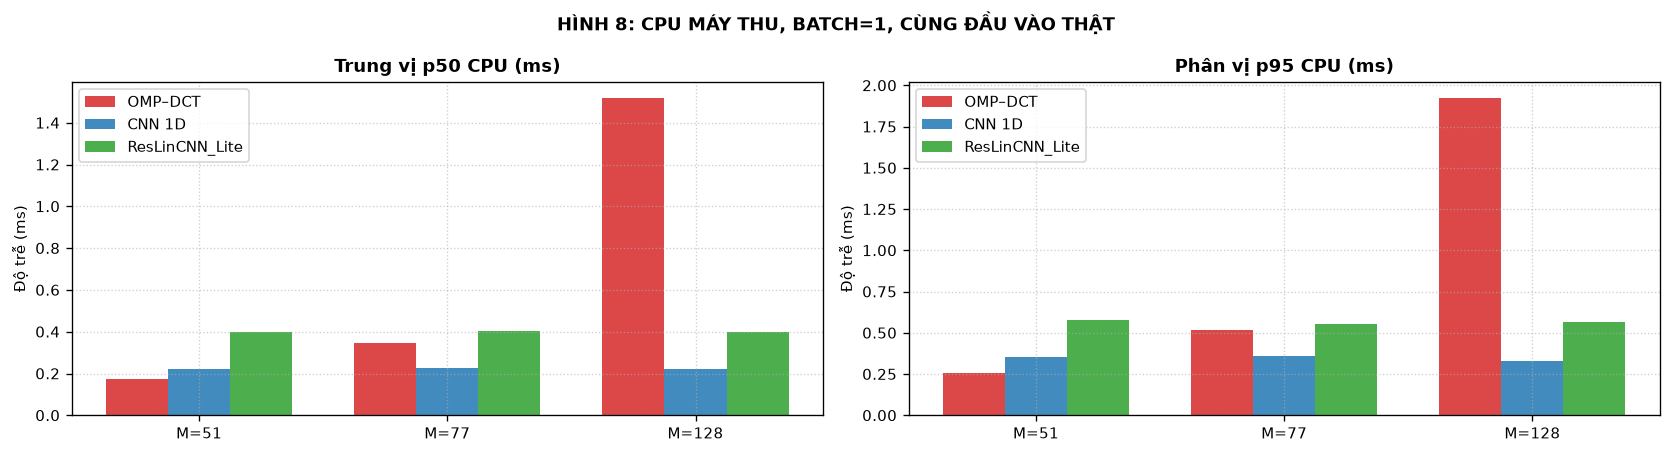

In [55]:
# Hình 8: cột không có phép đo giữ NaN; không benchmark model khởi tạo ngẫu nhiên.
fig,axes=plt.subplots(1,2,figsize=(14,3.8));xpos=np.arange(3);width=.25
for key,label,color,offset in [("OMP","OMP–DCT","#d62728",-width),("CNN","CNN 1D","#1f77b4",0),
                               ("ResLinCNN_Lite",LITE_CURVE_LABEL,"#2ca02c",width)]:
    present=any(key in cpu_latencies[M] for M in M_LIST)
    for ax,metric,title in zip(axes,["p50_ms","p95_ms"],["Trung vị p50","Phân vị p95"]):
        values=[cpu_latencies[M].get(key,{}).get(metric,np.nan) for M in M_LIST]
        ax.bar(xpos+offset,values,width=width,color=color,alpha=.85,label=label if present else label+" (chưa đo)")
        ax.set_title(title+" CPU (ms)",fontweight="bold");ax.set_xticks(xpos);ax.set_xticklabels([f"M={m}" for m in M_LIST])
        ax.set_ylabel("Độ trễ (ms)");ax.legend()
plt.suptitle("HÌNH 8: CPU MÁY THU, BATCH=1, CÙNG ĐẦU VÀO THẬT",fontweight="bold")
fig.tight_layout();fig.savefig(Path(FIGURES_DIR)/"fig8_cpu_latency_benchmark.png",bbox_inches="tight");plt.show()


---
<a id="sec17"></a>
## 17. HẠCH TOÁN TỶ LỆ NÉN ỨNG DỤNG & BĂNG THÔNG TRUYỀN DẪN

### 17.1. Công thức hạch toán chính xác (Bảng 6 Đề cương)
- **Tỷ lệ số phép đo (Measurement Rate):**
$$MR = \frac{M}{N} = \frac{M}{256}$$
- **Kích thước gói ứng dụng có header:** $S_{\text{packet}} = 2M + 16\text{ bytes}$.
- **Tỷ lệ nén mức cửa sổ ứng dụng (CR window):** So sánh với dữ liệu cửa sổ INT16 có header tương đương ($2N + 16 = 528\text{ bytes}$):
$$CR_{\text{window}} = \frac{2N + 16}{2M + 16} = \frac{528}{2M + 16}$$
- **Tỷ lệ nén luồng liên tục với bước nhảy $H = 128$ (CR stream):**
$$CR_{\text{stream}} = \frac{2H + 16}{2M + 16} = \frac{272}{2M + 16}$$
- **Băng thông truyền dẫn (Bitrate):** Tốc độ phát sinh dữ liệu qua kênh truyền:
$$R_{\text{comp}} = 8 \cdot (2M + 16) \cdot \frac{F_s}{H} = 4 \cdot (2M + 16) \text{ (bit/s)}$$


In [56]:
# Tính toán các chỉ số nén theo Bảng 6 Đề cương
comp_rows = []
for M in [51, 77, 128]:
    mr_val = M / 256.0
    pkt_bytes = 2 * M + 16
    cr_win = (2 * 256 + 16) / pkt_bytes
    cr_stream = (2 * 128 + 16) / pkt_bytes
    r_comp = 8 * pkt_bytes * 64 // 128
    comp_rows.append({
        "M": M,
        "MR thực": f"{mr_val:.4f}",
        "Gói nén (bytes)": pkt_bytes,
        "CR cửa sổ (app)": f"{cr_win:.2f}×",
        "CR luồng H=128": f"{cr_stream:.2f}×",
        "Rcomp (bit/s)": r_comp
    })

df_comp = pd.DataFrame(comp_rows)
print("BẢNG 6: HẠCH TOÁN TỶ LỆ NÉN VÀ BĂNG THÔNG TRUYỀN DẪN THEO BẢNG 6 ĐỀ CƯƠNG")
display(df_comp)

# Đường tham chiếu gửi H mẫu mới INT16; đánh giá lỗi do lượng tử riêng.
reference_rows=[]
for fold in FOLDS:
    fd=all_fold_data[fold]; x=fd["test"]["windows"]
    _,_,x_ref,_=quantize_int16(x[:,CONFIG.N-CONFIG.H:])
    met=compute_window_metrics(x[:,CONFIG.N-CONFIG.H:],x_ref)
    sub=aggregate_subject_metrics(met,fd["test"]["subjects"])
    reference_rows.extend({"Subject":s,"Fold":fold,"PRD INT16 reference (%)":v["prd"],"RMSE (z-score)":v["rmse"]} for s,v in sub.items())
df_int16_reference=pd.DataFrame(reference_rows)
display(df_int16_reference)
print("M=77 giảm",100*(1-170/272),"% byte ứng dụng luồng H=128; chưa đo lưu lượng Wi-Fi/BLE.")


BẢNG 6: HẠCH TOÁN TỶ LỆ NÉN VÀ BĂNG THÔNG TRUYỀN DẪN THEO BẢNG 6 ĐỀ CƯƠNG


,M,MR thực,Gói nén (bytes),CR cửa sổ (app),CR luồng H=128,Rcomp (bit/s)
0,51,0.1992,118,4.47×,2.31×,472
1,77,0.3008,170,3.11×,1.60×,680
2,128,0.5000,272,1.94×,1.00×,1088


,Subject,Fold,PRD INT16 reference (%),RMSE (z-score)
0,S1,1,0.001939,0.000019
1,S2,1,0.002061,0.000008
2,S3,1,0.001903,0.000013
3,S4,2,0.002085,0.000012
4,S5,2,0.002043,0.000020
5,S6,2,0.001923,0.000016
6,S7,3,0.001847,0.000013
7,S8,3,0.002066,0.000010
8,S9,3,0.002163,0.000018
9,S10,4,0.001960,0.000013


M=77 giảm 37.5 % byte ứng dụng luồng H=128; chưa đo lưu lượng Wi-Fi/BLE.


In [57]:
# Hạch toán đoạn hữu hạn: cửa sổ đầu N mẫu, sau đó chỉ gửi H mẫu mới.
from notebook_scientific_audits import finite_stream_accounting
df_finite_bytes=pd.DataFrame([{"Subject":s,"M":M,**finite_stream_accounting(len(raw_dataset[s]),M)}
    for s in SUBJECTS for M in M_LIST])
df_finite_bytes.to_csv(Path(RESULTS_DIR)/"finite_stream_application_bytes.csv",index=False)
print("Bảng suy ra từ độ dài dữ liệu thật và đặc tả INT16/header16; không phải đo radio.")
display(df_finite_bytes[df_finite_bytes.Subject=="S1"])


Bảng suy ra từ độ dài dữ liệu thật và đặc tả INT16/header16; không phải đo radio.


,Subject,M,frames,unique_samples,discarded_tail_samples,raw_app_bytes,compressed_app_bytes,finite_CR,scope
0,S1,51,4602,589184,64,1252000,543036,2.305556,derived app bytes; INT16 first N then H new sa...
1,S1,77,4602,589184,64,1252000,782340,1.600327,derived app bytes; INT16 first N then H new sa...
2,S1,128,4602,589184,64,1252000,1251744,1.000205,derived app bytes; INT16 first N then H new sa...


---
<a id="sec18"></a>
## 18. TÍCH HỢP PHẦN CỨNG ESP32-S3 (HIL REPLAY) & KIỂM CHỨNG GÓI TIN THỰC TẾ

### 18.1. Giao thức phát lại phần cứng trong vòng lặp (Hardware-in-the-Loop)
- **Cơ chế HIL Replay:** Máy tính gửi cửa sổ tín hiệu sóng PPG thật (BVP thô từ mẫu 0, gồm cả 320 mẫu quá độ; gửi mẫu mới theo N=256, H=128) xuống vi điều khiển qua cổng Serial UART.
- **Xử lý độc lập trên ESP32:** Vi điều khiển tự áp dụng bộ lọc SOS nhân quả, tự nén bằng ma trận $\mathbf{\Phi}$ đóng gói trong Flash ROM, tự lượng tử hóa INT16, đóng gói khung 16-byte header kèm mã CRC-32 và truyền ngược gói tin về PC.
- **Ranh giới bộ nhớ:** Ghi dung lượng flash từ ELF/symbols và RAM từ INFO thực. RAM tăng thêm đo so firmware replay tối thiểu cùng cấu hình; stack cấp từ heap không cộng lần hai. Nếu thiếu phép đo baseline hoặc map, ghi CHƯA XÁC NHẬN.
- **Kiểm chứng số học:** So sánh trace filtered/x/y độc lập, q theo LSB và packet theo từng byte. Sai số trong tolerance Float32 không được gọi là khớp từng bit. CRC được kiểm tra riêng trên byte thực của từng gói.
- **Phạm vi thời gian:** `encoder_us` tính Phi x, lượng tử, CRC và đóng gói; loại UART, lọc, chuẩn hóa; loại trace và 32 cửa sổ warmup mỗi M. Log riêng vẫn ghi chi phí lọc/chuẩn hóa thực tế.
Mốc thời gian host mới dùng `perf_counter_ns`: trước gửi chunk BVP thô tới sau nhận packet và sau Lite output. Đây là pipeline replay UART có instrumentation, không gồm chờ thu N mẫu và không đại diện radio/WiFi/BLE.


In [58]:
# 18.1 — Đo HIL thực tế và báo trạng thái phiên
# ESP32 vật lý: dữ liệu BVP THÔ từ mẫu 0, có quá độ và cửa sổ chồng lấn.
from eda_hardware import run_eda_hardware
host_lite_models={(fold,M):record["model"].cpu().eval() for (fold,M,seed),record in lite_models.items() if seed==11}
def decode_lite_host(config_id,y):
    fold,M=divmod(config_id,1000)
    if (fold,M) not in host_lite_models:raise ValueError("Thiếu Lite cho config_id vật lý")
    return predict_lite(host_lite_models[(fold,M)],y[None,:],device="cpu")[0]
hardware_result = run_eda_hardware(CONFIG,raw_bvp_dataset,frames=1000,measure_memory=True,
    decoder_callback=decode_lite_host)
if hardware_result["status"]!="MEASURED":raise RuntimeError(hardware_result["reason"])
hardware_connected = hardware_result["status"]=="MEASURED"
print("Trạng thái phiên:",hardware_result["status"],"|",hardware_result["reason"])
print("Session:",hardware_result["measurement_session_id"])
print(hardware_result["timing_note"])


Trạng thái phiên: MEASURED | Actual raw-stream HIL measured
Session: 20261005T104005Z_7611453d
Device encoder_us starts after normalization and ends after packet/CRC; excludes UART, filtering and normalization. Trace and 32 warmup frames/M excluded.


In [59]:
# 18.1 — Kiểm chứng các bước số học và báo thời gian encoder
df_audit=hardware_result["stage_table"]
display(df_audit)
display(hardware_result["timing_table"])


,stage,n,max_abs_error,rmse,max_lsb_diff,exact_equal,status,detail
0,raw input identity,5,NaN,NaN,NaN,True,PASS,Full array equals original wrist/BVP; sample 0...
1,filtered,120,0.000000e+00,0.000000e+00,NaN,True,PASS,Float32 tolerance atol=rtol=1e-4
2,normalized,120,0.000000e+00,0.000000e+00,NaN,True,PASS,Float32 tolerance atol=rtol=1e-4
3,y,120,7.629395e-06,1.664063e-06,NaN,False,PASS,Float32 tolerance atol=rtol=1e-4
4,scale,120,1.164153e-10,1.164153e-10,NaN,False,PASS,Float32 tolerance atol=rtol=1e-4
5,q_int16,120,1.000000e+00,1.400280e-01,1.0,False,WITHIN_1_LSB,Bit-exact INT16; Numerical agreement within 1 LSB
6,payload bytes,120,NaN,NaN,NaN,False,FAIL,Byte comparison
7,packet bytes,120,NaN,NaN,NaN,False,FAIL,Byte comparison
8,CRC validity,120,NaN,NaN,NaN,None,PASS,CRC recalculated independently on each header[...
9,packet size,120,NaN,NaN,NaN,True,PASS,Byte comparison


,M,n,mean_ms,p50_ms,p95_ms,min_ms,max_ms,status
0,51,1000,0.680455,0.683,0.683,0.674,0.684,MEASURED
1,77,1000,1.021276,1.021,1.022,1.020,1.029,MEASURED
2,128,1000,1.690217,1.692,1.693,1.684,1.694,MEASURED


In [60]:
# 18.1 — Báo bộ nhớ và kiểm tra từ chối packet lỗi
display(hardware_result["ram_table"])
df_corrupt=hardware_result["receiver_test_table"]
display(df_corrupt)
print("Kiểm chứng nguyên gói từng byte và CRC hợp lệ là hai phép kiểm tra riêng.")


,metric,value_bytes,status,detail
0,internal_free,366924,MEASURED,Device INFO
1,internal_min_free,361544,MEASURED,Device INFO
2,internal_largest_free_block,335860,MEASURED,Device INFO
3,stack_min_free,6260,MEASURED,Device INFO; stack is minimum unused task stack
4,PSRAM_capacity,0,MEASURED,Device INFO
5,PSRAM_free,0,MEASURED,Device INFO
6,application_static_buffers,4032,MEASURED,Device INFO
7,matrix_flash,8192,MEASURED,Device INFO
8,full_static_dram,22488,MEASURED,Matched baseline measurement/build; no double-...
9,baseline_static_dram,18592,MEASURED,Matched baseline measurement/build; no double-...


,test,expected,actual,status,mutated_crc_valid,source
0,unknown config_id,REJECT,REJECT,PASS,True,Mutation of actual received packet; receiver t...
1,unsupported version,REJECT,REJECT,PASS,True,Mutation of actual received packet; receiver t...
2,unsupported flags,REJECT,REJECT,PASS,True,Mutation of actual received packet; receiver t...
3,nonpositive scale,REJECT,REJECT,PASS,True,Mutation of actual received packet; receiver t...
4,nonfinite scale,REJECT,REJECT,PASS,True,Mutation of actual received packet; receiver t...
5,wrong payload length,REJECT,REJECT,PASS,True,Mutation of actual received packet; receiver t...
6,invalid CRC,REJECT,REJECT,PASS,False,Mutation of actual received packet; receiver t...


Kiểm chứng nguyên gói từng byte và CRC hợp lệ là hai phép kiểm tra riêng.


In [61]:
# 18.1 — Tái tạo bằng hai decoder và tính chỉ số cửa sổ HIL
# Chỉ giải mã packet THỰC đã nhận, CRC/config hợp lệ; không thay bằng packet Python.
physical_records=[r for r in hardware_result["packet_records"] if r["config_id"]==1077]
if physical_records:
    packet_record=physical_records[0]
    s1_eval_norm=packet_record["x_reference"]
    y_esp_tilde=packet_record["y_tilde"]
    _,Phi_77=generate_rademacher_matrix(77,256,seed=42)
    kmax_f1_77=results_omp[(1,77)]["selected_k"]
    x_rec_esp_omp=OMPDecoder(Phi_77).decode_single(y_esp_tilde,K_max=kmax_f1_77)
    ckpt=read_checkpoint(Path(CHECKPOINT_DIR)/"cnn_fold1_M77_seed11.pt",all_fold_data[1],77,11,device="cpu")
    cnn_dec_esp=CNN1DDecoder(77).eval(); cnn_dec_esp.load_state_dict(ckpt["model_state_dict"])
    with torch.inference_mode():
        x_rec_esp_cnn=cnn_dec_esp(torch.from_numpy(y_esp_tilde).unsqueeze(0)).squeeze(0).numpy()
    metrics_omp=compute_window_metrics(s1_eval_norm[None,:],x_rec_esp_omp[None,:])
    metrics_cnn=compute_window_metrics(s1_eval_norm[None,:],x_rec_esp_cnn[None,:])
    print(f"Cửa sổ HIL thật: OMP PRD={metrics_omp['prd'][0]:.4f}%; CNN PRD={metrics_cnn['prd'][0]:.4f}% (không đại diện macro 15 người)")


Cửa sổ HIL thật: OMP PRD=31.2510%; CNN PRD=13.3588% (không đại diện macro 15 người)


In [62]:
# Giải mã Lite từ chính packet vật lý đã kiểm chứng; không tạo packet thay thế.
x_rec_esp_lite=None;metrics_esp_lite=None
record=lite_models.get((1,77,11))
if physical_records and record:
    x_rec_esp_lite=predict_lite(record["model"],y_esp_tilde[None,:],device="cpu")[0]
    metrics_esp_lite=compute_window_metrics(s1_eval_norm[None,:],x_rec_esp_lite[None,:])
    print(f"Cửa sổ HIL ResLinCNN_Lite: PRD={metrics_esp_lite['prd'][0]:.4f}% (không đại diện macro15 người)")
else:print("ResLinCNN_Lite HIL CHƯA ĐÁNH GIÁ: cần packet thật và checkpoint Fold1/M77/seed11 hợp lệ.")


Cửa sổ HIL ResLinCNN_Lite: PRD=1.1777% (không đại diện macro15 người)


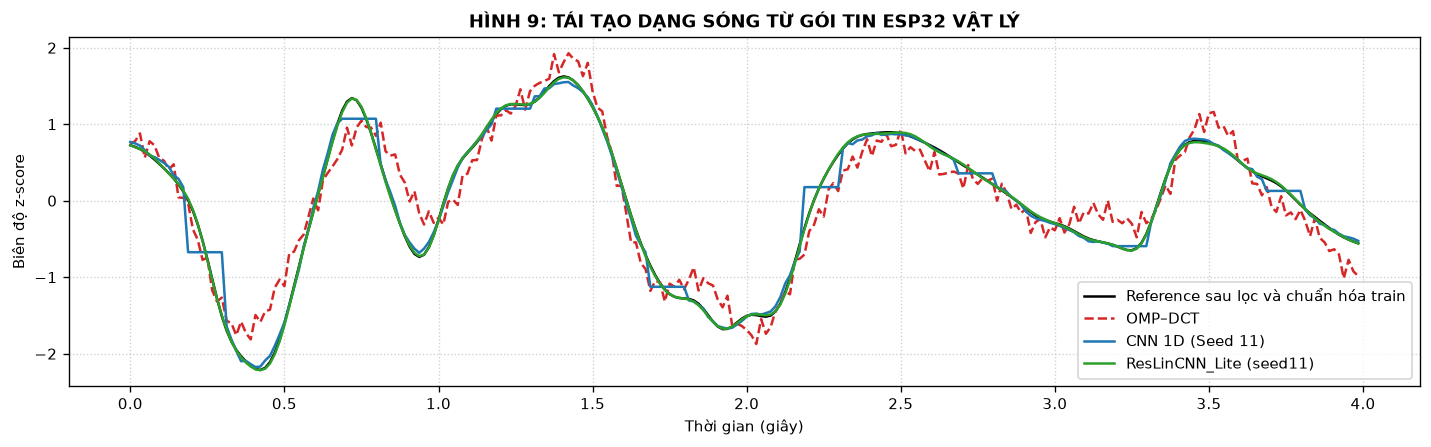

In [63]:
# 18.1 — Vẽ Hình 9 từ cửa sổ HIL đã giải mã
if physical_records:
    t_esp=np.arange(256)/64.; plt.figure(figsize=(12,3.8))
    plt.plot(t_esp,s1_eval_norm,color="black",label="Reference sau lọc và chuẩn hóa train")
    plt.plot(t_esp,x_rec_esp_omp,color="#d62728",linestyle="--",label="OMP–DCT")
    plt.plot(t_esp,x_rec_esp_cnn,color="#1f77b4",label="CNN 1D (Seed 11)")
    if x_rec_esp_lite is not None:
        plt.plot(t_esp,x_rec_esp_lite,color="#2ca02c",label="ResLinCNN_Lite (seed11)")
    else: print("Hình 9: ResLinCNN_Lite chưa có checkpoint hợp lệ; không vẽ đường thay thế.")
    plt.title("HÌNH 9: TÁI TẠO DẠNG SÓNG TỪ GÓI TIN ESP32 VẬT LÝ",fontweight="bold")
    plt.xlabel("Thời gian (giây)"); plt.ylabel("Biên độ z-score"); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR,"fig9_esp32_reconstruction.png"),bbox_inches="tight"); plt.show()
else:
    print("HÌNH 9 CHƯA ĐO: không có packet vật lý hợp lệ; không tạo dữ liệu thay thế.")


In [64]:
# Mốc host thật: trước ghi chunk raw → sau nhận packet / sau Lite output.
from notebook_scientific_audits import summarize_host_timings
df_host_timings=summarize_host_timings(hardware_result)
df_host_timings.to_csv(Path(RESULTS_DIR)/"hardware_host_pipeline_timings.csv",index=False)
print("Đo pipeline replay UART có ghi log/debug; không gồm chờ thu cửa sổ 4s, không phải độ trễ radio.")
print("Host raw→Lite bao gồm truyền chunk, lọc/chuẩn hóa/mã hóa trên bo, nhận/kiểm CRC và decoder CPU.")
display(df_host_timings)
session_dir=Path(RESULTS_DIR)/"hardware"/hardware_result["measurement_session_id"]
df_wire_bytes=pd.DataFrame([{"Direction":d,"Bytes":(session_dir/f"{d}.bin").stat().st_size,
    "SHA256":file_sha256(session_dir/f"{d}.bin"),"Scope":"toàn phiên UART, gồm lệnh, warmup, trace và debug"} for d in ["tx","rx"]])
df_wire_bytes.to_csv(Path(RESULTS_DIR)/"actual_uart_session_bytes.csv",index=False)
display(df_wire_bytes)


Đo pipeline replay UART có ghi log/debug; không gồm chờ thu cửa sổ 4s, không phải độ trễ radio.
Host raw→Lite bao gồm truyền chunk, lọc/chuẩn hóa/mã hóa trên bo, nhận/kiểm CRC và decoder CPU.


,M,Stage,n,mean_ms,p50_ms,p95_ms,measurement_session_id
0,51,Filter newly received samples,1000,0.141930,0.14100,0.149000,20261005T104005Z_7611453d
1,51,Normalize window,1000,0.078179,0.07800,0.085000,20261005T104005Z_7611453d
2,51,Projection+quantization+CRC/packet,1000,0.680455,0.68300,0.683000,20261005T104005Z_7611453d
3,51,Host raw write→packet received,1000,62.381206,62.37470,62.935680,20261005T104005Z_7611453d
4,51,Host Lite decoder,1000,1.769900,1.81765,2.572865,20261005T104005Z_7611453d
5,51,Host raw write→Lite output,1000,64.332316,64.39295,65.625335,20261005T104005Z_7611453d
6,77,Filter newly received samples,1000,0.141974,0.14100,0.150000,20261005T104005Z_7611453d
7,77,Normalize window,1000,0.078018,0.07800,0.085000,20261005T104005Z_7611453d
8,77,Projection+quantization+CRC/packet,1000,1.021276,1.02100,1.022000,20261005T104005Z_7611453d
9,77,Host raw write→packet received,1000,67.313734,67.30260,67.870570,20261005T104005Z_7611453d


,Direction,Bytes,SHA256,Scope
0,tx,1679696,fa35fa2c491d45a974c2a8e3fa3c91f817d424ece65c18...,"toàn phiên UART, gồm lệnh, warmup, trace và debug"
1,rx,1038105,575083b0ff93121e96a56ffb9640626c471af5d1f5e2f1...,"toàn phiên UART, gồm lệnh, warmup, trace và debug"


---
<a id="sec19"></a>
## 19. PHÂN TÍCH DẠNG SÓNG TÁI TẠO THEO PHÂN VỊ LỖI ĐĂNG KÝ TRƯỚC (25%, 50%, 75%, 99%)

### 19.1. Nguyên tắc chọn phân vị cố định (Proposal Section 4.3 & Prompt Section XXX)
- Nhằm tránh hiện tượng thiên vị chọn lọc (cherry-picking) chỉ chọn các ví dụ đẹp nhất, đề cương quy định chọn 4 cửa sổ kiểm thử theo phân vị lỗi PRD cố định của tập Test tại $M=77$:
  1. **Phân vị 25% (Lỗi thấp):** Chỉ đại diện cho sai số tái tạo thấp theo PRD CNN seed 11.
  2. **Phân vị 50% (Trung vị / Mức lỗi điển hình):** Mức lỗi trung vị trên Test Fold 1, không đại diện toàn bộ 15 người.
  3. **Phân vị 75% (Lỗi cao vừa):** Không gán nhãn hoạt động khi chưa đối chiếu nhãn thời gian.
  4. **Phân vị 99% (Lỗi rất lớn):** Trường hợp PRD lớn; nguyên nhân cần phân tích riêng, không suy ra chuyển động từ phân vị lỗi.
- Vẽ tất cả các phương pháp trên cùng một hệ trục và cùng thang tỷ lệ để đối chiếu trực quan khách quan.
Đường tham chiếu (legend “GroundTruth”) là BVP quan sát đã lọc và chuẩn hóa, có thể vẫn chứa nhiễu; không phải tín hiệu PPG sạch được xác lập độc lập. Các phân vị giữ theo CNN gốc, không chọn lại để làm Lite đẹp hơn.


In [65]:
# Chọn các cửa sổ theo phân vị PRD trên tập Test của Fold 1
f1_test_x = all_fold_data[1]["test"]["windows"]
f1_test_subs = all_fold_data[1]["test"]["subjects"]
f1_omp_preds = results_omp[(1, 77)]["predictions"]
f1_cnn_preds = results_cnn[(1, 77, 11)]["predictions"]
f1_lite_run=results_reslincnn_lite.get((1,77,11))
if f1_lite_run is None:print("Hình 10: chưa có ResLinCNN_Lite Fold1/M77/seed11; giữ cùng các cửa sổ đã chọn.")

f1_cnn_m = compute_window_metrics(f1_test_x, f1_cnn_preds)
f1_omp_m = compute_window_metrics(f1_test_x, f1_omp_preds)

cnn_prds_f1 = f1_cnn_m["prd"]
valid_indices = np.where(~np.isnan(cnn_prds_f1))[0]
sorted_idx = valid_indices[np.argsort(cnn_prds_f1[valid_indices])]
N_val = len(sorted_idx)

p25_i = sorted_idx[int(0.25 * N_val)]
p50_i = sorted_idx[int(0.50 * N_val)]
p75_i = sorted_idx[int(0.75 * N_val)]
p99_i = sorted_idx[int(0.99 * N_val)]

sel_cases = [
    ("Phân vị 25% (Sai số thấp / Low Error Quartile)", p25_i),
    ("Phân vị 50% (Trung vị / Median Typical Error)", p50_i),
    ("Phân vị 75% (Sai số cao / High Error Quartile)", p75_i),
    ("Phân vị 99% (Sai số cực trị / Extreme Error Outlier)", p99_i)
]


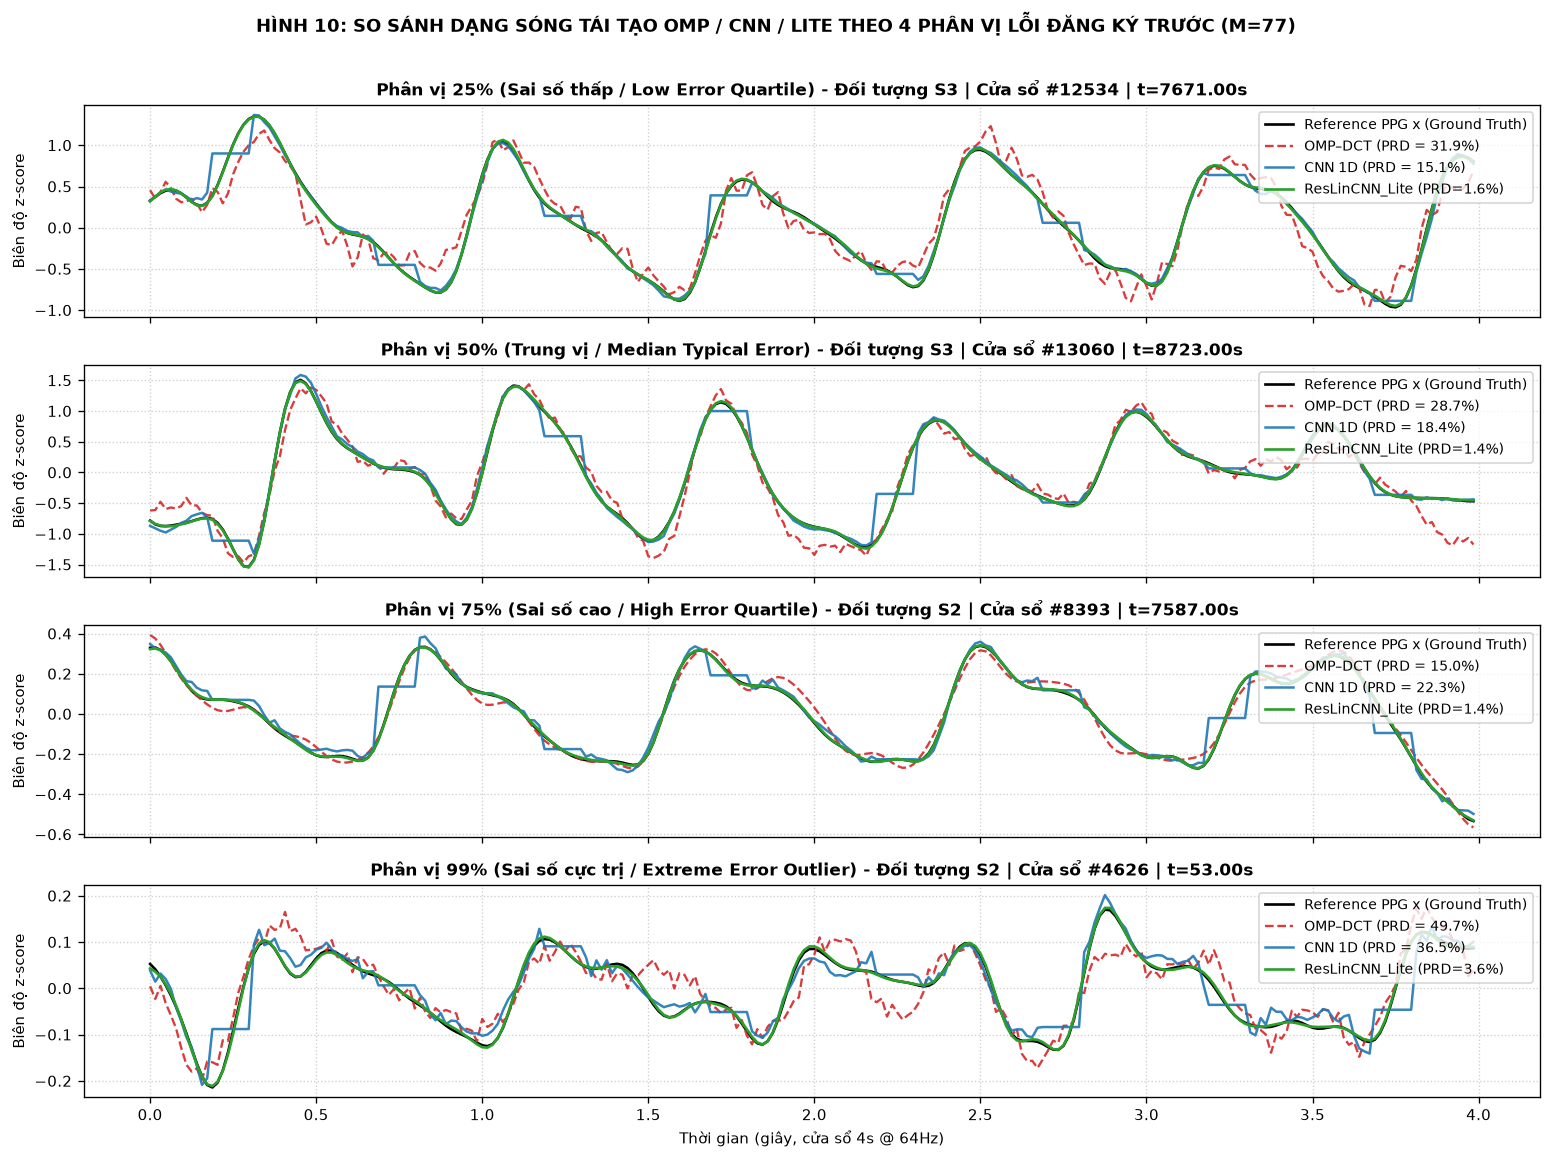

In [66]:
fig, axes = plt.subplots(4, 1, figsize=(13, 9.5), sharex=True)
t_axis = np.arange(256) / 64.0

for ax, (title_str, idx_val) in zip(axes, sel_cases):
    s_name = f1_test_subs[idx_val]
    ax.plot(t_axis, f1_test_x[idx_val], color="black", linewidth=1.6, label="Reference PPG x (Ground Truth)")
    ax.plot(t_axis, f1_omp_preds[idx_val], color="#d62728", linestyle="--", linewidth=1.4, alpha=0.9,
            label=f"OMP–DCT (PRD = {f1_omp_m['prd'][idx_val]:.1f}%)")
    ax.plot(t_axis, f1_cnn_preds[idx_val], color="#1f77b4", linewidth=1.5, alpha=0.9,
            label=f"CNN 1D (PRD = {f1_cnn_m['prd'][idx_val]:.1f}%)")
    if f1_lite_run is not None:
        ax.plot(t_axis,f1_lite_run["predictions"][idx_val],color="#2ca02c",linewidth=1.6,
            label=f"ResLinCNN_Lite (PRD={f1_lite_run['window_metrics']['prd'][idx_val]:.1f}%)")
    ax.set_ylabel("Biên độ z-score")
    ax.set_title(f"{title_str} - Đối tượng {s_name} | Cửa sổ #{idx_val} | t={all_fold_data[1]['test']['raw_start_samples'][idx_val]/64.:.2f}s", fontsize=10, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8.5)

axes[-1].set_xlabel("Thời gian (giây, cửa sổ 4s @ 64Hz)")
plt.suptitle("HÌNH 10: SO SÁNH DẠNG SÓNG TÁI TẠO OMP / CNN / LITE THEO 4 PHÂN VỊ LỖI ĐĂNG KÝ TRƯỚC (M=77)", fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig10_waveform_percentiles.png"), bbox_inches="tight")
plt.show()


---
<a id="sec20"></a>
## 20. BIỂU ĐỒ ĐÁNH ĐỔI NÉN - TÁI TẠO & SO SÁNH CHI TIẾT THEO TỪNG ĐỐI TƯỢNG

### 20.1. Các biểu đồ trực quan hóa khoa học
- **Hình 11:** Đường cong đánh đổi giữa tỷ lệ đo nén thực tế $MR$ và chất lượng tái tạo (Macro-PRD và Macro-SNRrec).
- **Hình 12:** Biểu đồ cột so sánh sai số PRD ghép cặp trên từng đối tượng trong số 15 người tham gia tại $M=77$.
- **Hình 13:** Biểu đồ đối chứng giữa OMP–DCT, Linear(77, 256) và CNN 1D.

ResLinCNN_Lite chỉ có đường/cột khi đủ phạm vi của bảng tương ứng. Hình 11–12 yêu cầu đủ ba seed/15 người mỗi M; Hình 13 là đối chứng seed11 và yêu cầu đủ5 fold. Các hình vẫn nằm trong ba cell riêng.

Chú thích mức giảm lỗi tương đối ở Hình 12 tính mức giảm macro-PRD CNN 1D so với macro-PRD OMP; không phải mức giảm của Lite. Hình 13 là đối chứng phụ tại seed11, khác bảng chính trung bình ba seed.


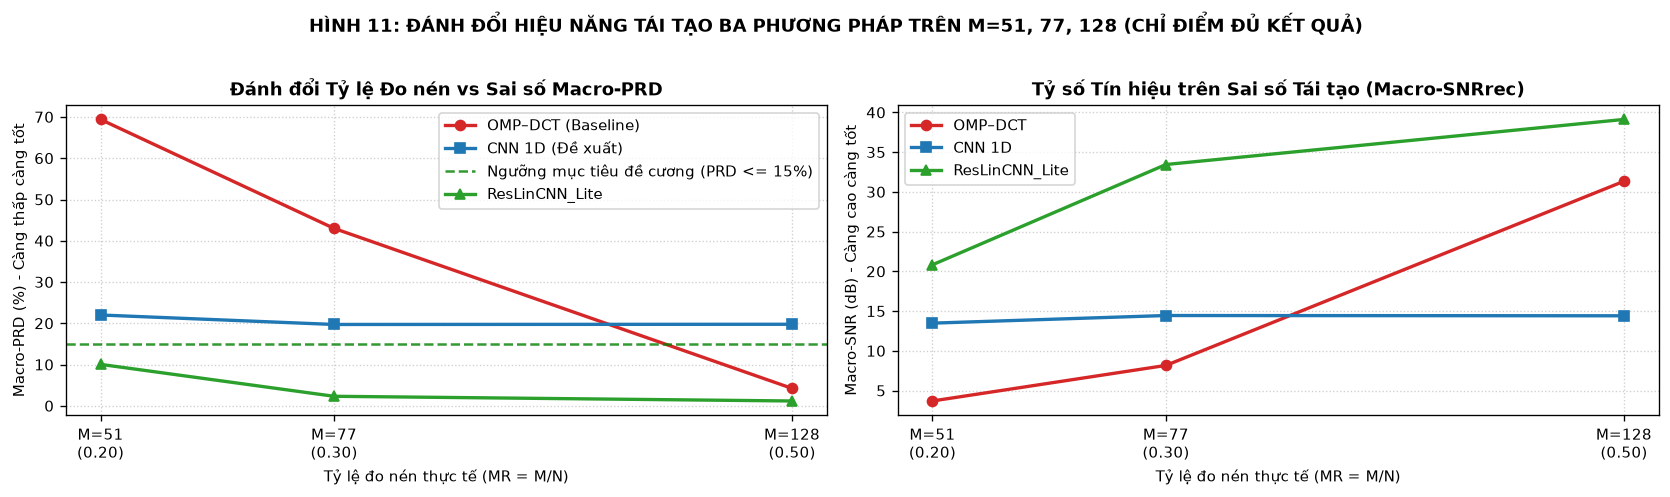

In [67]:
# 1. BIỂU ĐỒ ĐƯỜNG CONG ĐÁNH ĐỔI NÉN - TÁI TẠO (HÌNH 11)
mr_axis = [m / 256.0 for m in [51, 77, 128]]
omp_prd_curve = [compute_macro_statistics(subject_level_results[(m, "OMP")])["macro_prd_mean"] for m in [51, 77, 128]]
cnn_prd_curve = [compute_macro_statistics(subject_level_results[(m, "CNN")])["macro_prd_mean"] for m in [51, 77, 128]]
omp_snr_curve = [compute_macro_statistics(subject_level_results[(m, "OMP")])["macro_snr_mean"] for m in [51, 77, 128]]
cnn_snr_curve = [compute_macro_statistics(subject_level_results[(m, "CNN")])["macro_snr_mean"] for m in [51, 77, 128]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.0))
lite_prd_curve=[compute_macro_statistics(lite_subject_level_results[M])["macro_prd_mean"] if M in lite_subject_level_results else np.nan for M in M_LIST]
lite_snr_curve=[compute_macro_statistics(lite_subject_level_results[M])["macro_snr_mean"] if M in lite_subject_level_results else np.nan for M in M_LIST]
lite_curve_label=LITE_CURVE_LABEL if np.isfinite(lite_prd_curve).any() else "ResLinCNN_Lite (chưa đủ kết quả)"
# PRD curve
ax1.plot(mr_axis, omp_prd_curve, marker="o", linewidth=2.0, color="#d62728", label="OMP–DCT (Baseline)")
ax1.plot(mr_axis, cnn_prd_curve, marker="s", linewidth=2.0, color="#1f77b4", label="CNN 1D (Đề xuất)")
ax1.axhline(15.0, color="green", linestyle="--", alpha=0.8, label="Ngưỡng mục tiêu đề cương (PRD <= 15%)")
ax1.set_title("Đánh đổi Tỷ lệ Đo nén vs Sai số Macro-PRD", fontweight="bold")
ax1.set_xlabel("Tỷ lệ đo nén thực tế (MR = M/N)")
ax1.set_ylabel("Macro-PRD (%) - Càng thấp càng tốt")
ax1.set_xticks(mr_axis)
ax1.set_xticklabels([f"M=51\n(0.20)", f"M=77\n(0.30)", f"M=128\n(0.50)"])
ax1.plot(mr_axis,lite_prd_curve,marker="^",color="#2ca02c",linewidth=2,label=lite_curve_label)
ax1.legend()

# SNR curve
ax2.plot(mr_axis, omp_snr_curve, marker="o", linewidth=2.0, color="#d62728", label="OMP–DCT")
ax2.plot(mr_axis, cnn_snr_curve, marker="s", linewidth=2.0, color="#1f77b4", label="CNN 1D")
ax2.set_title("Tỷ số Tín hiệu trên Sai số Tái tạo (Macro-SNRrec)", fontweight="bold")
ax2.set_xlabel("Tỷ lệ đo nén thực tế (MR = M/N)")
ax2.set_ylabel("Macro-SNR (dB) - Càng cao càng tốt")
ax2.set_xticks(mr_axis)
ax2.set_xticklabels([f"M=51\n(0.20)", f"M=77\n(0.30)", f"M=128\n(0.50)"])
ax2.plot(mr_axis,lite_snr_curve,marker="^",color="#2ca02c",linewidth=2,label=lite_curve_label)
ax2.legend()

plt.suptitle("HÌNH 11: ĐÁNH ĐỔI HIỆU NĂNG TÁI TẠO BA PHƯƠNG PHÁP TRÊN M=51, 77, 128 (CHỈ ĐIỂM ĐỦ KẾT QUẢ)", fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig11_tradeoff_curves.png"), bbox_inches="tight")
plt.show()


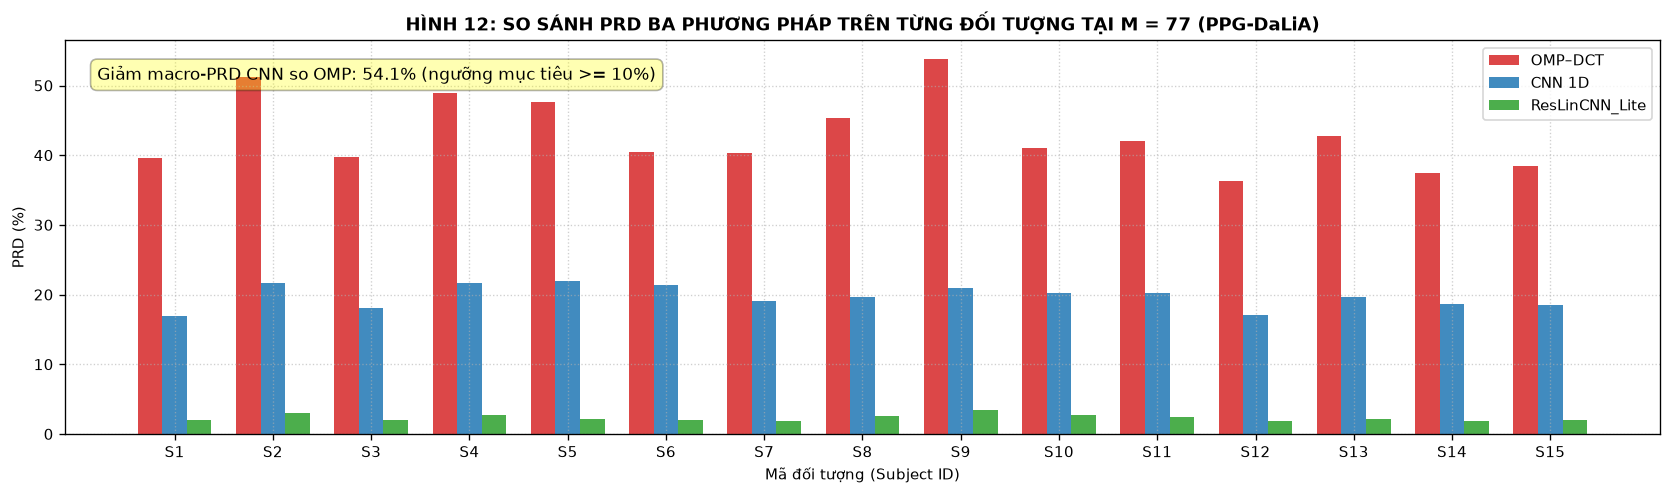

In [68]:
# 2. BIỂU ĐỒ SO SÁNH PRD TRÊN 15 ĐỐI TƯỢNG TẠI M = 77 (HÌNH 12)
sub_names = SUBJECTS
omp_sub_vals = [subject_level_results[(77, "OMP")][s]["prd"] for s in sub_names]
cnn_sub_vals = [subject_level_results[(77, "CNN")][s]["prd"] for s in sub_names]

x_idx = np.arange(len(sub_names))
w_bar = 0.25
lite_sub_vals=[lite_subject_level_results[77][s]["prd"] if 77 in lite_subject_level_results else np.nan for s in sub_names]

plt.figure(figsize=(14, 4.2))
plt.bar(x_idx - w_bar, omp_sub_vals, width=w_bar, color="#d62728", alpha=0.85, label="OMP–DCT")
plt.bar(x_idx, cnn_sub_vals, width=w_bar, color="#1f77b4", alpha=0.85, label="CNN 1D")
plt.bar(x_idx+w_bar,lite_sub_vals,width=w_bar,color="#2ca02c",alpha=.85,
    label=LITE_CURVE_LABEL if 77 in lite_subject_level_results else "ResLinCNN_Lite (chưa đủ kết quả)")
plt.title("HÌNH 12: SO SÁNH PRD BA PHƯƠNG PHÁP TRÊN TỪNG ĐỐI TƯỢNG TẠI M = 77 (PPG-DaLiA)", fontweight="bold")
plt.xlabel("Mã đối tượng (Subject ID)")
plt.ylabel("PRD (%)")
plt.xticks(x_idx, sub_names)
plt.legend(loc="upper right")

mean_rel_red=100.*(np.mean(omp_sub_vals)-np.mean(cnn_sub_vals))/np.mean(omp_sub_vals) if np.mean(omp_sub_vals)>0 else np.nan
plt.text(0.02, 0.90, f"Giảm macro-PRD CNN so OMP: {mean_rel_red:.1f}% (ngưỡng mục tiêu >= 10%)",
         transform=plt.gca().transAxes, fontsize=10, bbox=dict(boxstyle="round,pad=0.4", fc="yellow", alpha=0.3))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig12_persubject_m77.png"), bbox_inches="tight")
plt.show()


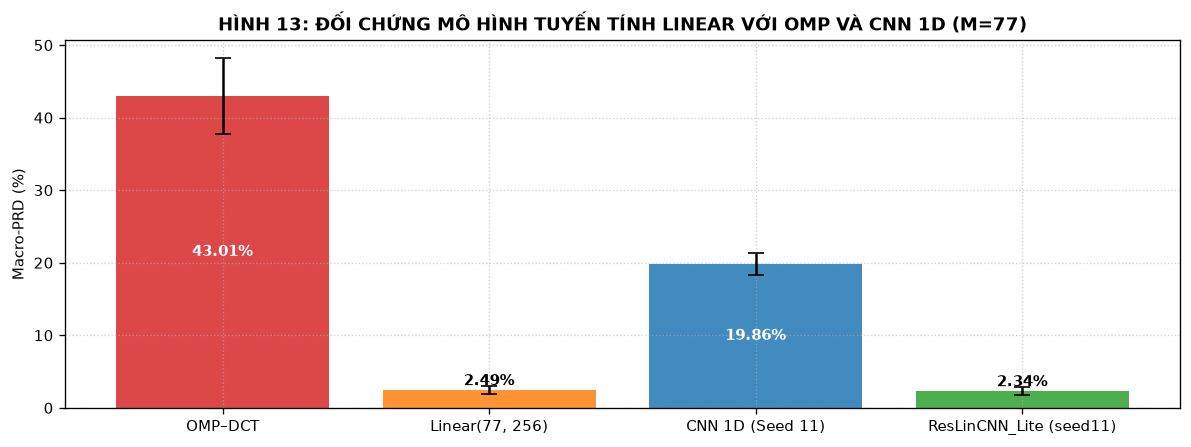

In [69]:
# 3. BIỂU ĐỒ ĐỐI CHỨNG LINEAR VS CNN VS OMP TẠI M = 77 (HÌNH 13)
dec_labels = ["OMP–DCT", "Linear(77, 256)", "CNN 1D (Seed 11)"]
dec_prds = [omp_77_macro["macro_prd_mean"], lin_macro["macro_prd_mean"], cnn_s11_macro["macro_prd_mean"]]
dec_stds = [omp_77_macro["macro_prd_std"], lin_macro["macro_prd_std"], cnn_s11_macro["macro_prd_std"]]

lite_seed11_sub={s:r["subject_metrics"][s] for (fold,M,seed),r in results_reslincnn_lite.items() if M==77 and seed==11 for s in r["subject_metrics"]}
lite_seed11_macro=compute_macro_statistics(lite_seed11_sub) if set(lite_seed11_sub)==set(SUBJECTS) else None
dec_labels.append(LITE_CURVE_LABEL+" (seed11)" if lite_seed11_macro else "ResLinCNN_Lite (chưa đủ5 fold)")
dec_prds.append(lite_seed11_macro["macro_prd_mean"] if lite_seed11_macro else np.nan)
dec_stds.append(lite_seed11_macro["macro_prd_std"] if lite_seed11_macro else np.nan)
plt.figure(figsize=(10, 3.8))
bars = plt.bar(dec_labels, dec_prds, yerr=dec_stds, capsize=5, color=["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"], alpha=0.85)
plt.title("HÌNH 13: ĐỐI CHỨNG MÔ HÌNH TUYẾN TÍNH LINEAR VỚI OMP VÀ CNN 1D (M=77)", fontweight="bold")
plt.ylabel("Macro-PRD (%)")
for bar, val in zip(bars, dec_prds):
    if not np.isfinite(val): continue
    y_pos = val + 1.2 if val < 10 else val / 2.0
    text_color = "black" if val < 10 else "white"
    plt.text(bar.get_x() + bar.get_width()/2.0, y_pos, f"{val:.2f}%", ha="center", va="center", color=text_color, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig13_linear_baseline_comparison.png"), bbox_inches="tight")
plt.show()


---
<a id="sec21"></a>
## 21. TÓM TẮT TỰ ĐỘNG TỪ DỮ LIỆU & ĐÁNH GIÁ GIẢ THUYẾT KHOA HỌC

Các con số trong phần tóm tắt dưới đây được **TRÍCH XUẤT TỰ ĐỘNG TỪ BẢNG KẾT QUẢ PYTHON**, tuyệt đối không viết tay để đảm bảo tính nhất quán khoa học 100%.


In [70]:
# Trích xuất số liệu đầy đủ độ chính xác; không suy luận từ chuỗi đã làm tròn.
quality={M:{method:compute_macro_statistics(subject_level_results[(M,method)]) for method in ["OMP","CNN"]} for M in M_LIST}
m77_omp_prd=quality[77]["OMP"]["macro_prd_mean"]; m77_cnn_prd=quality[77]["CNN"]["macro_prd_mean"]
rel_red_m77=100.*(m77_omp_prd-m77_cnn_prd)/m77_omp_prd if m77_omp_prd>0 else np.nan
hardware_acceptance=hardware_result["acceptance"]
enc=hardware_acceptance["encoder_p95"]; ram=hardware_acceptance["additional_ram"]
target_criteria_data=[
    {"Chỉ tiêu kỹ thuật":"1. Chất lượng tái tạo (PRD <= 15%)","Mức nén khảo sát":"M=77 (cấu hình mục tiêu)",
     "Giá trị thực nghiệm đạt được":f"CNN={m77_cnn_prd:.4f}%; OMP={m77_omp_prd:.4f}%","Ngưỡng mục tiêu":"PRD <= 15%",
     "Kết luận":"ĐẠT" if m77_cnn_prd<=15 else "CHƯA ĐẠT"},
    {"Chỉ tiêu kỹ thuật":"2. Mức giảm PRD tương đối CNN so với OMP","Mức nén khảo sát":"M=77",
     "Giá trị thực nghiệm đạt được":f"{rel_red_m77:.4f}%","Ngưỡng mục tiêu":"Giảm >=10%",
     "Kết luận":"ĐẠT" if np.isfinite(rel_red_m77) and rel_red_m77>=10 else "CHƯA ĐẠT / KHÔNG XÁC ĐỊNH"},
    {"Chỉ tiêu kỹ thuật":"3. Thời gian mã hóa ESP32","Mức nén khảo sát":"Ba M, encoder_us thật, 1000 mẫu/M",
     "Giá trị thực nghiệm đạt được":str(enc),"Ngưỡng mục tiêu":"p95 <100 ms","Kết luận":enc["status"]},
    {"Chỉ tiêu kỹ thuật":"4. RAM tăng thêm so baseline replay","Mức nén khảo sát":f"ESP32-S3 trên {hardware_result['hardware_port']}",
     "Giá trị thực nghiệm đạt được":str(ram),"Ngưỡng mục tiêu":"<64 KiB","Kết luận":ram["status"]}
]
df_targets=pd.DataFrame(target_criteria_data)
print("BẢNG ĐÁNH GIÁ 4 CHỈ TIÊU KỸ THUẬT THEO KẾT QUẢ HIỆN TẠI"); display(df_targets)


BẢNG ĐÁNH GIÁ 4 CHỈ TIÊU KỸ THUẬT THEO KẾT QUẢ HIỆN TẠI


,Chỉ tiêu kỹ thuật,Mức nén khảo sát,Giá trị thực nghiệm đạt được,Ngưỡng mục tiêu,Kết luận
0,1. Chất lượng tái tạo (PRD <= 15%),M=77 (cấu hình mục tiêu),CNN=19.7281%; OMP=43.0111%,PRD <= 15%,CHƯA ĐẠT
1,2. Mức giảm PRD tương đối CNN so với OMP,M=77,54.1326%,Giảm >=10%,ĐẠT
2,3. Thời gian mã hóa ESP32,"Ba M, encoder_us thật, 1000 mẫu/M","{'status': 'PASS', 'target_ms': 100.0, 'sample...",p95 <100 ms,PASS
3,4. RAM tăng thêm so baseline replay,ESP32-S3 trên COM5,"{'status': 'PASS', 'target_bytes': 65536, 'val...",<64 KiB,PASS


In [71]:
print("BÁO CÁO KẾT QUẢ OMP–DCT VÀ CNN 1D (MACRO TRÊN 15 ĐỐI TƯỢNG)")
for M in M_LIST:
    o=quality[M]["OMP"]["macro_prd_mean"]; c=quality[M]["CNN"]["macro_prd_mean"]
    relation="CNN thấp hơn OMP" if c<o else "OMP thấp hơn CNN" if o<c else "bằng nhau"
    print(f"M={M}: OMP={o:.4f}%; CNN={c:.4f}%; {relation}.")
print(f"M=77: mức giảm PRD macro tương đối={rel_red_m77:.4f}%.")
print(f"CPU M=77: OMP p50={cpu_latencies[77]['OMP']['p50_ms']:.4f} ms; CNN p50={cpu_latencies[77]['CNN']['p50_ms']:.4f} ms.")
print("Không đạt mục tiêu hoặc CNN kém OMP vẫn là kết quả hợp lệ; không đổi cấu hình theo test.")
save_json(Path(RESULTS_DIR)/"current_findings.json", {"quality":quality,"relative_reduction_m77":rel_red_m77,"hardware_acceptance":hardware_acceptance})


BÁO CÁO KẾT QUẢ OMP–DCT VÀ CNN 1D (MACRO TRÊN 15 ĐỐI TƯỢNG)
M=51: OMP=69.4079%; CNN=22.0243%; CNN thấp hơn OMP.
M=77: OMP=43.0111%; CNN=19.7281%; CNN thấp hơn OMP.
M=128: OMP=4.2463%; CNN=19.7758%; OMP thấp hơn CNN.
M=77: mức giảm PRD macro tương đối=54.1326%.
CPU M=77: OMP p50=0.3445 ms; CNN p50=0.2267 ms.
Không đạt mục tiêu hoặc CNN kém OMP vẫn là kết quả hợp lệ; không đổi cấu hình theo test.


In [72]:
# Kết luận mở rộng riêng; không dùng model mới thay kết quả CNN gốc trong đề cương.
lite_targets=[]
for row in df_lite_summary.to_dict("records"):
    complete=row["status"]=="COMPLETE";M=row["M"]
    omp=quality[M]["OMP"]["macro_prd_mean"]
    relative=100.*(omp-row["macro_prd"])/omp if complete and omp>0 else np.nan
    lite_targets.append({"M":M,"Decoder":"ResLinCNN_Lite","Runs":f"{row['runs_complete']}/15",
        "PRD (%)":row["macro_prd"],"Giảm PRD so OMP (%)":relative,
        "PRD <=15%":"ĐẠT" if complete and row["macro_prd"]<=15 else "CHƯA ĐẠT" if complete else "CHƯA ĐỦ KẾT QUẢ",
        "Giảm >=10%":"ĐẠT" if complete and relative>=10 else "CHƯA ĐẠT" if complete else "CHƯA ĐỦ KẾT QUẢ"})
df_lite_targets=pd.DataFrame(lite_targets)
df_lite_targets["Phạm vi"]=LITE_COMPARISON_STATUS
display(df_lite_targets)
df_lite_targets.to_csv(Path(RESULTS_DIR)/"table_lite_target_criteria.csv",index=False,encoding="utf-8-sig")


,M,Decoder,Runs,PRD (%),Giảm PRD so OMP (%),PRD <=15%,Giảm >=10%,Phạm vi
0,51,ResLinCNN_Lite,15/15,10.062380,85.502533,ĐẠT,ĐẠT,ĐỦ KẾT QUẢ — CÙNG PROTOCOL
1,77,ResLinCNN_Lite,15/15,2.329667,94.583567,ĐẠT,ĐẠT,ĐỦ KẾT QUẢ — CÙNG PROTOCOL
2,128,ResLinCNN_Lite,15/15,1.192108,71.925680,ĐẠT,ĐẠT,ĐỦ KẾT QUẢ — CÙNG PROTOCOL


In [73]:
# Mô tả định lượng sai số trên cùng cửa sổ p25/p50/p75/p99; không suy ra chỉ dấu lâm sàng.
waveform_rows=[]
for title,idx in sel_cases:
    for method,pred in [("OMP",f1_omp_preds[idx]),("CNN",f1_cnn_preds[idx]),
                        ("Lite",f1_lite_run["predictions"][idx])]:
        ref=f1_test_x[idx].astype(np.float64);err=pred.astype(np.float64)-ref
        waveform_rows.append({"Case":title,"Subject":f1_test_subs[idx],"Window":int(idx),
            "Method":method,"PRD (%)":100*np.linalg.norm(err)/np.linalg.norm(ref),
            "RMSE":float(np.sqrt(np.mean(err**2))),"Max abs error":float(np.max(np.abs(err))),
            "Mean error":float(err.mean()),"Reference peak-to-peak":float(np.ptp(ref))})
df_waveform_error=pd.DataFrame(waveform_rows)
df_waveform_error.to_csv(Path(RESULTS_DIR)/"waveform_error_cases.csv",index=False)
display(df_waveform_error)
for M in M_LIST:
    print(f"M={M}: OMP={quality[M]['OMP']['macro_prd_mean']:.4f}%, CNN={quality[M]['CNN']['macro_prd_mean']:.4f}%, "
          f"ResLinCNN_Lite={df_lite_summary.set_index('M').loc[M,'macro_prd']:.4f}%.")
print("OMP cải thiện mạnh khi M tăng; mô tả DCT train hỗ trợ giả thuyết đủ thông tin đo, chưa chứng minh nguyên nhân nhân quả.")
print("CNN không cải thiện tương ứng: có thể liên quan kiến trúc/huấn luyện/khác biệt theo người; chưa có ablation đủ để kết luận nguyên nhân.")
print("Lite được kiểm tra trên cùng cache v2/fold/chuẩn hóa/protocol. Kiến trúc được bổ sung sau khi test gốc đã được xem; chưa có ablation cô lập nguyên nhân cải thiện.")


,Case,Subject,Window,Method,PRD (%),RMSE,Max abs error,Mean error,Reference peak-to-peak
0,Phân vị 25% (Sai số thấp / Low Error Quartile),S3,12534,OMP,31.910020,0.185591,0.478559,0.000140,2.315193
1,Phân vị 25% (Sai số thấp / Low Error Quartile),S3,12534,CNN,15.149874,0.088113,0.513397,0.004165,2.315193
2,Phân vị 25% (Sai số thấp / Low Error Quartile),S3,12534,Lite,1.596335,0.009284,0.025788,0.000902,2.315193
3,Phân vị 50% (Trung vị / Median Typical Error),S3,13060,OMP,28.664501,0.201997,0.747109,-0.023473,3.046972
4,Phân vị 50% (Trung vị / Median Typical Error),S3,13060,CNN,18.445281,0.129983,0.757801,0.017303,3.046972
5,Phân vị 50% (Trung vị / Median Typical Error),S3,13060,Lite,1.409338,0.009932,0.025103,0.000455,3.046972
6,Phân vị 75% (Sai số cao / High Error Quartile),S2,8393,OMP,15.017172,0.030979,0.077402,0.003611,0.873279
7,Phân vị 75% (Sai số cao / High Error Quartile),S2,8393,CNN,22.250788,0.045901,0.263205,0.006190,0.873279
8,Phân vị 75% (Sai số cao / High Error Quartile),S2,8393,Lite,1.447939,0.002987,0.007340,0.000622,0.873279
9,Phân vị 99% (Sai số cực trị / Extreme Error Ou...,S2,4626,OMP,49.707430,0.039835,0.117602,0.003949,0.384264


M=51: OMP=69.4079%, CNN=22.0243%, ResLinCNN_Lite=10.0624%.
M=77: OMP=43.0111%, CNN=19.7281%, ResLinCNN_Lite=2.3297%.
M=128: OMP=4.2463%, CNN=19.7758%, ResLinCNN_Lite=1.1921%.
OMP cải thiện mạnh khi M tăng; mô tả DCT train hỗ trợ giả thuyết đủ thông tin đo, chưa chứng minh nguyên nhân nhân quả.
CNN không cải thiện tương ứng: có thể liên quan kiến trúc/huấn luyện/khác biệt theo người; chưa có ablation đủ để kết luận nguyên nhân.
Lite được kiểm tra trên cùng cache v2/fold/chuẩn hóa/protocol. Kiến trúc được bổ sung sau khi test gốc đã được xem; chưa có ablation cô lập nguyên nhân cải thiện.


---
<a id="sec22"></a>
## 22. BÀN LUẬN KHOA HỌC, GIỚI HẠN NGHIÊN CỨU & XUẤT TOÀN BỘ KẾT QUẢ

### 22.1. Bàn luận khoa học về kết quả thực nghiệm
1. **Đánh đổi theo tỷ lệ đo:** Đọc PRD, SNR và CPU p50/p95 từ Bảng 8 hiện tại cho từng M. Chấp nhận cả CNN tốt hơn hoặc kém OMP. Nhiều phép đo hơn không tự bảo đảm kiến trúc CNN cố định tốt hơn; nguyên nhân cần thí nghiệm train/validation riêng, không chỉnh kiến trúc từ test.
2. **Biểu diễn xấp xỉ thưa:** Đường năng lượng DCT/SVD trên train là bằng chứng thực nghiệm. Butterworth không giới hạn tuyệt đối tín hiệu trong một không gian Fourier 62 chiều; không suy ra ngưỡng phục hồi chính xác hoặc hạng của Phi chỉ từ M và r99.
3. **Đối chứng Linear:** Chỉ là đối chứng phụ tại M=77, seed 11, theo đề cương; kết quả được giữ nguyên trong bảng riêng.
4. **Phần cứng:** Chỉ kết luận từ packet, trace, timing và baseline RAM của phiên vật lý có log. CRC hợp lệ khác với byte-identical; sai lệch Float32/LSB phải được công bố. Một cửa sổ HIL không đại diện chất lượng macro 15 người.

### 22.2. Giới hạn nghiên cứu (Limitations)
- **Tập dữ liệu đơn lẻ:** Nghiên cứu mới khảo sát trên tập dữ liệu PPG-DaLiA ghi nhận từ vòng đeo tay Empatica E4. Cần mở rộng sang các tập dữ liệu lâm sàng khác (MIMIC, WESAD) để đánh giá độ tổng quát hóa.
- **Tính bảo toàn lâm sàng:** Chất lượng tái tạo được đánh giá thuần túy qua các độ đo sai số sóng ($\text{PRD}, \text{RMSE}, \text{SNR}_{\text{rec}}$). Cần có các nghiên cứu tiếp theo để kiểm tra khả năng bảo toàn các đỉnh xung PPG và khoảng cách giữa các nhịp và độ chính xác tính toán các chỉ số biến thiên nhịp tim (HRV).
- **Tiêu hao năng lượng phần cứng:** Tỷ lệ nén và giảm kích thước gói tin chỉ phản ánh mức độ giảm dữ liệu truyền thông ứng dụng. Không thể suy diễn mức tiết kiệm phần trăm pin thực tế nếu chưa đo lường dòng tiêu thụ công suất bằng máy phân tích chuyên dụng.
- **RAM và thời gian:** Đọc kết quả phiên hiện tại ở Mục 18. Baseline replay cùng cấu hình, ELF và stack/heap được báo riêng; không cộng stack task lại vào heap. Phép đo RAM là chênh lệch reservation trong phiên replay đã công bố, không chứng minh mọi trạng thái runtime.
- **Tái lập:** Checkpoint tái sử dụng phải khớp hash dữ liệu, ma trận, code, split, chuẩn hóa và lịch sử validation. Test của lần trước đã được xem; lần sửa này không đổi CNN theo kết quả test và không tuyên bố tập holdout chưa từng dùng.
- **Phạm vi truyền:** CR ứng dụng được tính từ cấu hình; H=128, M=77 giảm 37,5% byte ứng dụng, M=128 không giảm byte luồng. UART framing, manifest, ACK và overhead Wi-Fi/BLE nằm ngoài header 16 byte và không được coi là đã đo mạng.
### 22.3. Checkpoint ResLinCNN_Lite cập nhật và phạm vi kết luận
Bộ mới gồm 45 contract/fingerprint/history hoàn tất, cùng cache filtered_bvp_v2.npz, split theo người, thống kê Float64 từ mẫu train duy nhất, áp dụng Float32, ma trận và lượng tử INT16 upward/half-away. Validation best-state được tái hiện trước test với ngưỡng sai khác 0,01 điểm phần trăm; hash vector đo nguyên bản và hash môi trường hiện tại lưu riêng. Colab lưu chỉ số validation tính Float32; replay tổng hợp Float64. Phép chiếu Float32 khác BLAS/GPU và sai khác độ chính xác khi tính chỉ số không được gọi là bit-exact. Không dùng cache cũ hay adapter chuẩn hóa.

Contract Colab ghi các hash module tham chiếu bằng hằng số. Notebook Colab thực tế có source SHA riêng; kiểm tra fingerprint không phải chứng thực độc lập toàn bộ quá trình train hoặc hai implementation trainer giống từng byte. Lịch sử, epoch tốt nhất, ngân sách kết thúc và validation được đối chiếu trực tiếp. Thời gian train và tên GPU đọc từ checkpoint, không so tốc độ GPU Colab với máy khác.

Model được bổ sung sau khi đã xem test gốc nên vẫn là mở rộng kiến trúc thăm dò. Điểm thấp hơn không tự xác lập nguyên nhân cải thiện; cần ablation được khóa trước để cô lập thành phần kiến trúc. Linear là đối chứng phụ.

Phiên ESP32 và timing CPU được đo mới khi Run All. Quá độ kiểm toán trên train; byte hữu hạn tính cửa sổ đầu và các hop; UART có capture thật. Chưa đo WiFi/BLE, năng lượng hay HRV. Condition number vẫn là kiểm toán mẫu đã công bố.


In [74]:
# Xuất toàn bộ các bảng kết quả nghiên cứu ra các file CSV chuẩn khoa học
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(EXPORTS_DIR, exist_ok=True)

df_table8.to_csv(os.path.join(RESULTS_DIR, "table8_main_summary.csv"), index=False, encoding="utf-8-sig")
df_sub77.to_csv(os.path.join(RESULTS_DIR, "table8b_persubject_m77.csv"), index=False, encoding="utf-8-sig")
df_seed_var.to_csv(os.path.join(RESULTS_DIR, "table_seed_variability.csv"), index=False, encoding="utf-8-sig")
df_linear_table.to_csv(os.path.join(RESULTS_DIR, "table_linear_baseline.csv"), index=False, encoding="utf-8-sig")
df_quant_table.to_csv(os.path.join(RESULTS_DIR, "table_quantization_ablation.csv"), index=False, encoding="utf-8-sig")
df_failure.to_csv(os.path.join(RESULTS_DIR, "table_failure_statistics.csv"), index=False, encoding="utf-8-sig")
df_comp.to_csv(os.path.join(RESULTS_DIR, "table6_compression_accounting.csv"), index=False, encoding="utf-8-sig")
pd.DataFrame(omp_kmax_table).to_csv(os.path.join(RESULTS_DIR, "table_omp_kmax_tuning.csv"), index=False, encoding="utf-8-sig")


In [75]:
# Xuất Manifest cấu hình chi tiết cho toàn bộ các config_id: config_id = (fold * 1000) + M
sos_coeffs_list = CONFIG.numerical_contract()["sos"]

configs_dict = {}
for fold in range(1, 6):
    for M in [51, 77, 128]:
        cfg_id = fold * 1000 + M
        _, phi_mat = generate_rademacher_matrix(M, 256, seed=42)
        phi_sha256 = hashlib.sha256(phi_mat.tobytes()).hexdigest()

        configs_dict[str(cfg_id)] = {
            "config_id": cfg_id,
            "fold": fold,
            "M": M,
            "N": 256,
            "H": 128,
            "sampling_rate_fs": 64,
            "matrix_seed": 42,
            "matrix_sha256":phi_sha256,
            "matrix_representation":"Float32 row-major Phi",
            "matrix_bitpacked_sha256":file_sha256(Path(EXPORTS_DIR)/f"phi_M{M}.bin"),
            "mu_train":config_registry[cfg_id]["mu"],
            "mu_train_statistics_float64":all_fold_data[fold]["mu_train"],
            "sigma_train":config_registry[cfg_id]["sigma"],
            "sigma_train_statistics_float64":all_fold_data[fold]["sigma_train"],
            "filter_sos_coefficients": sos_coeffs_list,
            "quantization_mode": "INT16_SYMMETRIC_DYNAMIC",
            "header_bytes": 16,
            "payload_bytes": 2 * M,
            "packet_total_bytes": 16 + 2 * M,
            "crc_standard": "IEEE_802_3_CRC32",
            "checkpoint_pattern":str(Path(CHECKPOINT_DIR)/f"cnn_fold{fold}_M{M}_seed*.pt")
        }

manifest_data = {
    "project": "C9 - Compressed Sensing PPG (OMP-DCT / CNN 1D / ResLinCNN_Lite)",
    "official_dataset": "PPG-DaLiA (15 subjects S1..S15)",
    "hardware_platform":"ESP32-S3 (240MHz, 16MB Flash)",
    "offline_inference_device":str(DEVICE),
    "offline_inference_gpu":torch.cuda.get_device_name(0) if DEVICE.type=="cuda" else None,
    "receiver_benchmark_device":"cpu",
    "pytorch_version":torch.__version__,
    "cross_validation": "5-Fold Subject-Wise (9 train, 3 val, 3 test subjects per fold)",
    "configurations":configs_dict,
    "numerical_contract":CONFIG.numerical_contract(),
    "normalization_application_dtype":"float32",
    "exported_csv_files": [
        "table8_main_summary.csv", "table8b_persubject_m77.csv", "table_seed_variability.csv",
        "table_linear_baseline.csv", "table_quantization_ablation.csv", "table_failure_statistics.csv",
        "table6_compression_accounting.csv", "table_omp_kmax_tuning.csv"
    ]
}

with open(os.path.join(EXPORTS_DIR, "config_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(manifest_data, f, indent=2, ensure_ascii=False)

print("=" * 65)
print("XUẤT TOÀN BỘ KẾT QUẢ THÀNH CÔNG:")
print(f"  1. Kết quả bảng số liệu : {RESULTS_DIR} (*.csv)")
print(f"  2. Cấu hình hệ thống   : {EXPORTS_DIR}/config_manifest.json (15 config_id mapping)")
print(f"  3. Hình vẽ chất lượng cao: {FIGURES_DIR} (*.png)")
print("=================================================================")


XUẤT TOÀN BỘ KẾT QUẢ THÀNH CÔNG:
  1. Kết quả bảng số liệu : D:\IOT\CuoiKy\results\20261005_canonical_lite_verified (*.csv)
  2. Cấu hình hệ thống   : D:\IOT\CuoiKy\exports\20261005_canonical_lite_verified/config_manifest.json (15 config_id mapping)
  3. Hình vẽ chất lượng cao: D:\IOT\CuoiKy\figures\20261005_canonical_lite_verified (*.png)


In [76]:
df_targets.to_csv(Path(RESULTS_DIR)/"table_target_criteria.csv",index=False,encoding="utf-8-sig")
df_int16_reference.to_csv(Path(RESULTS_DIR)/"table_int16_reference_error.csv",index=False,encoding="utf-8-sig")
save_json(Path(EXPORTS_DIR)/"run_provenance.json", {"data_sha256":DATA_HASH,"numerical_contract":CONFIG.numerical_contract(),
    "registry_sha256":contract_hash(config_registry),"checkpoint_registry":str(Path(RESULTS_DIR)/"checkpoint_registry.json"),
    "hardware_session":hardware_result["measurement_session_id"],"cpu_samples":str(Path(RESULTS_DIR)/"cpu_decoder_samples.csv")})


In [77]:
# Xuất trạng thái model mới và bằng chứng của phép so sánh mở rộng.
save_json(Path(EXPORTS_DIR)/"reslincnn_lite_run_manifest.json",{
    "checkpoint_directory":str(CHECKPOINT_LITE_DIR),"checkpoint_inventory":json_records(df_lite_inventory),
    "quality_completion":json_records(df_lite_summary),"expected_checkpoints":45,
    "evaluated_checkpoints":len(results_reslincnn_lite),"data_sha256":DATA_HASH,
    "extension_module_sha256":file_sha256(PROJECT_ROOT/"notebook_lite_extension.py"),
    "numerical_contract":CONFIG.numerical_contract(),"test_design_scope":"exploratory extension",
    "hardware_session":hardware_result["measurement_session_id"],"no_automatic_training":True})
save_json(Path(EXPORTS_DIR)/"run_provenance.json", {"data_sha256":DATA_HASH,"numerical_contract":CONFIG.numerical_contract(),
    "registry_sha256":contract_hash(config_registry),"checkpoint_registry":str(Path(RESULTS_DIR)/"checkpoint_registry.json"),
    "hardware_session":hardware_result["measurement_session_id"],"cpu_samples":str(Path(RESULTS_DIR)/"cpu_decoder_samples.csv"),
    "lite_manifest":str(Path(EXPORTS_DIR)/"reslincnn_lite_run_manifest.json")})


In [78]:
# Provenance của bộ mới: 45 contract + history đầy đủ; không sửa file trọng số.
save_json(Path(EXPORTS_DIR)/"canonical_lite_evaluation_manifest.json",{
    "notebook":str(PROJECT_ROOT/"PPG_CS_End_to_End_EDA_RESTRUCTURED.ipynb"),
    "supplied_training_source":str(PROJECT_ROOT/"Train_ResLinCNN_Lite_Colab.ipynb"),
    "source_notebook_sha256":file_sha256(PROJECT_ROOT/"Train_ResLinCNN_Lite_Colab.ipynb"),
    "canonical_cache_sha256":DATA_HASH,"strict_checkpoints":len(lite_models),
    "evaluated_checkpoints":len(results_reslincnn_lite),"training_complete_verified":True,
    "validation_audit":json_records(df_lite_validation),"training_evidence":json_records(df_lite_training),
    "normalization_adapter_used":False,"legacy_cache_used":False,
    "all_results_scope":"same v2 data/splits/train normalization/measurement matrix/INT16 protocol and budget; exploratory architecture extension after baseline test observed",
    "numerical_reproducibility":"Float32 measurement hashes vary across environments; saved Colab metric Float32 vs replay Float64; stored and local hashes disclosed; validation replay <=0.01 percentage points; not bit-exact",
    "source_hash_scope":"Declared reference module hashes in contract; actual supplied Colab source independently hashed",
    "hardware_session":hardware_result["measurement_session_id"],
    "host_clock":"perf_counter_ns; raw chunk write start to Lite output; excludes acquisition wait",
    "module_sha256":{name:file_sha256(PROJECT_ROOT/name) for name in ["notebook_lite_extension.py","canonical_lite_audits.py","notebook_scientific_audits.py","eda_hardware.py"]}})
print("45 trọng số giữ nguyên; prediction, validation và phần cứng đều có dữ liệu thực và provenance.")


45 trọng số giữ nguyên; prediction, validation và phần cứng đều có dữ liệu thực và provenance.
